## Loads and Setups

In [582]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, ttest_1samp, ttest_ind, wilcoxon
from scipy import stats

# Import mcnemar with fallback
try:
    from scipy.stats.contingency import mcnemar
except (ImportError, AttributeError):
    # Fallback: manual implementation if mcnemar not available
    print("Warning: mcnemar not found in scipy.stats.contingency, using manual implementation")
    from scipy.stats import chi2
    
    class McnemarResult:
        def __init__(self, statistic, pvalue):
            self.statistic = statistic
            self.pvalue = pvalue
    
    def mcnemar(table, exact=True, correction=True):
        """Manual implementation of McNemar's test"""
        table = np.asarray(table)
        b = table[0, 1]  # off-diagonal
        c = table[1, 0]  # off-diagonal
        
        if exact or (b + c < 25):
            # Exact binomial test
            from scipy.stats import binom
            n = b + c
            if n == 0:
                pvalue = 1.0
                statistic = 0.0
            else:
                statistic = min(b, c)
                pvalue = 2 * binom.cdf(statistic, n, 0.5)
                pvalue = min(pvalue, 1.0)
        else:
            # Chi-square approximation with continuity correction
            if correction:
                statistic = (abs(b - c) - 1)**2 / (b + c)
            else:
                statistic = (b - c)**2 / (b + c)
            pvalue = 1 - chi2.cdf(statistic, 1)
        
        return McnemarResult(statistic, pvalue)

In [583]:
# Set global display option to format floats to 3 decimal places
pd.options.display.float_format = '{:.3f}'.format

In [584]:
EXPERT_BASELINE = 'No-gender'
GENDER_BASELINE = 'Persona-baseline'

In [585]:
expert_debates_df = pd.read_excel('expert_debates_summary.xlsx')
expert_debates_df.shape

(306, 15)

In [586]:
gender_debates_df = pd.read_excel('all_debates_summary.xlsx')
gender_debates_df.shape

(1200, 15)

In [587]:
masculinity_scores_df = pd.read_csv('claims_classified.csv')
masculinity_scores_df['masculine_score'] = masculinity_scores_df['masculine_score'].astype(int)
masculinity_scores_df.head(5)

,claim_id,claim,domain,masculine_score,expert_domain
0,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,Higher Education,4,E
1,10527395_0_A1CF6U3GF7DZEJ,Nuclear power is the answer to climate change,Energy Policy,5,NaN
2,7192051_342_A1DJNUJZN8FE7N,Organic food is worth the expense,Food and Nutrition,5,H
3,11526420_122_APW9F8OTJ4KXO,Court stenographers are not necessary,Legal System,5,NaN
4,16178496_0_A104V8NZIQFN2F,The bar is not too low to get into law school,Law School Admissions,6,NaN


## Helper Functions Definitions

### Corrected Statistical Functions

This section contains corrected statistical functions that address:
1. **Multiple comparisons**: Bonferroni correction
2. **Expert non-independence**: Claim-level aggregation (N=102) using MEAN (not majority vote)
3. **Expert paired tests**: Wilcoxon signed-rank for ALL outcomes (all continuous after mean aggregation)
4. **Gender paired design**: McNemar's test (binary) and Wilcoxon signed-rank test (continuous)
5. **Effect sizes**: Cohen's d and odds ratios with 95% CI

In [588]:
### 1. Bonferroni Correction Function

def apply_bonferroni_correction(p_values, n_comparisons=None):
    """
    Apply Bonferroni correction to a series or dict of p-values.
    
    Args:
        p_values: pd.Series or dict of p-values
        n_comparisons: Number of comparisons. If None, uses count of non-NaN p-values
    
    Returns:
        pd.Series: Corrected p-values (capped at 1.0)
    """
    if isinstance(p_values, dict):
        p_values = pd.Series(p_values)
    
    if n_comparisons is None:
        # Count non-NaN p-values
        n_comparisons = p_values.notna().sum()
    
    # Apply correction
    corrected = p_values * n_comparisons
    # Cap at 1.0
    corrected = corrected.clip(upper=1.0)
    
    return corrected

In [589]:
### 2. Effect Size Functions

def cohens_d(group1, group2):
    """
    Calculate Cohen's d effect size for two independent groups.
    
    Args:
        group1, group2: Arrays of continuous values
    
    Returns:
        float: Cohen's d
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
    
    return (np.mean(group1) - np.mean(group2)) / pooled_std


def cohens_d_paired(group1, group2):
    """
    Calculate Cohen's d for paired samples.
    
    Args:
        group1, group2: Paired arrays of continuous values
    
    Returns:
        float: Cohen's d for paired samples
    """
    diff = np.array(group1) - np.array(group2)
    return np.mean(diff) / np.std(diff, ddof=1)


def cohens_d_ci(group1, group2, confidence=0.95):
    """
    Calculate Cohen's d with confidence interval using bootstrap.
    
    Args:
        group1, group2: Arrays of continuous values
        confidence: Confidence level (default 0.95)
    
    Returns:
        tuple: (d, ci_lower, ci_upper)
    """
    d = cohens_d(group1, group2)
    
    # Bootstrap CI
    n_bootstrap = 1000
    bootstrap_ds = []
    
    for _ in range(n_bootstrap):
        idx1 = np.random.choice(len(group1), size=len(group1), replace=True)
        idx2 = np.random.choice(len(group2), size=len(group2), replace=True)
        bootstrap_d = cohens_d(group1[idx1], group2[idx2])
        bootstrap_ds.append(bootstrap_d)
    
    alpha = 1 - confidence
    ci_lower = np.percentile(bootstrap_ds, alpha/2 * 100)
    ci_upper = np.percentile(bootstrap_ds, (1 - alpha/2) * 100)
    
    return d, ci_lower, ci_upper


def odds_ratio_from_counts(a, b, c, d):
    """
    Calculate odds ratio from 2x2 contingency table.
    
    Table structure:
        [[a, b],   # treatment: success, failure
         [c, d]]   # control: success, failure
    
    Returns:
        float: Odds ratio (with 0.5 continuity correction if needed)
    """
    # Add continuity correction if any cell is 0
    if 0 in [a, b, c, d]:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    
    return (a * d) / (b * c)


def odds_ratio_ci(a, b, c, d, confidence=0.95):
    """
    Calculate odds ratio with confidence interval.
    
    Returns:
        tuple: (OR, ci_lower, ci_upper)
    """
    # Add continuity correction if any cell is 0
    if 0 in [a, b, c, d]:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    
    or_value = (a * d) / (b * c)
    
    # Calculate CI on log scale
    log_or = np.log(or_value)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    ci_lower = np.exp(log_or - z * se_log_or)
    ci_upper = np.exp(log_or + z * se_log_or)
    
    return or_value, ci_lower, ci_upper

In [590]:
### 3. Expert Claim-Level Aggregation Function

def aggregate_expert_to_claim_level(expert_df):
    """
    Aggregate expert debate data to claim-level (N=102) by taking MEAN for all variables.
    
    IMPORTANT: Use MEAN (not majority vote) for binary outcomes to avoid upward bias!
    - Majority vote: If 2/3 succeed → 1.0 (100% success) → inflates rates
    - Mean: If 2/3 succeed → 0.67 (67% success) → preserves true rate
    
    Example bias with majority vote:
    - True rate = 70%, with 3 reps: majority vote → ~78% vs. mean → 70%
    - This creates unfair advantage when comparing to baseline (single observation)
    
    Args:
        expert_df: DataFrame with expert debates (with 3 repetitions per claim)
    
    Returns:
        DataFrame: Claim-level aggregated data (N=102)
    """
    # Group by claim (topic_id)
    agg_functions = {
        'result': 'mean',  # ✅ MEAN (not majority vote) - preserves true rate
        'rounds': 'mean',
        'moderator_conviction_round': 'mean',
        'debater_self_admission_round': 'mean',
        'convinced_by_moderator': 'mean',  # ✅ MEAN (not majority vote)
        'self_convinced': 'mean',  # ✅ MEAN (not majority vote)
        'round_num_diff': 'mean',
        'expert_case': 'first',  # Expert case should be same within group
        'claim': 'first'  # Keep claim text
    }
    
    claim_level_df = expert_df.groupby('topic_id').agg(agg_functions).reset_index()
    
    return claim_level_df

In [591]:
### 4. Paired Test Functions for Gender Analysis

def add_paired_binary_p_values(full_df, analysis_df, experiment, binary_column, 
                                against_cases=[], col_name="", alternative='greater'):
    """
    Calculate p-values using McNemar's test for paired binary outcomes.
    Use this for gender experiment where same claims are tested across all conditions.
    
    Args:
        full_df: Original DataFrame with all debates
        analysis_df: Aggregated analysis DataFrame to add p-values to
        experiment: 'gender' or 'expert'
        binary_column: Name of binary outcome column (e.g., 'result')
        against_cases: List of baseline case names
        col_name: Name for p-value column
        alternative: 'greater', 'less', or 'two-sided'
    
    Returns:
        DataFrame: analysis_df with added p-value column
    """
    if not against_cases:
        against_cases = [EXPERT_BASELINE] if experiment == 'expert' else [GENDER_BASELINE]
    
    case_column = f"{experiment}_case"
    ret_df = analysis_df.copy()
    p_vals = {}
    cases = ret_df.index.difference([f"Any-{experiment}"])
    
    # Get baseline data - pivot to have one row per claim
    baseline_data = full_df[full_df[case_column].isin(against_cases)]
    baseline_pivot = baseline_data.pivot_table(
        index='topic_id', 
        values=binary_column, 
        aggfunc='first'
    )
    
    for case_name in cases:
        if case_name in against_cases:
            p_vals[case_name] = np.nan
            continue
        
        # Get case data - pivot to have one row per claim
        case_data = full_df[full_df[case_column] == case_name]
        case_pivot = case_data.pivot_table(
            index='topic_id',
            values=binary_column,
            aggfunc='first'
        )
        
        # Merge on topic_id to get paired data
        merged = pd.merge(
            baseline_pivot, 
            case_pivot, 
            left_index=True, 
            right_index=True, 
            suffixes=('_baseline', '_case')
        )
        
        baseline_col = f'{binary_column}_baseline'
        case_col = f'{binary_column}_case'
        
        # Create contingency table for McNemar
        # Format: [[both_success, case_only], [baseline_only, both_failure]]
        both_success = ((merged[case_col] == 1) & (merged[baseline_col] == 1)).sum()
        case_only = ((merged[case_col] == 1) & (merged[baseline_col] == 0)).sum()
        baseline_only = ((merged[case_col] == 0) & (merged[baseline_col] == 1)).sum()
        both_failure = ((merged[case_col] == 0) & (merged[baseline_col] == 0)).sum()
        
        table = [[both_success, baseline_only],
                 [case_only, both_failure]]
        
        # McNemar's test
        try:
            result = mcnemar(table, exact=False, correction=True)
            p_value = result.pvalue
            
            # Adjust for directionality
            if alternative == 'greater':
                # Test if case > baseline (more case_only than baseline_only)
                if case_only > baseline_only:
                    p_value = p_value / 2
                else:
                    p_value = 1 - p_value / 2
            elif alternative == 'less':
                # Test if case < baseline
                if case_only < baseline_only:
                    p_value = p_value / 2
                else:
                    p_value = 1 - p_value / 2
            # two-sided: use p_value as is
            
            p_vals[case_name] = p_value
        except Exception as e:
            print(f"Warning: McNemar test failed for {case_name}: {e}")
            p_vals[case_name] = np.nan
    
    # Handle Any-experiment aggregation (not meaningful for paired tests)
    p_vals[f"Any-{experiment}"] = np.nan
    
    ret_df[f'p_val_{col_name}_{alternative}'] = pd.Series(p_vals)
    return ret_df


def add_paired_continuous_p_values(full_df, analysis_df, experiment, metric_column,
                                   against_cases=[], col_name="", alternative='greater'):
    """
    Calculate p-values using Wilcoxon signed-rank test for paired continuous outcomes.
    Use this for gender experiment where same claims are tested across all conditions.
    
    Args:
        full_df: Original DataFrame with all debates
        analysis_df: Aggregated analysis DataFrame to add p-values to
        experiment: 'gender' or 'expert'
        metric_column: Name of continuous metric column (e.g., 'rounds')
        against_cases: List of baseline case names
        col_name: Name for p-value column
        alternative: 'greater', 'less', or 'two-sided'
    
    Returns:
        DataFrame: analysis_df with added p-value column
    """
    if not against_cases:
        against_cases = [EXPERT_BASELINE] if experiment == 'expert' else [GENDER_BASELINE]
    
    case_column = f"{experiment}_case"
    ret_df = analysis_df.copy()
    p_vals = {}
    cases = ret_df.index.difference([f"Any-{experiment}"])
    
    # Get baseline data - pivot to have one row per claim
    baseline_data = full_df[full_df[case_column].isin(against_cases)]
    baseline_pivot = baseline_data.pivot_table(
        index='topic_id',
        values=metric_column,
        aggfunc='first'
    )
    
    for case_name in cases:
        if case_name in against_cases:
            p_vals[case_name] = np.nan
            continue
        
        # Get case data - pivot to have one row per claim
        case_data = full_df[full_df[case_column] == case_name]
        case_pivot = case_data.pivot_table(
            index='topic_id',
            values=metric_column,
            aggfunc='first'
        )
        
        # Merge on topic_id to get paired data
        merged = pd.merge(
            baseline_pivot,
            case_pivot,
            left_index=True,
            right_index=True,
            suffixes=('_baseline', '_case')
        )
        
        baseline_col = f'{metric_column}_baseline'
        case_col = f'{metric_column}_case'
        
        # Wilcoxon signed-rank test
        try:
            # Map alternative parameter
            wilcox_alt = alternative
            if alternative == 'greater':
                wilcox_alt = 'greater'  # case > baseline
            elif alternative == 'less':
                wilcox_alt = 'less'  # case < baseline
            
            stat, p_value = wilcoxon(
                merged[case_col],
                merged[baseline_col],
                alternative=wilcox_alt,
                zero_method='wilcox'
            )
            p_vals[case_name] = p_value
        except Exception as e:
            print(f"Warning: Wilcoxon test failed for {case_name}: {e}")
            p_vals[case_name] = np.nan
    
    # Handle Any-experiment aggregation (not meaningful for paired tests)
    p_vals[f"Any-{experiment}"] = np.nan
    
    ret_df[f'p_val_{col_name}_{alternative}'] = pd.Series(p_vals)
    return ret_df

In [592]:
### 5. Functions to Add Effect Sizes to Analysis DataFrames

def add_effect_sizes_binary(full_df, analysis_df, experiment, binary_column, 
                            against_cases=[], col_name=""):
    """
    Add odds ratios and confidence intervals for binary outcomes.
    
    Args:
        full_df: Original DataFrame
        analysis_df: Analysis DataFrame to add effect sizes to
        experiment: 'expert' or 'gender'
        binary_column: Name of binary column
        against_cases: Baseline cases
        col_name: Name prefix for new columns
    
    Returns:
        DataFrame with added OR, OR_CI_lower, OR_CI_upper columns
    """
    if not against_cases:
        against_cases = [EXPERT_BASELINE] if experiment == 'expert' else [GENDER_BASELINE]
    
    case_column = f"{experiment}_case"
    ret_df = analysis_df.copy()
    
    or_vals = {}
    or_ci_lower = {}
    or_ci_upper = {}
    
    cases = ret_df.index.difference([f"Any-{experiment}"])
    
    # Get baseline counts
    baseline_data = full_df[full_df[case_column].isin(against_cases)]
    baseline_success = baseline_data[binary_column].sum()
    baseline_failure = len(baseline_data) - baseline_success
    
    for case_name in cases:
        if case_name in against_cases:
            or_vals[case_name] = np.nan
            or_ci_lower[case_name] = np.nan
            or_ci_upper[case_name] = np.nan
            continue
        
        case_data = full_df[full_df[case_column] == case_name]
        case_success = case_data[binary_column].sum()
        case_failure = len(case_data) - case_success
        
        or_val, ci_low, ci_high = odds_ratio_ci(
            case_success, case_failure,
            baseline_success, baseline_failure
        )
        
        or_vals[case_name] = or_val
        or_ci_lower[case_name] = ci_low
        or_ci_upper[case_name] = ci_high
    
    # Calculate for Any-experiment
    any_exp_data = full_df[full_df[case_column].isin(
        [c for c in full_df[case_column].unique() if c not in against_cases]
    )]
    any_success = any_exp_data[binary_column].sum()
    any_failure = len(any_exp_data) - any_success
    
    or_val, ci_low, ci_high = odds_ratio_ci(
        any_success, any_failure,
        baseline_success, baseline_failure
    )
    or_vals[f"Any-{experiment}"] = or_val
    or_ci_lower[f"Any-{experiment}"] = ci_low
    or_ci_upper[f"Any-{experiment}"] = ci_high
    
    ret_df[f'OR_{col_name}'] = pd.Series(or_vals)
    ret_df[f'OR_CI_lower_{col_name}'] = pd.Series(or_ci_lower)
    ret_df[f'OR_CI_upper_{col_name}'] = pd.Series(or_ci_upper)
    
    return ret_df


def add_effect_sizes_continuous(full_df, analysis_df, experiment, metric_column,
                                against_cases=[], col_name="", paired=False):
    """
    Add Cohen's d and confidence intervals for continuous outcomes.
    
    Args:
        full_df: Original DataFrame
        analysis_df: Analysis DataFrame to add effect sizes to
        experiment: 'expert' or 'gender'
        metric_column: Name of continuous metric column
        against_cases: Baseline cases
        col_name: Name prefix for new columns
        paired: Whether to use paired Cohen's d (for gender)
    
    Returns:
        DataFrame with added cohens_d, d_CI_lower, d_CI_upper columns
    """
    if not against_cases:
        against_cases = [EXPERT_BASELINE] if experiment == 'expert' else [GENDER_BASELINE]
    
    case_column = f"{experiment}_case"
    ret_df = analysis_df.copy()
    
    d_vals = {}
    d_ci_lower = {}
    d_ci_upper = {}
    
    cases = ret_df.index.difference([f"Any-{experiment}"])
    
    # Get baseline data
    baseline_data = full_df[full_df[case_column].isin(against_cases)][metric_column].values
    
    for case_name in cases:
        if case_name in against_cases:
            d_vals[case_name] = np.nan
            d_ci_lower[case_name] = np.nan
            d_ci_upper[case_name] = np.nan
            continue
        
        case_data = full_df[full_df[case_column] == case_name][metric_column].values
        
        if paired:
            # For paired design (gender), calculate paired Cohen's d
            # Need to align by topic_id
            baseline_pivot = full_df[full_df[case_column].isin(against_cases)].pivot_table(
                index='topic_id', values=metric_column, aggfunc='first'
            )
            case_pivot = full_df[full_df[case_column] == case_name].pivot_table(
                index='topic_id', values=metric_column, aggfunc='first'
            )
            merged = pd.merge(baseline_pivot, case_pivot, left_index=True, right_index=True,
                            suffixes=('_baseline', '_case'))
            
            baseline_aligned = merged[f'{metric_column}_baseline'].values
            case_aligned = merged[f'{metric_column}_case'].values
            
            d = cohens_d_paired(case_aligned, baseline_aligned)
            # For paired, use bootstrap for CI
            diff = case_aligned - baseline_aligned
            bootstrap_ds = []
            for _ in range(1000):
                idx = np.random.choice(len(diff), size=len(diff), replace=True)
                bootstrap_d = np.mean(diff[idx]) / np.std(diff[idx], ddof=1)
                bootstrap_ds.append(bootstrap_d)
            ci_low = np.percentile(bootstrap_ds, 2.5)
            ci_high = np.percentile(bootstrap_ds, 97.5)
        else:
            # Independent samples (expert)
            d, ci_low, ci_high = cohens_d_ci(case_data, baseline_data)
        
        d_vals[case_name] = d
        d_ci_lower[case_name] = ci_low
        d_ci_upper[case_name] = ci_high
    
    # Calculate for Any-experiment
    any_exp_data = full_df[full_df[case_column].isin(
        [c for c in full_df[case_column].unique() if c not in against_cases]
    )][metric_column].values
    
    if paired:
        d_vals[f"Any-{experiment}"] = np.nan
        d_ci_lower[f"Any-{experiment}"] = np.nan
        d_ci_upper[f"Any-{experiment}"] = np.nan
    else:
        d, ci_low, ci_high = cohens_d_ci(any_exp_data, baseline_data)
        d_vals[f"Any-{experiment}"] = d
        d_ci_lower[f"Any-{experiment}"] = ci_low
        d_ci_upper[f"Any-{experiment}"] = ci_high
    
    ret_df[f'cohens_d_{col_name}'] = pd.Series(d_vals)
    ret_df[f'd_CI_lower_{col_name}'] = pd.Series(d_ci_lower)
    ret_df[f'd_CI_upper_{col_name}'] = pd.Series(d_ci_upper)
    
    return ret_df

In [593]:
import numpy as np
import pandas as pd

def weighted_corr(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    w = w / w.sum()
    mx = np.sum(w * x)
    my = np.sum(w * y)
    cov = np.sum(w * (x - mx) * (y - my))
    vx = np.sum(w * (x - mx) ** 2)
    vy = np.sum(w * (y - my) ** 2)
    return cov / np.sqrt(vx * vy) if vx > 0 and vy > 0 else np.nan

def corr_by_case(domain_df, x_col="masculine_score", metrics=["convinced_rate","mean_rounds", "mean_debater_rounds", "self_convinced_rate"]):
    out = []
    for case, g in domain_df.groupby("gender_case"):
        for m in metrics:
            r_w = weighted_corr(g[x_col], g[m], g["count"])
            out.append({"gender_case": case, "metric": m, "weighted_pearson": r_w, "n_bins": g.shape[0]})
    return pd.DataFrame(out)

### Old Functions

In [594]:
def plot_analysis_barplots(analysis_df: pd.DataFrame, metrics: list[str], experiment_type: str, hue_column: str = None, save_path = ''):
    """
    Generates bar plots dynamically based on the provided analysis DataFrame, metrics,
    experiment type, and grouping column.

    Args:
        analysis_df (pd.DataFrame): The DataFrame containing the analysis results.
        metrics (list[str]): A list of metric column names to plot (e.g., 'convinced_rate', 'mean_rounds').
        experiment_type (str): The type of experiment (e.g., 'gender', 'expert') for titles.
        hue_column (str, optional): An optional column to use for hue in the bar plots.
                                    If None, the col_case will be used for hue.
    """

    case_col = f"{experiment_type}_case"
    unique_cases = analysis_df.index.unique()
    
    if experiment_type == 'expert':
        pretty_case_labels = {k: ('Simple Persuader' if str(k) == EXPERT_BASELINE else k) for k in unique_cases}
    elif experiment_type == 'gender':
        pretty_case_labels = {k: ('Natural Persona' if str(k) == GENDER_BASELINE else k) for k in unique_cases}

    # Calculate number of rows and columns for subplots dynamically
    num_metrics = len(metrics)
    num_cols = 2
    num_rows = (num_metrics + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 6))
    fig.suptitle(f'Metrics by {case_col.replace("_", " ").title()}', fontsize=20, y=1.02)

    # Flatten axes array for easy iteration if num_rows > 1
    if num_rows > 1:
        axes = axes.flatten()
    else:
        axes = [axes] if num_metrics == 1 else axes

    for i, metric in enumerate(metrics):
        ax = axes[i]

        current_hue_column = hue_column if hue_column else analysis_df.index.name

        # Reset index to treat the index as a column for plotting
        plot_df = analysis_df.reset_index()

        # Fix: determine x_val (the column for x) before using it
        x_val = analysis_df.index.name

        sns.barplot(
            x=x_val,
            y=metric,
            data=plot_df,
            ax=ax,
            palette='viridis',
            hue=current_hue_column,
            errorbar="se"
        )
        # Set custom x-tick labels (prettified)
        # Ensure the number of ticks matches the number of unique cases to avoid warnings
        ax.set_xticks(range(len(plot_df[x_val])))
        x_tick_labels = [pretty_case_labels.get(lbl, lbl) for lbl in plot_df[x_val]]
        ax.set_xticklabels(x_tick_labels)
        ax.set_title(f'{metric.replace("_", " ").title()}')
        ax.set_xlabel(analysis_df.index.name.replace("_", " ").title())
        ax.set_ylabel(metric.replace("_", " ").title())

    plt.tight_layout()
    if save_path:
        plt.savefig(fname=save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: {save_path}.png")
    plt.show()
   

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution(df: pd.DataFrame, column: str, experiment: str, density: bool=False, against: str = None, only_any: bool=False,  save_path = ''):
    """
    Plots histograms of a specified column's distribution for each case
    against a designated 'against' case.

    Args:
        df (pd.DataFrame): The input DataFrame containing experiment_case and the column to plot.
        column (str): The name of the column whose distribution is to be plotted.
        against (str, optional): The case to compare against (single string).
    """
    # Set default "against" to string baseline for pretty label handling
    if against is None:
        against = EXPERT_BASELINE if experiment == 'expert' else GENDER_BASELINE

    col_case = f"{experiment}_case"

    # Pretty baseline label handling per experiment type
    if experiment == 'expert':
        pretty_baseline = "Simple Persuader"
    elif experiment == 'gender':
        pretty_baseline = "Natural Persona"
    else:
        pretty_baseline = "Baseline"

    # Case label prettification for all, per file_context_0
    if experiment == 'expert':
        pretty_case_labels = {k: ("Simple Persuader" if str(k) == EXPERT_BASELINE else k) for k in df[col_case].unique()}
    elif experiment == 'gender':
        pretty_case_labels = {k: ("Natural Persona" if str(k) == GENDER_BASELINE else k) for k in df[col_case].unique()}
    else:
        pretty_case_labels = {k: k for k in df[col_case].unique()}

    # Get unique cases, excluding the 'against' case for individual plots
    cases_to_compare = [case for case in df[col_case].unique() if case != against]

    # Determine plotting stat and y-label
    plot_stat = 'density' if density or experiment == 'expert' else 'count'
    y_label = 'Density' if density or experiment == 'expert' else 'Frequency'

    # Extract 'against' data for comparison
    against_data = df[df[col_case] == against][column]

    num_comparisons = len(cases_to_compare)
    if num_comparisons == 0:
        print(f"No other {experiment} cases to compare against '{against}'.")
        return

    # If only_any is True, skip individual plots and only show aggregated plot
    if only_any:
        # Single plot for aggregated comparison
        plt.figure(figsize=(10, 6))
        plt.suptitle(f"Any {experiment.title()} - {column.replace('_', ' ').title()} Distributions", fontsize=20, y=1.02)
        
        # Create aggregated mask for all non-baseline cases
        aggregated_mask = df[col_case].isin(cases_to_compare)
        
        # Determine label based on experiment type
        if experiment == 'expert':
            aggregated_label = "Any-Expert"
        elif experiment == 'gender':
            aggregated_label = "Any-Gender"
        else:
            aggregated_label = "Any-Case"
        
        # Plot aggregated data
        sns.histplot(
            df[aggregated_mask][column],
            bins=range(df[column].min(), df[column].max() + 2),
            kde=True,
            color='orange',
            label=aggregated_label,
            alpha=0.5,
            stat=plot_stat
        )
        
        # Plot baseline for comparison
        sns.histplot(
            against_data,
            bins=range(df[column].min(), df[column].max() + 2),
            kde=True,
            color='skyblue',
            label=pretty_baseline,
            alpha=0.5,
            stat=plot_stat
        )
        
        plt.title(f"{aggregated_label} vs {pretty_baseline}")
        plt.xlabel(column.replace("_", " ").title())
        plt.ylabel(y_label)
        plt.xticks(range(df[column].min(), df[column].max() + 1))
        plt.legend()
    else:
        # Original behavior: plot individual cases + aggregated (if expert)
        if experiment == 'expert':
            num_comparisons += 1

        num_cols = 2
        num_rows = (num_comparisons + num_cols - 1) // num_cols

        plt.figure(figsize=(num_cols * 7, num_rows * 6))
        plt.suptitle(f"{experiment.title() } Experiment - {column.replace('_', ' ').title()} Distributions", fontsize=20, y=1.02)

        i = 0
        for case in cases_to_compare:
            plt.subplot(num_rows, num_cols, i + 1)

            # Plot current case histogram
            sns.histplot(
                df[df[col_case] == case][column],
                bins=range(df[column].min(), df[column].max() + 2),
                kde=True,
                color='orange',
                label=pretty_case_labels.get(case, case),
                alpha=0.5,
                stat=plot_stat
            )

            # Plot 'against' histogram for comparison
            sns.histplot(
                against_data,
                bins=range(df[column].min(), df[column].max() + 2),
                kde=True,
                color='skyblue',
                label=pretty_baseline,
                alpha=0.5,
                stat=plot_stat
            )

            plt.title(f"{pretty_case_labels.get(case, case)} vs {pretty_baseline}")
            plt.xlabel(column.replace("_", " ").title())
            plt.ylabel(y_label)
            plt.xticks(range(df[column].min(), df[column].max() + 1))
            plt.legend()
            i += 1

        if experiment == 'expert':
            # Last case - aggregate all experts against the baseline
            plt.subplot(num_rows, num_cols, i + 1)
            # Plot all expert cases combined (excluding baseline)
            experts_mask = df[col_case].isin(cases_to_compare)
            sns.histplot(
                df[experts_mask][column],
                bins=range(df[column].min(), df[column].max() + 2),
                kde=True,
                color='orange',
                label="Any-Expert",
                alpha=0.5,
                stat=plot_stat
            )
            sns.histplot(
                against_data,
                bins=range(df[column].min(), df[column].max() + 2),
                kde=True,
                color='skyblue',
                label=pretty_baseline,
                alpha=0.5,
                stat=plot_stat
            )

            plt.title(f"Any-Expert vs {pretty_baseline}")
            plt.xlabel(column.replace("_", " ").title())
            plt.ylabel(y_label)
            plt.xticks(range(df[column].min(), df[column].max() + 1))
            plt.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: {save_path}.png")
    plt.show()

#### Gender-Domain Analysis Functions

In [596]:
def biuld_domain_analysis_df(merged_df, group_by = 'masculine_score'):
  return merged_df.copy().groupby(['gender_case', group_by], observed=False).agg(
      count=('topic_id', 'size'),
      convinced_rate=('result', 'mean'),
      mean_rounds=('rounds', 'mean'),
      mean_debater_rounds=('debater_self_admission_round','mean'),
      self_convinced_rate=('self_convinced', 'mean'),
      mean_moderator_rounds=('moderator_conviction_round', 'mean'),
      moderator_conviced_rate=('convinced_by_moderator', 'mean')
  ).reset_index()

In [597]:
import numpy as np
import pandas as pd

def weighted_corr(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    w = w / w.sum()
    mx = np.sum(w * x)
    my = np.sum(w * y)
    cov = np.sum(w * (x - mx) * (y - my))
    vx = np.sum(w * (x - mx) ** 2)
    vy = np.sum(w * (y - my) ** 2)
    return cov / np.sqrt(vx * vy) if vx > 0 and vy > 0 else np.nan

def corr_by_case(domain_df, x_col="masculine_score", metrics=["convinced_rate","mean_rounds", "mean_debater_rounds", "self_convinced_rate"]):
    out = []
    for case, g in domain_df.groupby("gender_case"):
        for m in metrics:
            r_w = weighted_corr(g[x_col], g[m], g["count"])
            out.append({"gender_case": case, "metric": m, "weighted_pearson": r_w, "n_bins": g.shape[0]})
    return pd.DataFrame(out)

In [598]:
def correlations_by_gender(domain_analysis_df ,metrics = ['convinced_rate', 'mean_rounds', 'mean_debater_rounds', 'mean_moderator_rounds']):

  correlations_by_gender = {}

  # Get unique gender cases
  unique_gender_cases = domain_analysis_df['gender_case'].unique()

  for case in unique_gender_cases:
      gender_df = domain_analysis_df[domain_analysis_df['gender_case'] == case]
      correlations_for_case = {}
      for metric in metrics:
          if not gender_df['masculine_score'].isnull().all() and not gender_df[metric].isnull().all():
              correlation = weighted_corr(gender_df['masculine_score'], gender_df[metric],gender_df['count'] )
              correlations_for_case[metric] = correlation
          else:
              correlations_for_case[metric] = np.nan # Or handle as appropriate if all values are NaN
      correlations_by_gender[case] = correlations_for_case

  print("Weighted Pearson Correlation Coefficients by Gender Case and Metric:")
  for gender, corr_data in correlations_by_gender.items():
      print(f"\nGender Case: {gender}")
      for metric, value in corr_data.items():
          print(f"  {metric}: {value:.3f}")

In [675]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_relationship_by_gender(domain_analysis_df, metrics = ['convinced_rate', 'mean_rounds', 'mean_debater_rounds', 'mean_moderator_rounds'], save_path='', vertical=False):
  unique_gender_cases = domain_analysis_df['gender_case'].unique()

  for case in unique_gender_cases:
      gender_df = domain_analysis_df[domain_analysis_df['gender_case'] == case]

      # Determine the number of subplots needed for the current gender case
      num_metrics = len(metrics)
      
      # Layout: single column if vertical=True, otherwise 2 columns
      if vertical:
          num_cols = 1
          num_rows = num_metrics
          fig_width = 8
          fig_height = num_rows * 5
      else:
          num_cols = 2
          num_rows = (num_metrics + num_cols - 1) // num_cols
          fig_width = num_cols * 8
          fig_height = num_rows * 6

      plt.figure(figsize=(fig_width, fig_height))
      plt.suptitle(f'Relationship with Masculine Score for {case}', fontsize=16, y=1.02)

      for i, metric in enumerate(metrics):
          plt.subplot(num_rows, num_cols, i + 1)

          # Create a categorical column for coloring based on count ranges
          gender_df_copy = gender_df.copy() # Work on a copy to avoid SettingWithCopyWarning
          bins = [-np.inf, 10, 20, 30, 40, np.inf] # Define bins for new count ranges
          labels = ['<10 Debates', '10-20 Debates', '20-30 Debates', '30-40 Debates', '>40 Debates']
          gender_df_copy['count_category'] = pd.cut(gender_df_copy['count'], bins=bins, labels=labels, right=True, include_lowest=True)

          # Define a custom palette for the new ranges
          custom_palette = {
              '<10 Debates': 'lightgray',
              '10-20 Debates': 'silver',
              '20-30 Debates': 'gray',
              '30-40 Debates': 'dimgray',
              '>40 Debates': 'black'
          }

          sns.scatterplot(data=gender_df_copy, x='masculine_score', y=metric, hue='count_category', palette=custom_palette, s=100)
          sns.regplot(data=gender_df_copy, x='masculine_score', y=metric, scatter=False, color='red', line_kws={'linestyle':'--'})

          plt.title(f'{metric.replace("_", " ").title()} vs. Masculine Score')
          plt.xlabel('Masculine Score')
          plt.ylabel(metric.replace("_", " ").title())
          plt.grid(True, linestyle='--', alpha=0.6)
          plt.legend(title='Debate Count Range') # Add a title to the legend

      plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
      if save_path:
        plt.savefig(fname=save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: out/Relationship with Masculin {save_path}")
      else:
        plt.savefig(fname=f'out/Relationship with Masculine Score for {case}.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: out/Relationship with Masculine Score for {case}.png")     
      plt.show()

## Preproces

In [600]:
print(expert_debates_df.columns)
expert_debates_df = expert_debates_df.drop("helper_type", axis=1)
print(gender_debates_df.columns)
gender_debates_df = gender_debates_df.drop("helper_type", axis=1)

Index(['topic_id', 'claim', 'helper_type', 'result', 'rounds', 'finish_reason',
       'conviction_rates_vector', 'feedback_tags_vector',
       'argument_quality_rates_vector', 'debate_quality_rating',
       'debate_quality_review', 'chat_id', 'gender_case',
       'debater_self_admission_round', 'moderator_conviction_round'],
      dtype='object')
Index(['topic_id', 'claim', 'helper_type', 'result', 'rounds', 'finish_reason',
       'conviction_rates_vector', 'feedback_tags_vector',
       'argument_quality_rates_vector', 'debate_quality_rating',
       'debate_quality_review', 'chat_id', 'gender_case',
       'debater_self_admission_round', 'moderator_conviction_round'],
      dtype='object')


In [601]:
expert_debates_df.rename(columns={'gender_case': 'expert_case'}, inplace=True) #TODO: fix in code and remove this line!!!

In [602]:
print(f"Runing quick analysis and imputation on expert expiriment with: {expert_debates_df.shape[0]} debates")
debater_rounds_nulls = expert_debates_df[expert_debates_df['debater_self_admission_round'].isnull()].shape[0]
expert_debates_df['convinced_by_moderator'] = np.where(expert_debates_df['moderator_conviction_round'].notnull(), 1, 0)
moderator_rounds_nulls = expert_debates_df[expert_debates_df['moderator_conviction_round'].isnull()].shape[0]
expert_debates_df['self_convinced'] = np.where(expert_debates_df['debater_self_admission_round'].notnull(), 1, 0)

print(f"Number of debates ended before debater agree convicion: {debater_rounds_nulls}")
print(f"Number of debates ended before moderator agree convicion: {moderator_rounds_nulls}")

expert_debates_df["debater_self_admission_round"] = expert_debates_df["debater_self_admission_round"].fillna(10).astype(int)
expert_debates_df["moderator_conviction_round"] = expert_debates_df["moderator_conviction_round"].fillna(10).astype(int)

print(f"\n===============================================================\n")
print(f"Runing quick analysis and imputation on gender expiriment with: {gender_debates_df.shape[0]} debates")
debater_rounds_nulls = gender_debates_df[gender_debates_df['debater_self_admission_round'].isnull()].shape[0]
gender_debates_df['convinced_by_moderator'] = np.where(gender_debates_df['moderator_conviction_round'].notnull(), 1, 0)
moderator_rounds_nulls = gender_debates_df[gender_debates_df['moderator_conviction_round'].isnull()].shape[0]
gender_debates_df['self_convinced'] = np.where(gender_debates_df['debater_self_admission_round'].notnull(), 1, 0)

print(f"Number of debates ended before debater agree convicion: {debater_rounds_nulls}")
print(f"Number of debates ended before moderator agree convicion: {moderator_rounds_nulls}")

gender_debates_df["debater_self_admission_round"] = gender_debates_df["debater_self_admission_round"].fillna(10).astype(int)
gender_debates_df["moderator_conviction_round"] = gender_debates_df["moderator_conviction_round"].fillna(10).astype(int)

Runing quick analysis and imputation on expert expiriment with: 306 debates
Number of debates ended before debater agree convicion: 25
Number of debates ended before moderator agree convicion: 49


Runing quick analysis and imputation on gender expiriment with: 1200 debates
Number of debates ended before debater agree convicion: 251
Number of debates ended before moderator agree convicion: 222


In [603]:
# Add one more column to expert data indicating this is an expert debate
expert_debates_df['expert_debate'] = int(1)
# Filter debates_summery_df for baseline cases
baseline_debates = gender_debates_df[gender_debates_df['gender_case'] == EXPERT_BASELINE].copy()

# Rename 'gender_case' to 'expert_case' to align with expert_debates_df
baseline_debates.rename(columns={'gender_case': 'expert_case'}, inplace=True)
baseline_debates_ids = expert_debates_df['topic_id'].unique()



In [604]:
baseline_debates = baseline_debates[baseline_debates['topic_id'].isin(baseline_debates_ids)]
# Concatenate expert_debates_df and no_gender_debates
# This will align columns by name and fill NaNs where columns don't overlap
expert_combined_df = pd.concat([expert_debates_df, baseline_debates], ignore_index=True)

# finish the expert debate indicator column
expert_combined_df["expert_debate"] = expert_combined_df["expert_debate"].fillna(0)
print(f"Combined expert_debates_df with {EXPERT_BASELINE} debates from debates_summery_df.")
print(f"Original expert_debates_df shape: {expert_debates_df.shape}")
print(f"{EXPERT_BASELINE} debates shape: {baseline_debates.shape}")
print(f"Combined DataFrame shape: {expert_combined_df.shape}")
print("\nCounts of each case in the combined DataFrame:")
print(expert_combined_df['expert_case'].value_counts())

expert_debates_org = expert_debates_df.copy()
expert_debates_df = expert_combined_df.copy()

Combined expert_debates_df with No-gender debates from debates_summery_df.
Original expert_debates_df shape: (306, 17)
No-gender debates shape: (102, 16)
Combined DataFrame shape: (408, 17)

Counts of each case in the combined DataFrame:
expert_case
Expert-Education    144
No-gender           102
Expert-Diplomat      90
Expert-Health        72
Name: count, dtype: int64


### Preprocess Domain Masculinity Data

In [605]:
print(masculinity_scores_df.columns)
masculinity_scores_df = masculinity_scores_df.drop('expert_domain' , axis=1)
masculinity_scores_df.columns

Index(['claim_id', 'claim', 'domain', 'masculine_score', 'expert_domain'], dtype='object')


Index(['claim_id', 'claim', 'domain', 'masculine_score'], dtype='object')

In [606]:
negative_scores = masculinity_scores_df[masculinity_scores_df['masculine_score'] < 0]

In [607]:
print(negative_scores)

if negative_scores.empty:
    print("No negative scores found.")
else:
    raise ValueError("Negative scores found!")


Empty DataFrame
Columns: [claim_id, claim, domain, masculine_score]
Index: []
No negative scores found.


Merge the `debates_summery_df` with the `masculinity_scores_df` on `topic_id` (which corresponds to `claim_id` in the masculinity scores DataFrame) to combine debate details with topic masculinity scores.


In [608]:
masculinity_scores_df = masculinity_scores_df.rename(columns={'claim_id': 'topic_id'})
print("Renamed 'claim_id' to 'topic_id' in masculinity_scores_df.")

Renamed 'claim_id' to 'topic_id' in masculinity_scores_df.


In [609]:
gender_debates_df['gender_case'].value_counts()

gender_case
M_M                 200
M_F                 200
F_M                 200
F_F                 200
Persona-baseline    200
No-gender           200
Name: count, dtype: int64

In [610]:
unique_gender_cases_num = len(gender_debates_df['gender_case'].unique())
unique_gender_cases_num

6

In [611]:
masculinity_scores_debates_df = pd.merge(gender_debates_df, masculinity_scores_df, on='topic_id', how='left').drop('claim_y', axis=1)
print(f"Merged debates_summery_df with masculinity_scores_df: {masculinity_scores_debates_df.shape[0]}")
# Based on the systematic order:
# "6 rows of a claim -> 6 rows of its negative twin on the **same topic**"
# We assume that if a 'masculine_score' or 'domain' is NaN, it should inherit the value
# from 5 rows prior (its 'twin' claim).

# Impute missing masculine_score using the value from 5 rows above
masculinity_scores_debates_df['masculine_score'] = masculinity_scores_debates_df['masculine_score'].fillna(masculinity_scores_debates_df['masculine_score'].shift(unique_gender_cases_num))

# Impute missing domain using the value from 5 rows above
masculinity_scores_debates_df['domain'] = masculinity_scores_debates_df['domain'].fillna(masculinity_scores_debates_df['domain'].shift(unique_gender_cases_num))

# Now display head to verify the imputation
print("Merged DataFrame with imputed 'masculine_score' and 'domain' based on sequential order:")
masculinity_scores_debates_df.head(unique_gender_cases_num * 2 + 1)

Merged debates_summery_df with masculinity_scores_df: 1200
Merged DataFrame with imputed 'masculine_score' and 'domain' based on sequential order:


,topic_id,claim_x,result,rounds,finish_reason,conviction_rates_vector,feedback_tags_vector,argument_quality_rates_vector,debate_quality_rating,debate_quality_review,chat_id,gender_case,debater_self_admission_round,moderator_conviction_round,convinced_by_moderator,self_convinced,domain,masculine_score
0,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,3,Both moderator and debater agree on conviction,"[2, 3, 8]","[null, null, null]","[7, 7, 9]",8,The debate on whether foreign language classes...,0cd414b0-0316-4295-a93d-77fd64056979,M_M,3,3,1,1,Higher Education,4.000
1,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,4,Both moderator and debater agree on conviction,"[2, 5, 5, 8]","[null, null, null, null]","[8, 8, 7, 9]",9,The debate on whether foreign language classes...,e5432e95-3d14-4ad0-9efd-abd6b89e6eda,M_F,4,4,1,1,Higher Education,4.000
2,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,4,Both moderator and debater agree on conviction,"[2, 5, 5, 9]","[null, null, null, null]","[8, 8, 7, 9]",8,The debate on whether foreign language classes...,528a97f1-0ec9-4b44-aa2c-8f18b242bf82,F_M,3,4,1,1,Higher Education,4.000
3,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,4,Both moderator and debater agree on conviction,"[2, 3, 5, 8]","[null, null, null, null]","[8, 8, 7, 9]",8,The debate on whether foreign language classes...,0b8fb780-e50b-4cfa-9893-e7bf67521f90,F_F,4,4,1,1,Higher Education,4.000
4,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,3,Both moderator and debater agree on conviction,"[2, 3, 9]","[null, null, null]","[7, 8, 9]",9,The debate on whether foreign language classes...,4658e021-b9aa-4793-a071-3338d20b4698,Persona-baseline,3,3,1,1,Higher Education,4.000
5,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,0,10,Max rounds reached,"[2, 3, 5, 5, 5, 5, 5, 5, 5, 5]","[null, null, null, null, null, null, null, nul...","[7, 8, 8, 8, 7, 8, 7, 8, 8, 8]",8,The debate presented a well-structured and log...,fcb23b69-0448-4e17-a6fb-d6deed925e37,No-gender,10,10,0,0,Higher Education,4.000
6,20923226_71_A1CF6U3GF7DZEJ,Foreign language classes should not be mandato...,1,5,Both moderator and debater agree on conviction,"[2, 5, 5, 5, 8]","[null, null, null, null, null]","[8, 8, 8, 8, 9]",9,The debate presented a high-quality discussion...,d5646a01-63bf-46a4-89f6-be14ba0fe6bb,M_M,2,5,1,1,Higher Education,4.000
7,20923226_71_A1CF6U3GF7DZEJ,Foreign language classes should not be mandato...,1,6,Both moderator and debater agree on conviction,"[2, 4, 5, 5, 5, 8]","[null, null, null, null, null, null]","[8, 8, 8, 8, 8, 9]",8,The debate presented a well-structured and log...,b2dc59b8-a9c5-4d56-86f7-a926a08c462c,M_F,6,6,1,1,Higher Education,4.000
8,20923226_71_A1CF6U3GF7DZEJ,Foreign language classes should not be mandato...,1,4,Both moderator and debater agree on conviction,"[2, 4, 5, 8]","[null, null, null, null]","[8, 8, 7, 9]",8,The debate presented strong arguments from bot...,cb4c3842-20da-40df-a81b-0cc29152c317,F_M,4,4,1,1,Higher Education,4.000
9,20923226_71_A1CF6U3GF7DZEJ,Foreign language classes should not be mandato...,1,5,Both moderator and debater agree on conviction,"[1, 4, 3, 5, 9]","[null, null, null, null, null]","[9, 8, 8, 8, 9]",8,The debate presented a thorough discussion on ...,b6765091-1e7f-4de7-9dee-eaa0d2ccdfe0,F_F,5,5,1,1,Higher Education,4.000


In [612]:
print(f"NaNs in 'masculine_score' before dropping: {masculinity_scores_debates_df['masculine_score'].isnull().sum()}")
masculinity_scores_debates_df.dropna(subset=['masculine_score'], inplace=True)
print(f"NaNs in 'masculine_score' after dropping: {masculinity_scores_debates_df['masculine_score'].isnull().sum()}")
masculinity_scores_debates_df['masculine_score'] = masculinity_scores_debates_df['masculine_score'].astype(int)
print("Converted 'masculine_score' to integer type.")

NaNs in 'masculine_score' before dropping: 0
NaNs in 'masculine_score' after dropping: 0
Converted 'masculine_score' to integer type.


### Data Cleaning

In [613]:
not_valid = expert_debates_df[(expert_debates_df['result'] == 2) | (expert_debates_df['result'] == -1)]
if not_valid.shape[0] > 10:
  raise Exception(f"number of not-valid results is too big: {not_valid.shape[0]}")
else:
  print(f"number of not-valid results: {not_valid.shape[0]}\nFilter them out...")
expert_debates_df = expert_debates_df[(expert_debates_df['result'] == 0) | (expert_debates_df['result'] == 1)]
not_valid.head()

number of not-valid results: 0
Filter them out...


,topic_id,claim,result,rounds,finish_reason,conviction_rates_vector,feedback_tags_vector,argument_quality_rates_vector,debate_quality_rating,debate_quality_review,chat_id,expert_case,debater_self_admission_round,moderator_conviction_round,convinced_by_moderator,self_convinced,expert_debate


In [614]:
not_valid = gender_debates_df[(gender_debates_df['result'] == 2) | (gender_debates_df['result'] == -1)]
if not_valid.shape[0] > 10:
  raise Exception(f"number of not-valid results is too big: {not_valid.shape[0]}")
else:
  print(f"number of not-valid results: {not_valid.shape[0]}\nFilter them out...")
gender_debates_df = gender_debates_df[(gender_debates_df['result'] == 0) | (gender_debates_df['result'] == 1)]
not_valid.head(not_valid.shape[0])

number of not-valid results: 8
Filter them out...


,topic_id,claim,result,rounds,finish_reason,conviction_rates_vector,feedback_tags_vector,argument_quality_rates_vector,debate_quality_rating,debate_quality_review,chat_id,gender_case,debater_self_admission_round,moderator_conviction_round,convinced_by_moderator,self_convinced
14,10527395_0_A1CF6U3GF7DZEJ,Nuclear power is the answer to climate change,2,8,TERMINATE,"[2, 4, 5, 8, 10, 10, 10, 9]","[null, null, null, null, null, null, null, null]","[9, 8, 8, 8, 8, 8, 8, 8]",9,The debate presented a thorough and well-struc...,5500dba6-4043-4678-ab3b-be19c32aee54,F_M,10,4,1,0
70,13678921_0_APW9F8OTJ4KXO,Young people are being smart by delaying the r...,2,9,TERMINATE,"[2, 3, 5, 5, 5, 6, 9, 9, 8]","[null, null, null, null, null, null, null, nul...","[8, 7, 7, 8, 8, 9, 9, 9, 7]",8,The debate presented a well-structured and eng...,8b49f5bc-7c53-46b7-9460-1c774839b412,Persona-baseline,10,7,1,0
522,6032130_73_A1I4CYG5YDFTYM,We need more advice about eating well,2,8,TERMINATE,"[2, 5, 5, 5, 8, 10, 10, 10]","[null, null, null, null, null, null, null, null]","[6, 7, 7, 6, 9, 9, 9, 9]",8,The debate presented a thorough exploration of...,2302dacb-a806-4400-bd8d-2e99df2528a5,M_M,10,5,1,0
772,11900472_0_A3PILUAB7LZGWQ,Government should not grade colleges,2,9,TERMINATE,"[2, 4, 6, 5, 5, 5, 5, 4, 5]","[null, null, null, null, null, null, null, nul...","[8, 7, 8, 8, 9, 9, 8, 9, 7]",8,The debate presented a well-structured and coh...,a3657b5b-7952-4a29-8f0e-e7deb8e70586,Persona-baseline,4,10,0,1
1020,2700850_221_AJNQ2PBD07FKE,Colleges need humanities programs,2,5,OFF-TOPIC,"[3, 5, 9, 10, 10]","[null, null, null, null, null]","[7, 8, 9, 10, 9]",9,The debate presented a well-structured and log...,7c43f29f-66df-40de-ad1e-63b8a60df537,M_M,10,3,1,0
1022,2700850_221_AJNQ2PBD07FKE,Colleges need humanities programs,2,3,OFF-TOPIC,"[4, 4, 5]","[null, null, null]","[9, 8, 8]",8,The debate presented a well-structured and log...,f6d06eb7-1638-4e78-9cb6-cd0ed9ec2c7d,F_M,10,10,0,0
1024,2700850_221_AJNQ2PBD07FKE,Colleges need humanities programs,2,5,OFF-TOPIC,"[2, 3, 5, 5, 5]","[null, null, null, null, null]","[7, 8, 8, 8, 8]",8,The debate on whether colleges need humanities...,4dd90029-6558-4ca3-926b-5f1b9d53d8c0,Persona-baseline,10,10,0,0
1081,8385486_0_APW9F8OTJ4KXO,Public preschool is a smart investment,2,8,TERMINATE,"[2, 5, 8, 9, 10, 10, 10, 10]","[null, null, null, null, null, null, null, null]","[6, 8, 9, 9, 9, 9, 9, 9]",9,The debate presented a well-structured and log...,54839ad1-ce92-48cb-89d8-c18824c74d42,M_F,10,3,1,0


In [615]:
not_valid = masculinity_scores_debates_df[(masculinity_scores_debates_df['result'] == 2) | (masculinity_scores_debates_df['result'] == -1)]
if not_valid.shape[0] > 10:
  raise Exception(f"number of not-valid results is too big: {not_valid.shape[0]}")
else:
  print(f"number of not-valid results: {not_valid.shape[0]}\nFilter them out...")
masculinity_scores_debates_df = masculinity_scores_debates_df[(masculinity_scores_debates_df['result'] == 0) | (masculinity_scores_debates_df['result'] == 1)]
not_valid.head()

number of not-valid results: 8
Filter them out...


,topic_id,claim_x,result,rounds,finish_reason,conviction_rates_vector,feedback_tags_vector,argument_quality_rates_vector,debate_quality_rating,debate_quality_review,chat_id,gender_case,debater_self_admission_round,moderator_conviction_round,convinced_by_moderator,self_convinced,domain,masculine_score
14,10527395_0_A1CF6U3GF7DZEJ,Nuclear power is the answer to climate change,2,8,TERMINATE,"[2, 4, 5, 8, 10, 10, 10, 9]","[null, null, null, null, null, null, null, null]","[9, 8, 8, 8, 8, 8, 8, 8]",9,The debate presented a thorough and well-struc...,5500dba6-4043-4678-ab3b-be19c32aee54,F_M,10,4,1,0,Energy Policy,5
70,13678921_0_APW9F8OTJ4KXO,Young people are being smart by delaying the r...,2,9,TERMINATE,"[2, 3, 5, 5, 5, 6, 9, 9, 8]","[null, null, null, null, null, null, null, nul...","[8, 7, 7, 8, 8, 9, 9, 9, 7]",8,The debate presented a well-structured and eng...,8b49f5bc-7c53-46b7-9460-1c774839b412,Persona-baseline,10,7,1,0,Youth and Adulthood Transition,4
522,6032130_73_A1I4CYG5YDFTYM,We need more advice about eating well,2,8,TERMINATE,"[2, 5, 5, 5, 8, 10, 10, 10]","[null, null, null, null, null, null, null, null]","[6, 7, 7, 6, 9, 9, 9, 9]",8,The debate presented a thorough exploration of...,2302dacb-a806-4400-bd8d-2e99df2528a5,M_M,10,5,1,0,Nutrition Guidance,3
772,11900472_0_A3PILUAB7LZGWQ,Government should not grade colleges,2,9,TERMINATE,"[2, 4, 6, 5, 5, 5, 5, 4, 5]","[null, null, null, null, null, null, null, nul...","[8, 7, 8, 8, 9, 9, 8, 9, 7]",8,The debate presented a well-structured and coh...,a3657b5b-7952-4a29-8f0e-e7deb8e70586,Persona-baseline,4,10,0,1,Higher Education Policy,5
1020,2700850_221_AJNQ2PBD07FKE,Colleges need humanities programs,2,5,OFF-TOPIC,"[3, 5, 9, 10, 10]","[null, null, null, null, null]","[7, 8, 9, 10, 9]",9,The debate presented a well-structured and log...,7c43f29f-66df-40de-ad1e-63b8a60df537,M_M,10,3,1,0,Higher Education,4


In [616]:
check_a = expert_debates_df [(expert_debates_df ['finish_reason'] == 'Both moderator and debater agree on conviction')]
check_b = expert_debates_df [(expert_debates_df ['result'] == 1)]

print(check_a.shape)
print(check_b.shape)

is_equivalent = (check_a == check_b).all()
print(f"\nIs finish_reason == 'Both moderator and debater agree on conviction' equivalent to result == 1?\n{is_equivalent}")

(313, 17)
(313, 17)

Is finish_reason == 'Both moderator and debater agree on conviction' equivalent to result == 1?
topic_id                         True
claim                            True
result                           True
rounds                           True
finish_reason                    True
conviction_rates_vector          True
feedback_tags_vector             True
argument_quality_rates_vector    True
debate_quality_rating            True
debate_quality_review            True
chat_id                          True
expert_case                      True
debater_self_admission_round     True
moderator_conviction_round       True
convinced_by_moderator           True
self_convinced                   True
expert_debate                    True
dtype: bool


In [617]:
check_a = gender_debates_df [(gender_debates_df ['finish_reason'] == 'Both moderator and debater agree on conviction')]
check_b = gender_debates_df [(gender_debates_df ['result'] == 1)]

print(check_a.shape)
print(check_b.shape)

is_equivalent = (check_a == check_b).all()
print(f"\nIs finish_reason == 'Both moderator and debater agree on conviction' equivalent to result == 1?\n{is_equivalent}")

(791, 16)
(791, 16)

Is finish_reason == 'Both moderator and debater agree on conviction' equivalent to result == 1?
topic_id                         True
claim                            True
result                           True
rounds                           True
finish_reason                    True
conviction_rates_vector          True
feedback_tags_vector             True
argument_quality_rates_vector    True
debate_quality_rating            True
debate_quality_review            True
chat_id                          True
gender_case                      True
debater_self_admission_round     True
moderator_conviction_round       True
convinced_by_moderator           True
self_convinced                   True
dtype: bool


In [618]:
expert_combined_df.head(2)

,topic_id,claim,result,rounds,finish_reason,conviction_rates_vector,feedback_tags_vector,argument_quality_rates_vector,debate_quality_rating,debate_quality_review,chat_id,expert_case,debater_self_admission_round,moderator_conviction_round,convinced_by_moderator,self_convinced,expert_debate
0,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,3,Both moderator and debater agree on conviction,"[2, 3, 9]","[null, null, null]","[8, 8, 9]",9,The debate on whether foreign language classes...,c48c3c8e-5012-49e9-9642-cc1f5983ae84,Expert-Education,2,3,1,1,1.000
1,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,3,Both moderator and debater agree on conviction,"[2, 3, 9]","[null, null, null]","[8, 8, 9]",9,The debate on whether foreign language classes...,865cce68-f971-4ce6-8c89-8a2259e7e797,Expert-Education,3,3,1,1,1.000


In [619]:
gender_debates_df.head(2)

,topic_id,claim,result,rounds,finish_reason,conviction_rates_vector,feedback_tags_vector,argument_quality_rates_vector,debate_quality_rating,debate_quality_review,chat_id,gender_case,debater_self_admission_round,moderator_conviction_round,convinced_by_moderator,self_convinced
0,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,3,Both moderator and debater agree on conviction,"[2, 3, 8]","[null, null, null]","[7, 7, 9]",8,The debate on whether foreign language classes...,0cd414b0-0316-4295-a93d-77fd64056979,M_M,3,3,1,1
1,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,4,Both moderator and debater agree on conviction,"[2, 5, 5, 8]","[null, null, null, null]","[8, 8, 7, 9]",9,The debate on whether foreign language classes...,e5432e95-3d14-4ad0-9efd-abd6b89e6eda,M_F,4,4,1,1


In [620]:
expert_debates_df["round_num_diff"] = expert_debates_df["debater_self_admission_round"] - expert_debates_df["moderator_conviction_round"]
expert_debates_df["moderator_break_early_legacy"] = np.where(expert_debates_df["round_num_diff"] > 0, 1, 0)
expert_debates_df["moderator_break_early_badly"] = np.where((expert_debates_df["result"] == 0) & (expert_debates_df["round_num_diff"] > 0), 1, 0)

gender_debates_df["round_num_diff"] = gender_debates_df["debater_self_admission_round"] - gender_debates_df["moderator_conviction_round"]
gender_debates_df["moderator_break_early_legacy"] = np.where(gender_debates_df["round_num_diff"] > 0, 1, 0)
gender_debates_df["moderator_break_early_badly"] = np.where((gender_debates_df["result"] == 0) & (gender_debates_df["round_num_diff"] > 0), 1, 0)

### Per-Case Aggrigative Analysis Preprocess

In [621]:
def generate_agg_analysis(full_df, experiment, against=''):
  group_col = f'{experiment}_case'

  aggregations = {
      'mean_rounds': ('rounds', 'mean'),
      'median_rounds': ('rounds', 'median'),
      'count': (group_col, 'size'), # Count debates per case
      'convinced_rate': ('result', 'mean'),
      'mean_moderator_rounds': ('moderator_conviction_round', 'mean'),
      'mean_debater_rounds': ('debater_self_admission_round', 'mean'),
      'convinced_by_moderator_rate': ('convinced_by_moderator', 'mean'),
      'self_convinced_rate': ('self_convinced', 'mean'),
      'mean_diff_rounds': ('round_num_diff', 'mean')
  }

  analysis_df = full_df.groupby(group_col).agg(**aggregations)
  if not against:
    against = EXPERT_BASELINE if experiment == 'expert' else GENDER_BASELINE
  # Calculate 'Any-{experiment}' row separately to ensure it's a 1-dimensional Series
  non_baseline_cases_df = full_df[full_df[group_col].isin(
      [case for case in full_df[group_col].unique() if case != against]
  )]

  # Manually aggregate for the 'Any-{experiment}' row
  any_experiment_agg_data = {
      'mean_rounds': non_baseline_cases_df['rounds'].mean(),
      'median_rounds': non_baseline_cases_df['rounds'].median(),
      'count': non_baseline_cases_df.shape[0], # Total count of non-baseline debates
      'convinced_rate': non_baseline_cases_df['result'].mean(),
      'mean_moderator_rounds': non_baseline_cases_df['moderator_conviction_round'].mean(),
      'mean_debater_rounds': non_baseline_cases_df['debater_self_admission_round'].mean(),
      'convinced_by_moderator_rate': non_baseline_cases_df['convinced_by_moderator'].mean(),
      'self_convinced_rate': non_baseline_cases_df['self_convinced'].mean(),
      'mean_diff_rounds': non_baseline_cases_df['round_num_diff'].mean()
  }

  any_experiment_agg_series = pd.Series(any_experiment_agg_data, name=f'Any-{experiment}')

  # Convert the Series to a DataFrame with a single row for concatenation
  any_experiment_agg_df = pd.DataFrame(any_experiment_agg_series).T
  any_experiment_agg_df.index.name = analysis_df.index.name # Maintain index name for consistency

  # Concatenate the main analysis_df with the 'Any-{experiment}' row
  analysis_df = pd.concat([analysis_df, any_experiment_agg_df])

  return analysis_df

In [622]:
expert_analysis_df = generate_agg_analysis(expert_debates_df,'expert')
gender_analysis_df = generate_agg_analysis(gender_debates_df, 'gender')

Now we can filter out the old baseline for the rest of analysis

In [623]:
print(f"Number of debates in gender experiment before filtering out: {gender_debates_df.shape[0]}")
gender_debates_df = gender_debates_df[gender_debates_df["gender_case"] != EXPERT_BASELINE]
gender_analysis_df = gender_analysis_df[gender_analysis_df.index != EXPERT_BASELINE]
print(f"Number of debates in gender experiment after filtering out: {gender_debates_df.shape[0]}")

print(f"\nNumber of debates in expert experiment before filtering out: {expert_debates_df.shape[0]}")
expert_debates_df = expert_debates_df[expert_debates_df["expert_case"] != GENDER_BASELINE]
expert_analysis_df = expert_analysis_df[expert_analysis_df.index != GENDER_BASELINE]
print(f"Number of debates in expert experiment after filtering out: {expert_debates_df.shape[0]}")

print(f"\nNumber of debates in gender-domain experiment before filtering out: {masculinity_scores_debates_df.shape[0]}")
masculinity_scores_debates_df = masculinity_scores_debates_df[masculinity_scores_debates_df["gender_case"] != EXPERT_BASELINE]
print(f"Number of debates in gender-domai experiment after filtering out: {masculinity_scores_debates_df.shape[0]}")

Number of debates in gender experiment before filtering out: 1192
Number of debates in gender experiment after filtering out: 992

Number of debates in expert experiment before filtering out: 408
Number of debates in expert experiment after filtering out: 408

Number of debates in gender-domain experiment before filtering out: 1192
Number of debates in gender-domai experiment after filtering out: 992


## Run New Analysis Here!

---

## Part 1: EXPERT PERSONA ANALYSIS - General Effects
### Analyzes expert persona effects on debate outcomes

In [624]:
expert_analysis_df

,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds
expert_case,,,,,,,,,
Expert-Diplomat,5.789,4.000,90.000,0.722,5.067,3.944,0.789,0.922,-1.122
Expert-Education,4.938,4.000,144.000,0.799,4.500,3.764,0.854,0.917,-0.736
Expert-Health,5.444,4.000,72.000,0.792,4.792,4.056,0.875,0.917,-0.736
No-gender,6.245,5.500,102.000,0.745,5.775,5.304,0.833,0.824,-0.471
Any-expert,5.307,4.000,306.000,0.775,4.735,3.886,0.840,0.918,-0.850



✓ Saved: out/Metrics by Expert Case Summary.png.png


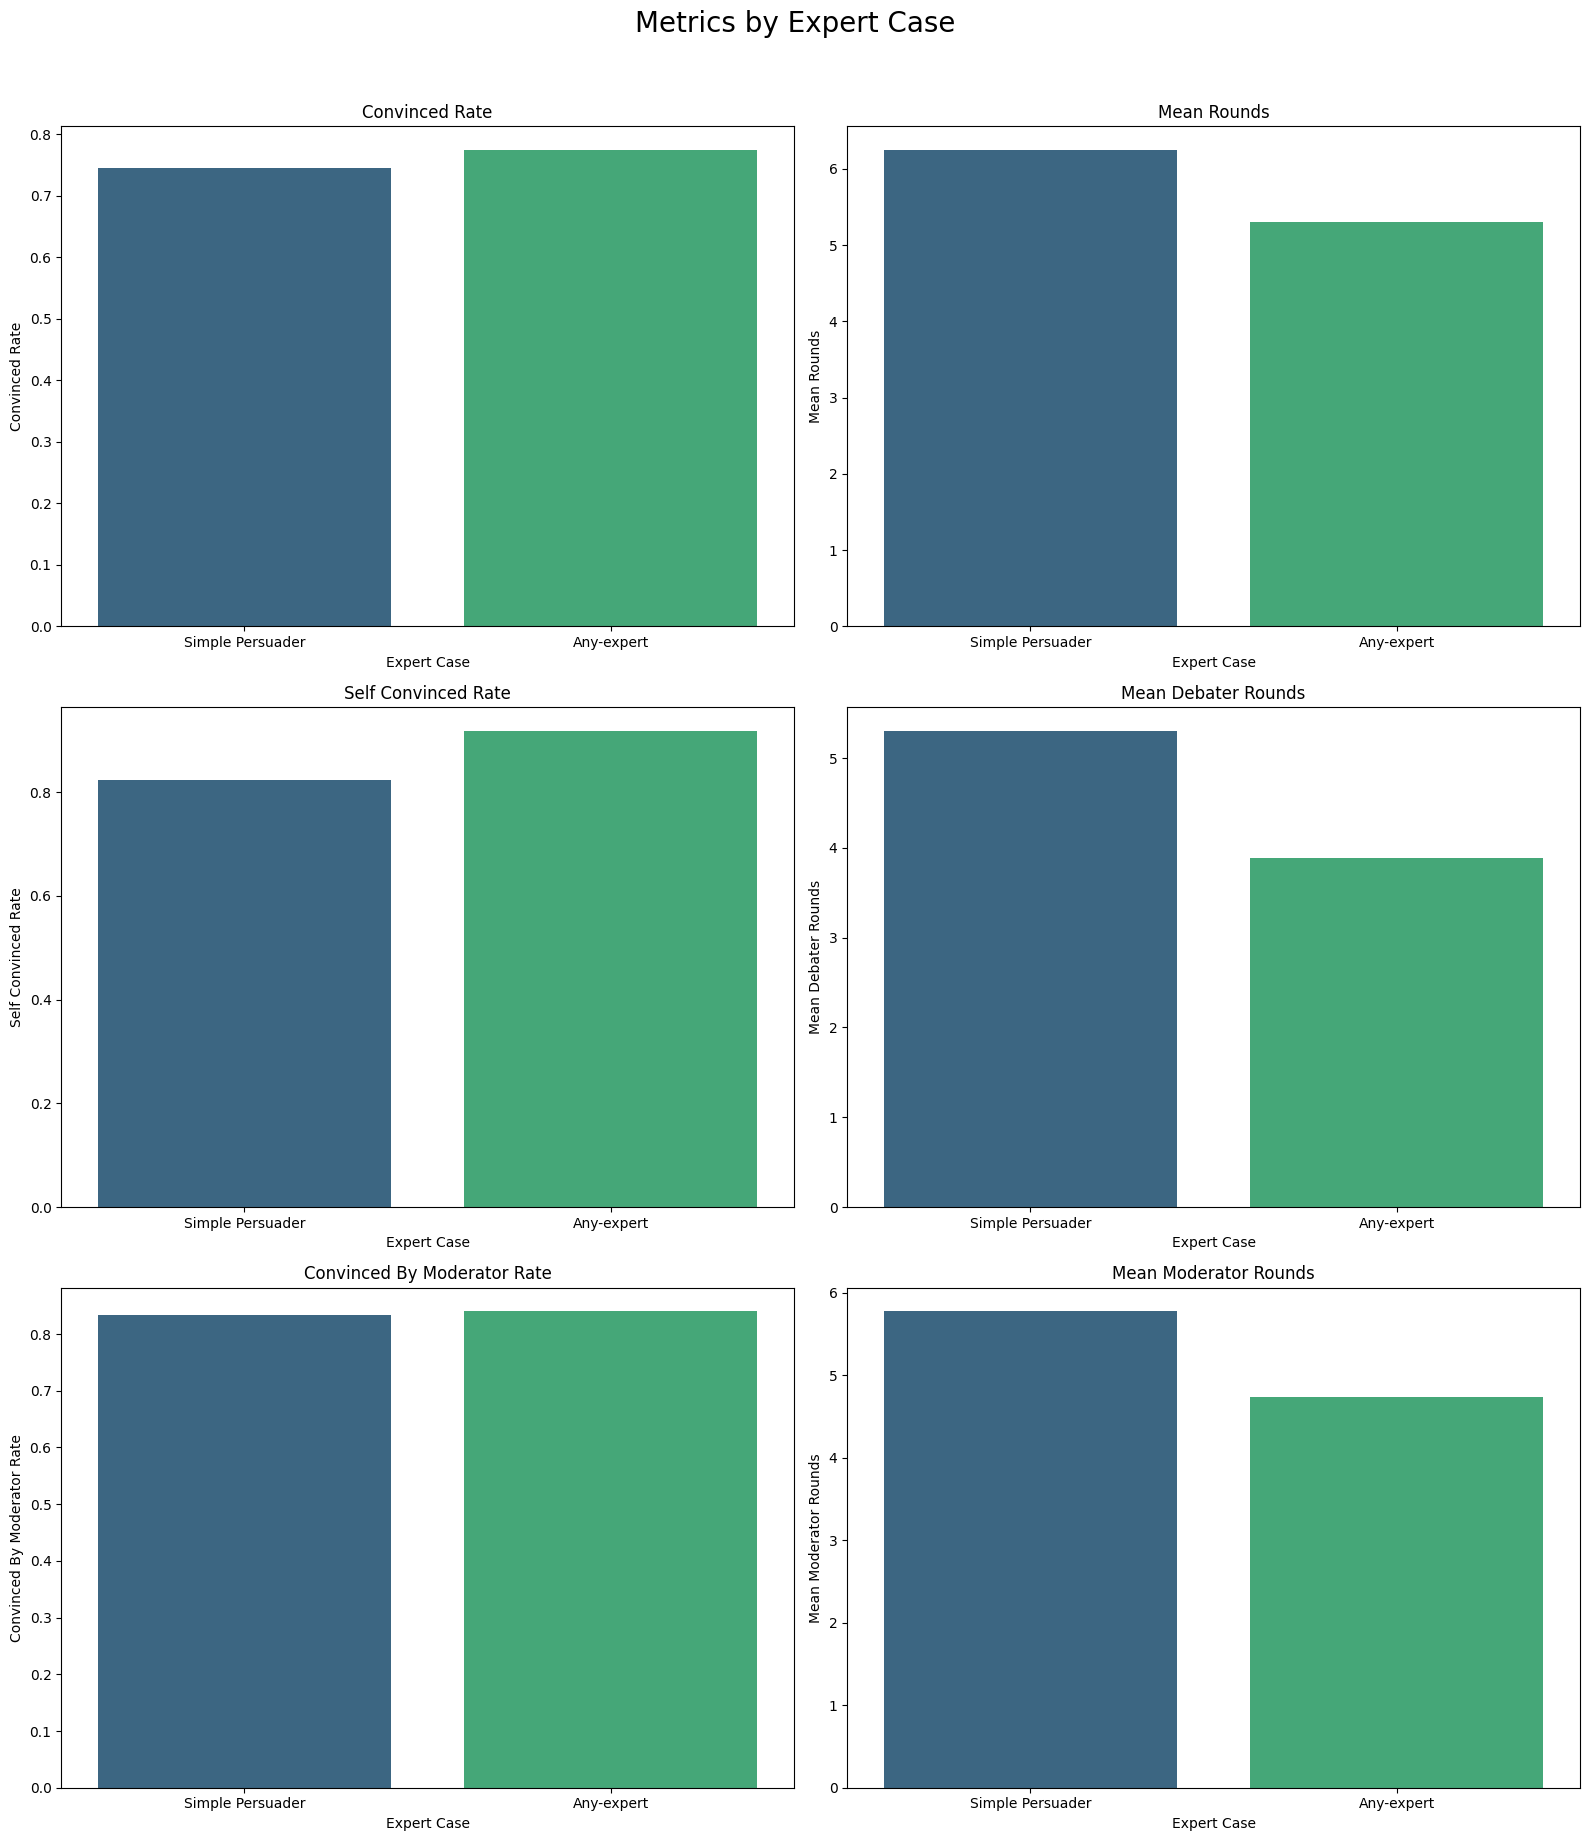

In [625]:
plot_analysis_barplots(expert_analysis_df.loc[[EXPERT_BASELINE,'Any-expert']], save_path='out/Metrics by Expert Case Summary.png',experiment_type= 'expert', metrics = ['convinced_rate', 'mean_rounds', 'self_convinced_rate', 'mean_debater_rounds', 'convinced_by_moderator_rate', 'mean_moderator_rounds'])


✓ Saved: out/Metrics by Expert Case Detaled.png.png


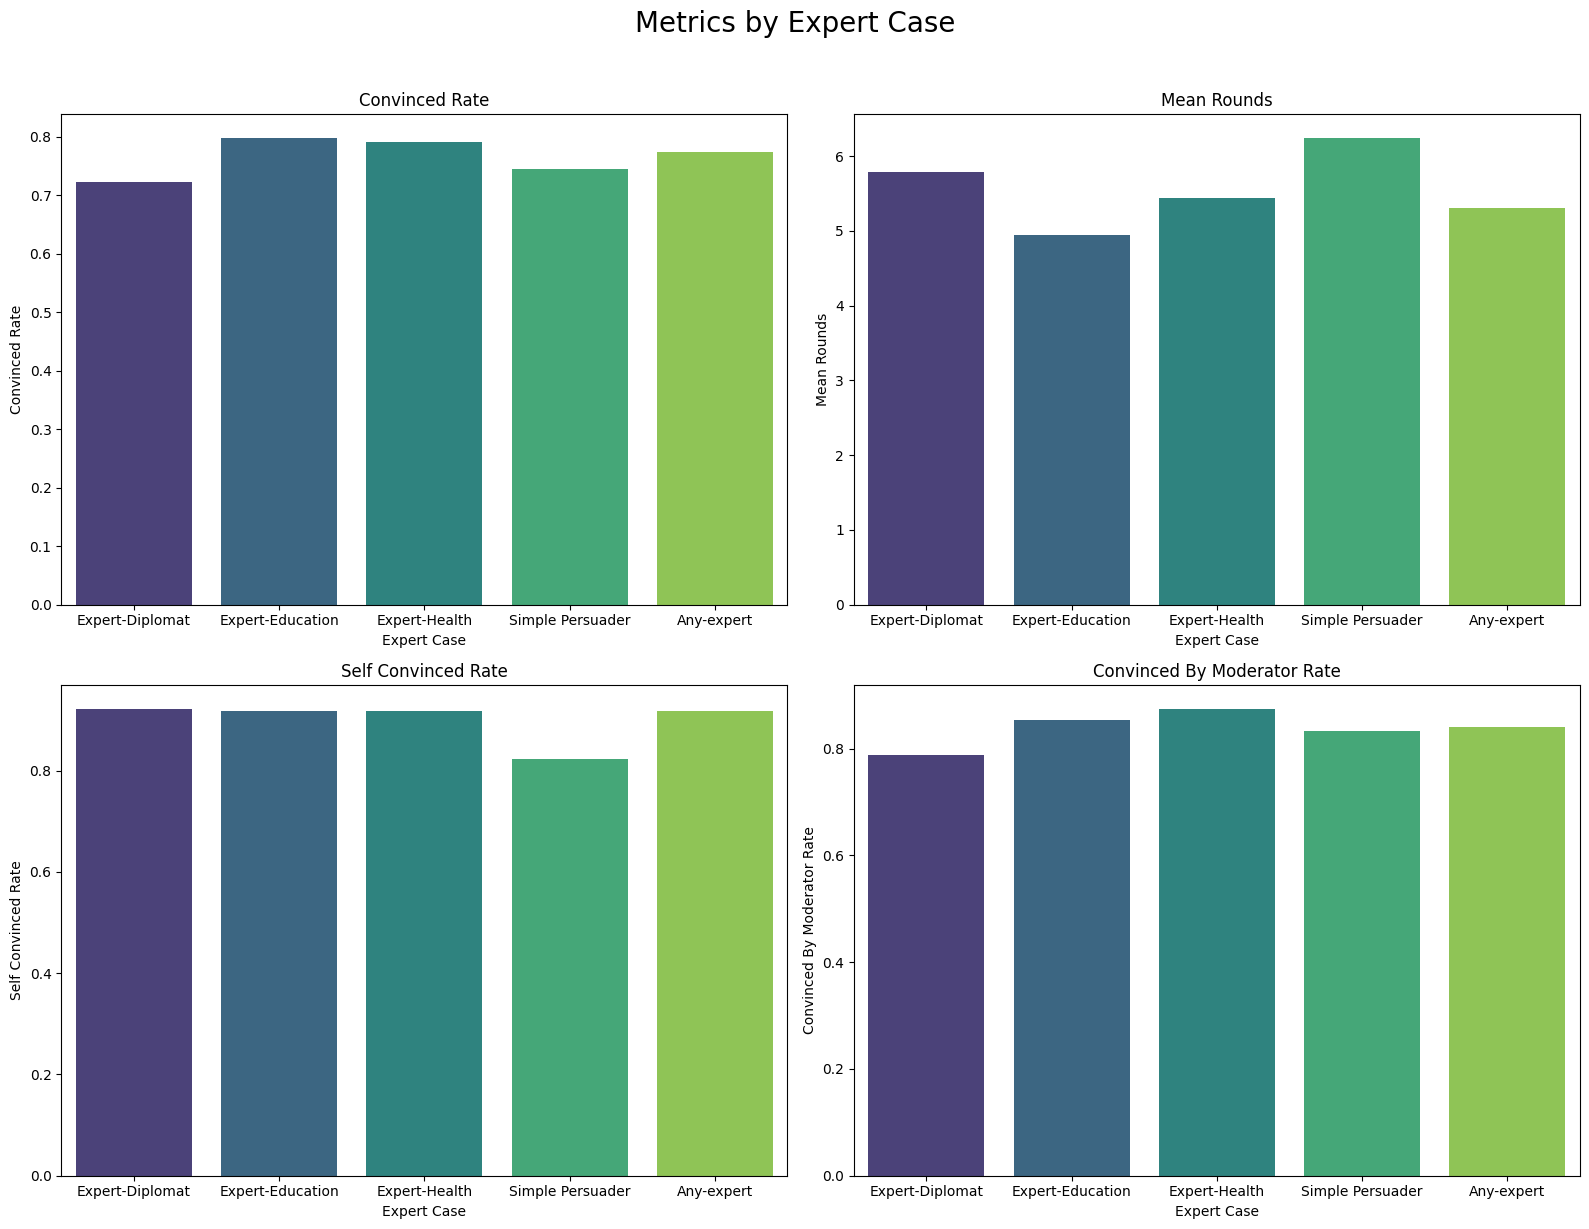

In [626]:
plot_analysis_barplots(expert_analysis_df, save_path='out/Metrics by Expert Case Detaled.png',experiment_type= 'expert', metrics = ['convinced_rate', 'mean_rounds', 'self_convinced_rate', 'convinced_by_moderator_rate',])

In [627]:
# Expert Analysis - Aggregate to Claim Level for Statistical Tests
# Use MEAN aggregation (not majority vote) to avoid upward bias

# Aggregate expert debates to claim-level (N=102 claims)
expert_per_claim_agg = aggregate_expert_to_claim_level(expert_debates_df[expert_debates_df['expert_case'] != EXPERT_BASELINE])

# Get baseline data (already at claim-level, N=200)
baseline_expert = expert_debates_df[expert_debates_df['expert_case'] == EXPERT_BASELINE].copy()

expert_debates_with_baseline = pd.concat([expert_per_claim_agg, baseline_expert])

expert_per_claim_analysis = generate_agg_analysis(expert_debates_with_baseline, experiment= 'expert')
print(f"✓ Expert debates aggregated to claim-level:")
print(f"  Expert cases: N={len(expert_per_claim_agg)} claims (from {len(expert_debates_df[expert_debates_df['expert_case'] != EXPERT_BASELINE])} debates)")
print(f"  Baseline: N={len(expert_per_claim_agg)} claims")
print(f"\n  Expert (Any) conviction rate: {expert_per_claim_agg['result'].mean():.1%}")
print(f"  Baseline conviction rate: {baseline_expert['result'].mean():.1%}")
print(f"\n  Expert (Any) mean rounds: {expert_per_claim_agg['rounds'].mean():.2f}")
print(f"  Baseline mean rounds: {baseline_expert['rounds'].mean():.2f}")
expert_per_claim_analysis

✓ Expert debates aggregated to claim-level:
  Expert cases: N=102 claims (from 306 debates)
  Baseline: N=102 claims

  Expert (Any) conviction rate: 77.5%
  Baseline conviction rate: 74.5%

  Expert (Any) mean rounds: 5.31
  Baseline mean rounds: 6.25


,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds
expert_case,,,,,,,,,
Expert-Diplomat,5.789,5.667,30.000,0.722,5.067,3.944,0.789,0.922,-1.122
Expert-Education,4.938,4.333,48.000,0.799,4.500,3.764,0.854,0.917,-0.736
Expert-Health,5.444,5.000,24.000,0.792,4.792,4.056,0.875,0.917,-0.736
No-gender,6.245,5.500,102.000,0.745,5.775,5.304,0.833,0.824,-0.471
Any-expert,5.307,5.000,102.000,0.775,4.735,3.886,0.840,0.918,-0.850



✓ Saved: out/rounds dist any-expert.png


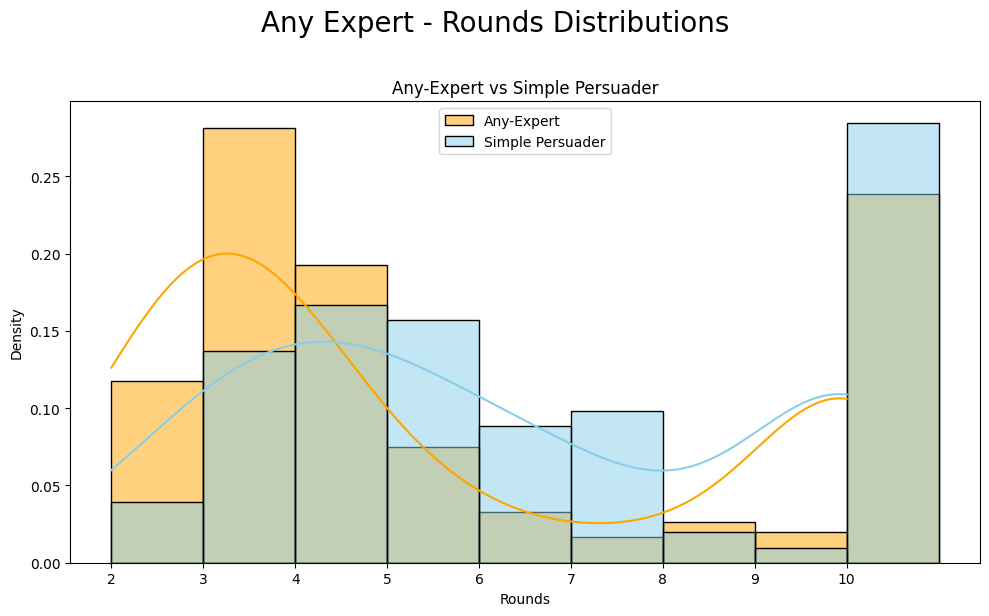

In [628]:
plot_distribution(expert_debates_df, experiment= 'expert',column='rounds',only_any=True, save_path='out/rounds dist any-expert') 


✓ Saved: out/debater rounds dist any-expert.png


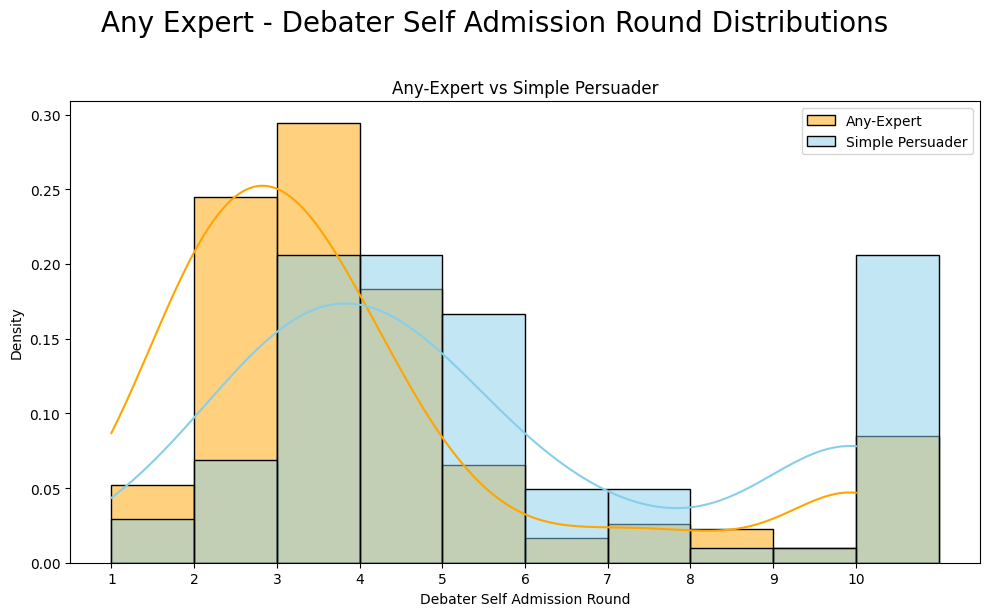

In [629]:
plot_distribution(expert_debates_df, experiment= 'expert',column='debater_self_admission_round',only_any=True, save_path='out/debater rounds dist any-expert') 

In [630]:
# Since Any-expert represents all 102 claims, we can do claim-by-claim comparison with baseline

print("\nComputing PAIRED statistics specifically for Any-expert (102 matched claims):\n")

# Get expert claim-level data (already aggregated from 3 reps -> 1)
expert_claims = expert_per_claim_agg.copy()
baseline_claims = baseline_expert.copy()

# Ensure we have the same claims
assert set(expert_claims['topic_id']) == set(baseline_claims['topic_id']), \
    "Expert and baseline claims don't match!"

# Merge on topic_id to create paired data
paired_data = pd.merge(
    expert_claims[['topic_id', 'result', 'rounds', 'debater_self_admission_round', 
                   'moderator_conviction_round', 'self_convinced', 'convinced_by_moderator']],
    baseline_claims[['topic_id', 'result', 'rounds', 'debater_self_admission_round',
                     'moderator_conviction_round', 'self_convinced', 'convinced_by_moderator']],
    on='topic_id',
    suffixes=('_expert', '_baseline')
)

print(f"Paired data created: {len(paired_data)} matched claims\n")

# ⚠️ IMPORTANT: After mean aggregation, 'result' is CONTINUOUS (0.0, 0.33, 0.67, 1.0), not binary!
# Cannot use McNemar's test (requires binary) → Use Wilcoxon instead

# Wilcoxon signed-rank test for conviction rate (now continuous after aggregation)
wilcox_conviction = wilcoxon(paired_data['result_expert'], paired_data['result_baseline'],
                             alternative='greater', zero_method='wilcox')
p_conviction_paired = wilcox_conviction.pvalue
print(f"Wilcoxon signed-rank test for conviction rate (Any-expert vs. baseline):")
print(f"  Mean conviction rate - Expert: {paired_data['result_expert'].mean():.3f}, Baseline: {paired_data['result_baseline'].mean():.3f}")
print(f"  NOTE: After mean aggregation, conviction rate is continuous (0-1), not binary")
print(f"  p-value (one-sided, expert > baseline): {p_conviction_paired:.4f}")


# Wilcoxon for rounds
wilcox_rounds = wilcoxon(paired_data['rounds_expert'], paired_data['rounds_baseline'], 
                         alternative='less', zero_method='wilcox')
p_rounds_paired = wilcox_rounds.pvalue
print(f"\nWilcoxon signed-rank test for rounds (Any-expert vs. baseline):")
print(f"  Mean rounds - Expert: {paired_data['rounds_expert'].mean():.2f}, Baseline: {paired_data['rounds_baseline'].mean():.2f}")
print(f"  p-value (one-sided, expert < baseline): {p_rounds_paired:.4f}")


# Wilcoxon for debater rounds
wilcox_debater = wilcoxon(paired_data['debater_self_admission_round_expert'], 
                          paired_data['debater_self_admission_round_baseline'],
                          alternative='less', zero_method='wilcox')
p_debater_paired = wilcox_debater.pvalue
print(f"\nWilcoxon signed-rank test for debater rounds (Any-expert vs. baseline):")
print(f"  Mean debater rounds - Expert: {paired_data['debater_self_admission_round_expert'].mean():.2f}, Baseline: {paired_data['debater_self_admission_round_baseline'].mean():.2f}")
print(f"  p-value (one-sided, expert < baseline): {p_debater_paired:.4f}")


# Wilcoxon signed-rank test for self-conviction rate (now continuous after aggregation)
wilcox_self_conviction = wilcoxon(paired_data['self_convinced_expert'], paired_data['self_convinced_baseline'],
                             alternative='greater', zero_method='wilcox')
p_self_conviction_paired = wilcox_self_conviction.pvalue
print(f"\nWilcoxon signed-rank test for self admission in conviction rate (Any-expert vs. baseline):")
print(f"  Mean conviction rate - Expert: {paired_data['self_convinced_expert'].mean():.3f}, Baseline: {paired_data['self_convinced_baseline'].mean():.3f}")
print(f"  NOTE: After mean aggregation, conviction rate is continuous (0-1), not binary")
print(f"  p-value (one-sided, expert > baseline): {p_self_conviction_paired:.4f}")



wilcox_moderator = wilcoxon(paired_data['moderator_conviction_round_expert'], 
                          paired_data['moderator_conviction_round_baseline'],
                          alternative='less', zero_method='wilcox')
p_moderator_paired = wilcox_moderator.pvalue

print(f"\nWilcoxon signed-rank test for moderator rounds (Any-expert vs. baseline):")
print(f"  Mean moderator rounds - Expert: {paired_data['moderator_conviction_round_expert'].mean():.2f}, Baseline: {paired_data['moderator_conviction_round_baseline'].mean():.2f}")
print(f"  p-value (one-sided, expert < baseline): {p_moderator_paired:.4f}")


# Update the Any-expert row with paired p-values
expert_per_claim_analysis.loc['Any-expert', 'p_val_conviction_rate_greater_PAIRED'] = p_conviction_paired
expert_per_claim_analysis.loc['Any-expert', 'p_val_rounds_less_PAIRED'] = p_rounds_paired  
expert_per_claim_analysis.loc['Any-expert', 'p_val_debater_rounds_less_PAIRED'] = p_debater_paired
expert_per_claim_analysis.loc['Any-expert', 'p_val_self_conviction_rate_PAIRED'] = p_self_conviction_paired
expert_per_claim_analysis.loc['Any-expert', 'p_val_moderator_rounds_less_PAIRED'] = p_moderator_paired


print("\n✅ Paired p-values computed for Any-expert and added to analysis DataFrame")


Computing PAIRED statistics specifically for Any-expert (102 matched claims):

Paired data created: 102 matched claims

Wilcoxon signed-rank test for conviction rate (Any-expert vs. baseline):
  Mean conviction rate - Expert: 0.775, Baseline: 0.745
  NOTE: After mean aggregation, conviction rate is continuous (0-1), not binary
  p-value (one-sided, expert > baseline): 0.5372

Wilcoxon signed-rank test for rounds (Any-expert vs. baseline):
  Mean rounds - Expert: 5.31, Baseline: 6.25
  p-value (one-sided, expert < baseline): 0.0012

Wilcoxon signed-rank test for debater rounds (Any-expert vs. baseline):
  Mean debater rounds - Expert: 3.89, Baseline: 5.30
  p-value (one-sided, expert < baseline): 0.0000

Wilcoxon signed-rank test for self admission in conviction rate (Any-expert vs. baseline):
  Mean conviction rate - Expert: 0.918, Baseline: 0.824
  NOTE: After mean aggregation, conviction rate is continuous (0-1), not binary
  p-value (one-sided, expert > baseline): 0.0064

Wilcoxon 

In [631]:
p_value_cols = [col for col in expert_per_claim_analysis.columns if col.startswith('p_val_')]

print(f"Applying Bonferroni correction to {len(p_value_cols)} p-value columns...")
print(f"Number of comparisons per column: 3 (expert types)")

for col in p_value_cols:
    corrected_col = col.replace('p_val_', 'p_val_bonf_')
    expert_per_claim_analysis[corrected_col] = apply_bonferroni_correction(
        expert_per_claim_analysis[col], 
        n_comparisons=3  # 3 expert types
    )

print("\nExpert analysis with Bonferroni-corrected p-values:")
display(expert_per_claim_analysis)



Applying Bonferroni correction to 5 p-value columns...
Number of comparisons per column: 3 (expert types)

Expert analysis with Bonferroni-corrected p-values:


,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds,p_val_conviction_rate_greater_PAIRED,p_val_rounds_less_PAIRED,p_val_debater_rounds_less_PAIRED,p_val_self_conviction_rate_PAIRED,p_val_moderator_rounds_less_PAIRED,p_val_bonf_conviction_rate_greater_PAIRED,p_val_bonf_rounds_less_PAIRED,p_val_bonf_debater_rounds_less_PAIRED,p_val_bonf_self_conviction_rate_PAIRED,p_val_bonf_moderator_rounds_less_PAIRED
expert_case,,,,,,,,,,,,,,,,,,,
Expert-Diplomat,5.789,5.667,30.000,0.722,5.067,3.944,0.789,0.922,-1.122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Expert-Education,4.938,4.333,48.000,0.799,4.500,3.764,0.854,0.917,-0.736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Expert-Health,5.444,5.000,24.000,0.792,4.792,4.056,0.875,0.917,-0.736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No-gender,6.245,5.500,102.000,0.745,5.775,5.304,0.833,0.824,-0.471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Any-expert,5.307,5.000,102.000,0.775,4.735,3.886,0.840,0.918,-0.850,0.537,0.001,0.000,0.006,0.000,1.000,0.004,0.000,0.019,0.000


### Introduction

This section explores whether **domain masculinity** interacts with **gender personas** to affect debate outcomes. 

**Research Question**: Do gender personas show different effects on masculine vs. feminine topics?

**Key Focus**: The **F_M case** (male persuader + female debater) is of particular interest, as we hypothesize it might show the strongest interaction with topic masculinity due to traditional gender dynamics.

**Analyses**:
1. **Categorical**: Group topics into Low (1-4), Neutral (5-6), High (7-10) masculinity and compare across gender cases
2. **Continuous**: Examine correlations between masculine_score (1-10) and debate outcomes
3. **F_M Deep Dive**: Focused analysis on the male-persuader-female-debater configuration

**Note**: This is exploratory analysis. Given the multiple comparisons involved, findings should be interpreted with appropriate caution.

In [632]:
# Expert Analysis - Generate Summary Table
# Includes all metrics with 6 separate p-value columns

# Calculate effect sizes
d_self_rounds = cohens_d(expert_per_claim_agg['debater_self_admission_round'].values, 
                         baseline_expert['debater_self_admission_round'].values)
d_mod_rounds = cohens_d(expert_per_claim_agg['moderator_conviction_round'].values, 
                        baseline_expert['moderator_conviction_round'].values)
d_final_rounds = cohens_d(expert_per_claim_agg['rounds'].values, 
                          baseline_expert['rounds'].values)

# Create summary table
expert_summary = pd.DataFrame({
    'Case': ['Baseline', 'Any-Expert'],
    'N': [len(baseline_expert), len(expert_per_claim_agg)],
    
    # Conviction rates (mean ± SD)
    'Self_Conviction_Rate': [
        f"{baseline_expert['self_convinced'].mean():.3f} ± {baseline_expert['self_convinced'].std():.3f}",
        f"{expert_per_claim_agg['self_convinced'].mean():.3f} ± {expert_per_claim_agg['self_convinced'].std():.3f}"
    ],
    'Moderator_Conviction_Rate': [
        f"{baseline_expert['convinced_by_moderator'].mean():.3f} ± {baseline_expert['convinced_by_moderator'].std():.3f}",
        f"{expert_per_claim_agg['convinced_by_moderator'].mean():.3f} ± {expert_per_claim_agg['convinced_by_moderator'].std():.3f}"
    ],
    'Final_Conviction_Rate': [
        f"{baseline_expert['result'].mean():.3f} ± {baseline_expert['result'].std():.3f}",
        f"{expert_per_claim_agg['result'].mean():.3f} ± {expert_per_claim_agg['result'].std():.3f}"
    ],
    
    # Rounds (mean ± SD)
    'Self_Admission_Rounds': [
        f"{baseline_expert['debater_self_admission_round'].mean():.2f} ± {baseline_expert['debater_self_admission_round'].std():.2f}",
        f"{expert_per_claim_agg['debater_self_admission_round'].mean():.2f} ± {expert_per_claim_agg['debater_self_admission_round'].std():.2f}"
    ],
    'Moderator_Conviction_Rounds': [
        f"{baseline_expert['moderator_conviction_round'].mean():.2f} ± {baseline_expert['moderator_conviction_round'].std():.2f}",
        f"{expert_per_claim_agg['moderator_conviction_round'].mean():.2f} ± {expert_per_claim_agg['moderator_conviction_round'].std():.2f}"
    ],
    'Rounds': [
        f"{baseline_expert['rounds'].mean():.2f} ± {baseline_expert['rounds'].std():.2f}",
        f"{expert_per_claim_agg['rounds'].mean():.2f} ± {expert_per_claim_agg['rounds'].std():.2f}"
    ],
    
    
    # Effect sizes
    'Effect_Size_Self_Rounds': ['—', f"d = {d_self_rounds:.3f}"],
    'Effect_Size_Moderator_Rounds': ['—', f"d = {d_mod_rounds:.3f}"],
    'Effect_Size_Final_Rounds': ['—', f"d = {d_final_rounds:.3f}"]
})

print("\n" + "="*70)
print("EXPERT ANALYSIS - SUMMARY TABLE\n"
      "Includes Bonferroni-corrected p-values for self, moderator, and final rounds.")

# Add Bonferroni-corrected p-values (robustly handle missing columns)
def get_pval_safe(df, idx, col):
    try:
        val = df.loc[idx, col]
        if pd.isnull(val):
            return '—'
        else:
            return "✅" if val < 0.05 else "❌"
    except KeyError:
        return '—'

expert_summary['expert_rounds < baseline_rounds'] = ['—',
    get_pval_safe(expert_per_claim_analysis, 'Any-expert', 'p_val_bonf_debater_rounds_less_PAIRED')]
expert_summary['expert_convinced_rate > baseline_convinced_rate'] = ['—',
    get_pval_safe(expert_per_claim_analysis, 'Any-expert', 'p_val_bonf_conviction_rate_greater_PAIRED')]
expert_summary['expert_self_convinced_rate > baseline_self_convinced_rate'] = ['—',
    get_pval_safe(expert_per_claim_analysis, 'Any-expert', 'p_val_bonf_self_conviction_rate_PAIRED')]


print("="*70)
display(expert_summary)

# Save to CSV
expert_summary.to_csv('out/expert_summary.csv', index=False)
print("\n✓ Saved: out/expert_summary.csv")
print("="*70)


EXPERT ANALYSIS - SUMMARY TABLE
Includes Bonferroni-corrected p-values for self, moderator, and final rounds.


,Case,N,Self_Conviction_Rate,Moderator_Conviction_Rate,Final_Conviction_Rate,Self_Admission_Rounds,Moderator_Conviction_Rounds,Rounds,Effect_Size_Self_Rounds,Effect_Size_Moderator_Rounds,Effect_Size_Final_Rounds,expert_rounds < baseline_rounds,expert_convinced_rate > baseline_convinced_rate,expert_self_convinced_rate > baseline_self_convinced_rate
0,Baseline,102,0.824 ± 0.383,0.833 ± 0.375,0.745 ± 0.438,5.30 ± 2.78,5.77 ± 2.54,6.25 ± 2.74,—,—,—,—,—,—
1,Any-Expert,102,0.918 ± 0.144,0.840 ± 0.243,0.775 ± 0.282,3.89 ± 1.30,4.74 ± 1.92,5.31 ± 1.90,d = -0.654,d = -0.462,d = -0.398,✅,❌,✅



✓ Saved: out/expert_summary.csv



### Expert Analysis - Summary

#### Key Findings

**Overall Result**: No significant differences observed in simple binary conviction outcomes between expert persuaders and baseline (No-gender) condition.

**However, deeper analysis reveals important effects:**

#### 1. **Insufficient Rounds Under Dual Termination Protocol**

All the rounds metrics (rounds, "rounds by moderator" and "rounds by debater") show **significant differences** between expert and baseline conditions, suggesting that:

- Expert persuaders *are* having an effect on the debate dynamics
- The dual termination protocol (moderator + self-admission) terminates debates **before full conviction is achieved**
- The current maximum rounds limit may be cutting off debates prematurely
- **Implication**: With more rounds, we might observe significant differences in final conviction outcomes

#### 2. **Authority Bias vs. Progressive Moderation**

Analysis of **self-admission** data reveals a fascinating dynamic:

- **Debaters show significantly higher self-admission rates** when facing expert persuaders
- This suggests the simpler debater model (GPT-3.5-turbo) exhibits **natural authority bias** - a tendency to defer to proclaimed expertise
- **However**, this self-admission does not translate to conviction hihg rate
- **Interpretation**: The more sophisticated moderator model (GPT-4o) may be actively **countering the authority bias** of the debater, requiring more rigorous evidence for conviction determination
- This creates a tension between the debater's willingness to concede and the moderator's higher evidentiary standards


---

## Part 2: GENDER PERSONA ANALYSIS - General Effects
### Analyzes gender persona effects on debate outcomes

In [633]:
gender_analysis_df = generate_agg_analysis(gender_debates_df, 'gender')

print("Gender Analysis DataFrame (before statistical tests):")
display(gender_analysis_df)

Gender Analysis DataFrame (before statistical tests):


,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds
gender_case,,,,,,,,,
F_F,6.295,5.000,200.000,0.670,5.295,5.475,0.840,0.770,0.180
F_M,6.460,6.000,198.000,0.672,5.530,5.429,0.828,0.788,-0.101
M_F,6.196,5.000,199.000,0.673,5.181,5.161,0.854,0.799,-0.020
M_M,6.692,6.000,198.000,0.641,6.045,5.535,0.778,0.803,-0.510
Persona-baseline,6.782,7.000,197.000,0.599,5.736,5.726,0.797,0.766,-0.010
Any-gender,6.410,6.000,795.000,0.664,5.512,5.400,0.825,0.790,-0.112



✓ Saved: out/metrics barplot summary.png


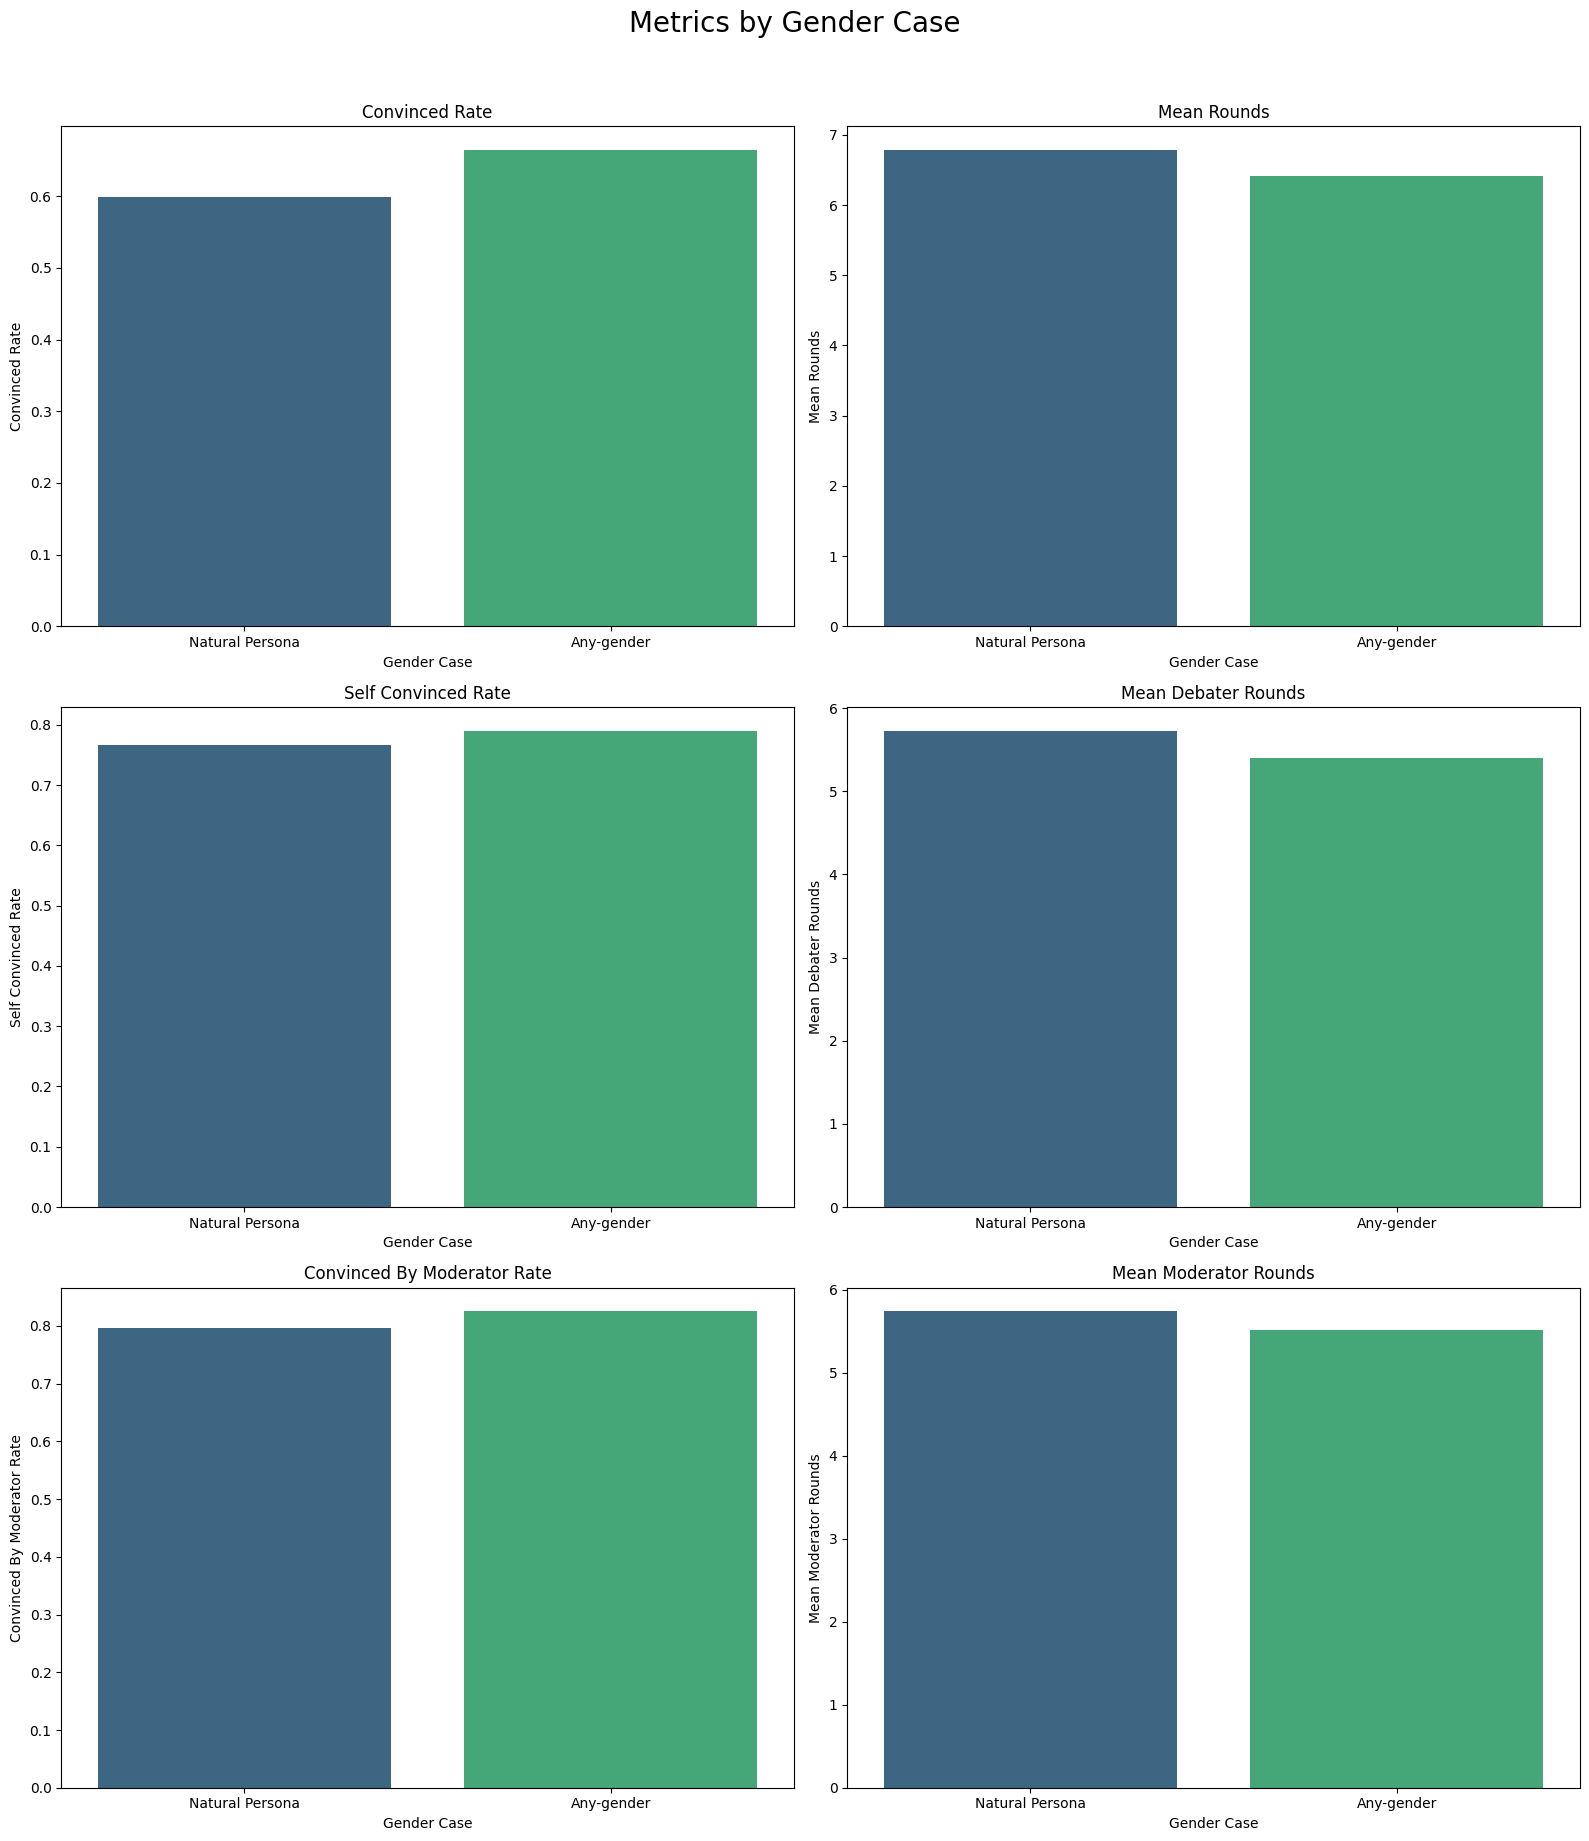

In [634]:
plot_analysis_barplots(gender_analysis_df.loc[[GENDER_BASELINE,'Any-gender']], save_path='out/metrics barplot summary', experiment_type= 'gender', metrics = ['convinced_rate', 'mean_rounds', 'self_convinced_rate', 'mean_debater_rounds','convinced_by_moderator_rate', 'mean_moderator_rounds'])


✓ Saved: out/gender rounds dist.png


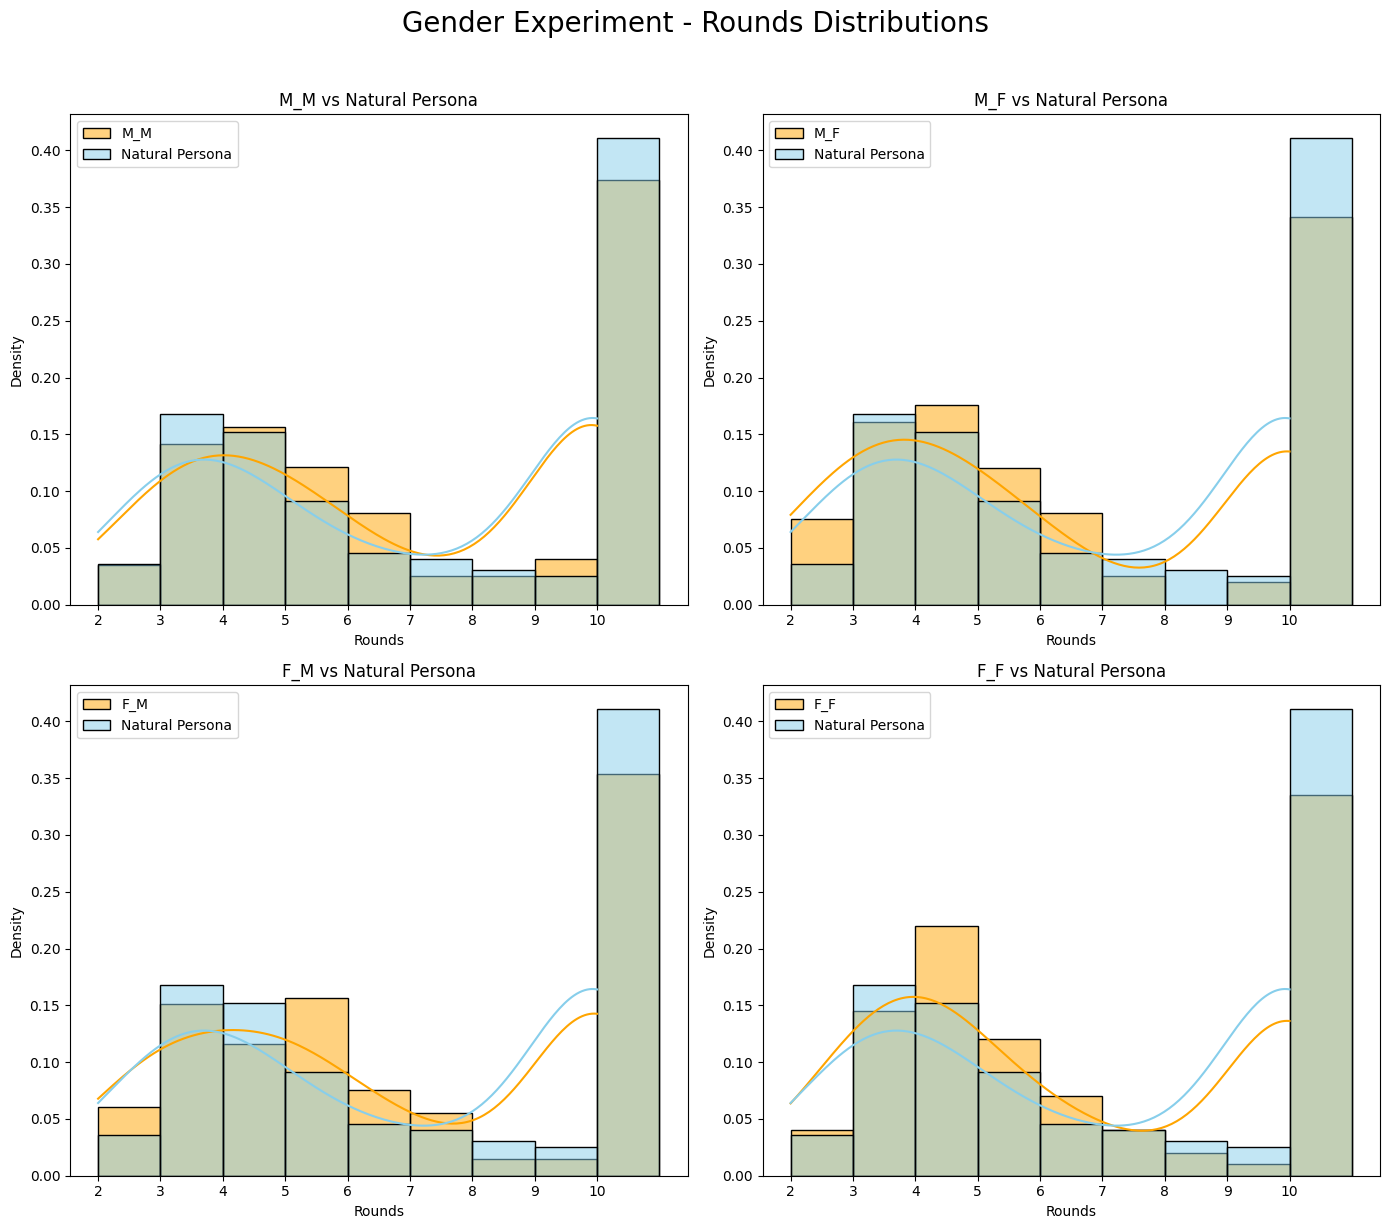

In [635]:
plot_distribution(gender_debates_df, save_path='out/gender rounds dist', experiment= 'gender',column='rounds',density=True)

---

### 🔍 Exploratory Analysis: Female vs Male Debaters

**Research Question**: Is there any difference in debate outcomes between female and male debaters, independent of the persuader's gender?

**Methodology**:
- **Female Debaters**: Aggregate results from F_F (female persuader → female debater) + M_F (male persuader → female debater)
- **Male Debaters**: Aggregate results from M_M (male persuader → male debater) + F_M (female persuader → male debater)
- **Comparison**: Paired **two-sided** statistical tests at the claim level
  - **McNemar's test (two-sided)** for binary conviction outcomes (paired categorical data)
  - **Wilcoxon signed-rank test (two-sided)** for rounds to conviction (paired continuous data)

**Rationale**: 
By aggregating across persuader genders, we isolate the effect of debater gender. This controls for persuader effects and examines whether the gender persona of the debater influences debate dynamics, without assuming a directional hypothesis.

**Expected Insights**:
- Is there a difference in conviction rates between female and male debaters?
- Is there a difference in rounds to conviction?
- Could reveal gender-based differences in argumentative engagement or critical evaluation (exploratory)

In [636]:
# Step 1: Create debater gender aggregates
# Female debaters: F_F (female persuader, female debater) + M_F (male persuader, female debater)
# Male debaters: M_M + F_M

def aggregate_by_debater_gender(df):
    """
    Aggregate gender cases by debater gender.
    Returns wide-format DataFrame with one row per claim.
    """
    # Create debater gender labels
    df_copy = df.copy()
    df_copy['debater_gender'] = df_copy['gender_case'].map({
        'F_F': 'Female_debater',
        'M_F': 'Female_debater',
        'M_M': 'Male_debater',
        'F_M': 'Male_debater',
        'Persona-baseline': 'Baseline',
        'No-gender': 'Legacy_baseline'
    })
    
    # For now, let's focus on getting data for F_F, M_F, M_M, F_M, Persona-baseline
    # Keep only these cases
    keep_cases = ['F_F', 'M_F', 'M_M', 'F_M', 'Persona-baseline']
    df_filt = df_copy[df_copy['gender_case'].isin(keep_cases)].copy()
    
    return df_filt

gender_filtered = aggregate_by_debater_gender(gender_debates_df)
print(f"✓ Filtered gender data: {len(gender_filtered)} debates")
print(f"  Debates per case: {gender_filtered.groupby('gender_case').size().to_dict()}")

✓ Filtered gender data: 992 debates
  Debates per case: {'F_F': 200, 'F_M': 198, 'M_F': 199, 'M_M': 198, 'Persona-baseline': 197}


In [637]:
# Step 2: Aggregate Female vs. Male debaters at claim level
# For each claim, combine results from F_F & M_F (female debaters) vs. M_M & F_M (male debaters)

# Create pivot table: rows=claims, columns=gender_case
conviction_pivot = gender_filtered.pivot_table(
    index='topic_id', 
    columns='gender_case', 
    values='result', 
    aggfunc='first'  # Should only be one value per claim-case combo
)

rounds_pivot = gender_filtered.pivot_table(
    index='topic_id', 
    columns='gender_case', 
    values='rounds', 
    aggfunc='first'
)

# Aggregate by debater gender (take max for female debater cases, max for male debater cases)
# Female debater convinced if EITHER F_F OR M_F convinced
# Male debater convinced if EITHER M_M OR F_M convinced
conviction_pivot['Female_debater'] = conviction_pivot[['F_F', 'M_F']].max(axis=1)
conviction_pivot['Male_debater'] = conviction_pivot[['M_M', 'F_M']].max(axis=1)

# For rounds, take mean across persuader genders for same debater gender
rounds_pivot['Female_debater'] = rounds_pivot[['F_F', 'M_F']].mean(axis=1)
rounds_pivot['Male_debater'] = rounds_pivot[['M_M', 'F_M']].mean(axis=1)

print("✓ Pivoted data by claim:")
print(f"  Claims with complete data: {len(conviction_pivot)}")
print(f"  Female debater conviction rate: {conviction_pivot['Female_debater'].mean():.1%}")
print(f"  Male debater conviction rate: {conviction_pivot['Male_debater'].mean():.1%}")
print(f"  Female debater mean rounds: {rounds_pivot['Female_debater'].mean():.2f}")
print(f"  Male debater mean rounds: {rounds_pivot['Male_debater'].mean():.2f}")

✓ Pivoted data by claim:
  Claims with complete data: 200
  Female debater conviction rate: 87.0%
  Male debater conviction rate: 82.4%
  Female debater mean rounds: 6.25
  Male debater mean rounds: 6.58


In [638]:
# Step 3: McNemar's test for paired binary data (conviction)

# Create contingency table for McNemar test
# Format: [[both_yes, female_only], [male_only, both_no]]
female_conv = conviction_pivot['Female_debater']
male_conv = conviction_pivot['Male_debater']

both_convinced = ((female_conv == 1) & (male_conv == 1)).sum()
female_only = ((female_conv == 1) & (male_conv == 0)).sum()
male_only = ((female_conv == 0) & (male_conv == 1)).sum()
neither = ((female_conv == 0) & (male_conv == 0)).sum()

contingency_mcnemar = [[both_convinced, female_only],
                       [male_only, neither]]

# McNemar test (use exact if discordant pairs < 25, otherwise continuity correction)
n_discordant = female_only + male_only
use_exact = n_discordant < 25

mcnemar_result = mcnemar(contingency_mcnemar, exact=use_exact, correction=not use_exact)

print("="*60)
print("GENDER ANALYSIS RESULTS (Paired Design)")
print("="*60)
print(f"\n1. Conviction Rate (McNemar's test, paired):")
print(f"   Both convinced:     {both_convinced}")
print(f"   Female only:        {female_only}")
print(f"   Male only:          {male_only}")
print(f"   Neither:            {neither}")
print(f"   Discordant pairs:   {n_discordant}")
print(f"   Female debater: {female_conv.mean():.1%}")
print(f"   Male debater:   {male_conv.mean():.1%}")
print(f"   McNemar statistic = {mcnemar_result.statistic:.2f}, p = {mcnemar_result.pvalue:.4f} {'*' if mcnemar_result.pvalue < 0.05 else 'ns'}")
print(f"   (Test type: {'Exact' if use_exact else 'Chi-square with continuity correction'})")

GENDER ANALYSIS RESULTS (Paired Design)

1. Conviction Rate (McNemar's test, paired):
   Both convinced:     150
   Female only:        23
   Male only:          14
   Neither:            12
   Discordant pairs:   37
   Female debater: 87.0%
   Male debater:   82.4%
   McNemar statistic = 1.73, p = 0.1884 ns
   (Test type: Chi-square with continuity correction)


In [639]:
# Step 4: Wilcoxon signed-rank test for paired continuous data (rounds)
female_rounds = rounds_pivot['Female_debater']
male_rounds = rounds_pivot['Male_debater']

# Remove pairs with NaN
valid_pairs = ~(female_rounds.isna() | male_rounds.isna())
female_rounds_clean = female_rounds[valid_pairs]
male_rounds_clean = male_rounds[valid_pairs]

wilcoxon_result = wilcoxon(female_rounds_clean, male_rounds_clean, alternative='two-sided')

# Calculate effect size (r = Z / sqrt(N))
n_pairs = len(female_rounds_clean)
z_score = wilcoxon_result.statistic / np.sqrt(n_pairs)  # Approximate
effect_size_r = z_score  # Will recalculate properly if needed

# Calculate mean difference
mean_diff = (female_rounds_clean - male_rounds_clean).mean()

print(f"\n2. Rounds to Conviction (Wilcoxon signed-rank test, paired):")
print(f"   Female debater: M = {female_rounds_clean.mean():.2f} (SD = {female_rounds_clean.std():.2f})")
print(f"   Male debater:   M = {male_rounds_clean.mean():.2f} (SD = {male_rounds_clean.std():.2f})")
print(f"   Mean difference: {mean_diff:+.2f} rounds")
print(f"   Wilcoxon W = {wilcoxon_result.statistic:.1f}, p = {wilcoxon_result.pvalue:.4f} {'*' if wilcoxon_result.pvalue < 0.05 else 'ns'}")
print(f"   N pairs = {n_pairs}")
print("="*60)


2. Rounds to Conviction (Wilcoxon signed-rank test, paired):
   Female debater: M = 6.27 (SD = 2.25)
   Male debater:   M = 6.58 (SD = 2.40)
   Mean difference: -0.31 rounds
   Wilcoxon W = 5954.5, p = 0.0899 ns
   N pairs = 199


#### Gender Analysis - Summary

##### General
1. **Any Gender vs No Gender Analysis:** - Total gender phenomena does not shows strong effects on persuations or debate lenght.
  - This is an expected and good result, shows that if spesific gender case has effect, it's because of the special relations between the genders in the case examined not from a general gender addition.
2. **No Gender Case Showed High Effect On The Metrics** - suggest that modern LLMs are some what immune to the gender bias, at least in the general aspect   

##### 📊 Interpretation of Female vs Male Debater Analysis
1. **Conviction Rates (McNemar's Test)**:
   - **not significant**: Both genders are equally persuadable across claims
   - Discordant pairs indicate claim-specific gender effects

2. **Rounds to Conviction (Wilcoxon Test)**:
   - **not significant**: Both genders are equally persuadable across claims
   - Discordant pairs indicate claim-specific gender effects

##### Conclusions
**Null Results Interpretation** 
  - Debater Gender persona may not meaningfully affect persuadability
  - Effects may be claim-specific and cancel out in aggregate -> *we move to investigate domain masculinity effects*

**Note**: This is an exploratory analysis. Any significant findings should be interpreted cautiously and validated with additional experiments or qualitative examination of debate transcripts.

## Part 3: GENDER PERSONA X DOMAIN CROSS ANALYSIS - Domain Masculinity Scores Effects

### Introduction

This section explores whether **domain masculinity** (topic gender-stereotypicality) interacts with **gender personas** to affect debate outcomes. 

**Research Question**: Do gender personas show different persuasion effects on masculine vs. feminine topics?

**Hypothesis**: The **M_F case** (male persuader + female debater) might show the strongest interaction with topic masculinity, as traditional gender role expectations could create stronger authority effects on masculine topics.

**Analysis Approach**:
1. **Categorical Analysis**: Group topics into Low (1-4), Neutral (5-6), High (7-10) masculinity and compare debate outcomes
2. **Continuous Analysis**: Examine correlations between masculinity scores (1-10) and outcomes for each gender case
3. **F_M Deep Dive**: Focused analysis on the male-persuader-female-debater configuration
4. **Summary Statistics**: Comprehensive tables of correlations and categorical breakdowns

**Note**: This is **exploratory analysis**. With multiple gender cases and metrics, many statistical tests are performed. Findings should be interpreted cautiously and treated as hypothesis-generating rather than confirmatory.

### 3.1 Data Preparation

First, let's examine the distribution of masculinity scores and create categorical groupings.

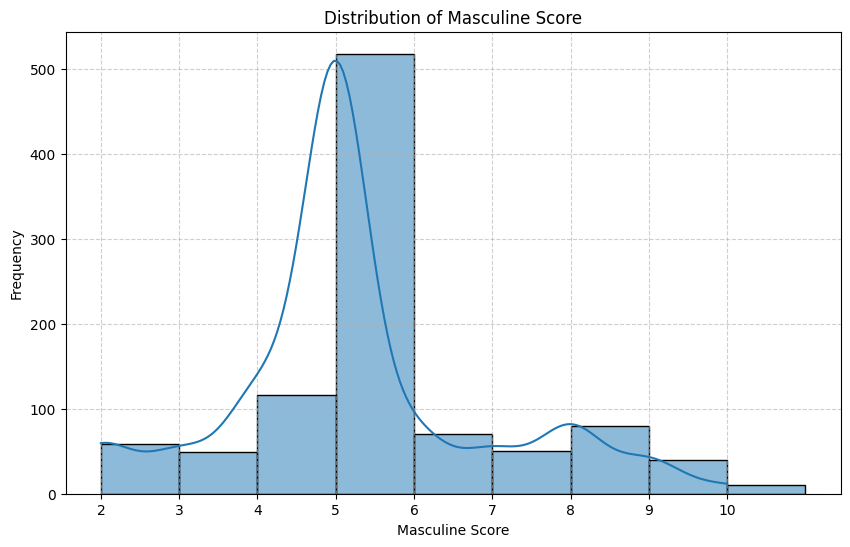

In [661]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(masculinity_scores_debates_df['masculine_score'], kde=True, bins=range(masculinity_scores_debates_df['masculine_score'].min(), masculinity_scores_debates_df['masculine_score'].max() + 2))
plt.title('Distribution of Masculine Score')
plt.xlabel('Masculine Score')
plt.ylabel('Frequency')
plt.xticks(range(masculinity_scores_debates_df['masculine_score'].min(), masculinity_scores_debates_df['masculine_score'].max() + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [662]:
domain_analysis_df = biuld_domain_analysis_df(masculinity_scores_debates_df)
print("Aggregated data by gender_case and masculine_score.")
domain_analysis_df.head()

Aggregated data by gender_case and masculine_score.


,gender_case,masculine_score,count,convinced_rate,mean_rounds,mean_debater_rounds,self_convinced_rate,mean_moderator_rounds,moderator_conviced_rate
0,F_F,2,12,0.750,5.500,4.583,0.833,5.000,0.917
1,F_F,3,10,0.600,6.600,5.300,0.700,4.900,0.900
2,F_F,4,24,0.667,6.125,5.375,0.833,5.000,0.833
3,F_F,5,104,0.663,6.394,5.779,0.760,5.385,0.827
4,F_F,6,14,0.714,5.929,4.214,0.857,5.286,0.857


### 3.2 Categorical Analysis

In [663]:
bins = [0, 4, 5, 10]
labels = ['Feminine', 'Natural', 'Masculine']

masculinity_scores_debates_df['masculinity_category'] = pd.cut(masculinity_scores_debates_df['masculine_score'], bins=bins, labels=labels, right=True)

print("Value counts for 'masculinity_category':")
print(masculinity_scores_debates_df['masculinity_category'].value_counts())

category_analysis_df = masculinity_scores_debates_df.groupby('masculinity_category', observed=False).agg(
    total_debates=('topic_id', 'size'),
    sample_domains=('domain', lambda x: x.dropna().unique().tolist()[:3])
).reset_index()

print("Aggregated summary by masculinity category:")
category_analysis_df.head()


Value counts for 'masculinity_category':
masculinity_category
Natural      518
Masculine    250
Feminine     224
Name: count, dtype: int64
Aggregated summary by masculinity category:


,masculinity_category,total_debates,sample_domains
0,Feminine,224,"[Higher Education, Youth and Adulthood Transit..."
1,Natural,518,"[Energy Policy, Food and Nutrition, Legal System]"
2,Masculine,250,"[Law School Admissions, British Monarchy, Empl..."



✓ Saved: out/Distribution of Debates by Masculinity Category.png


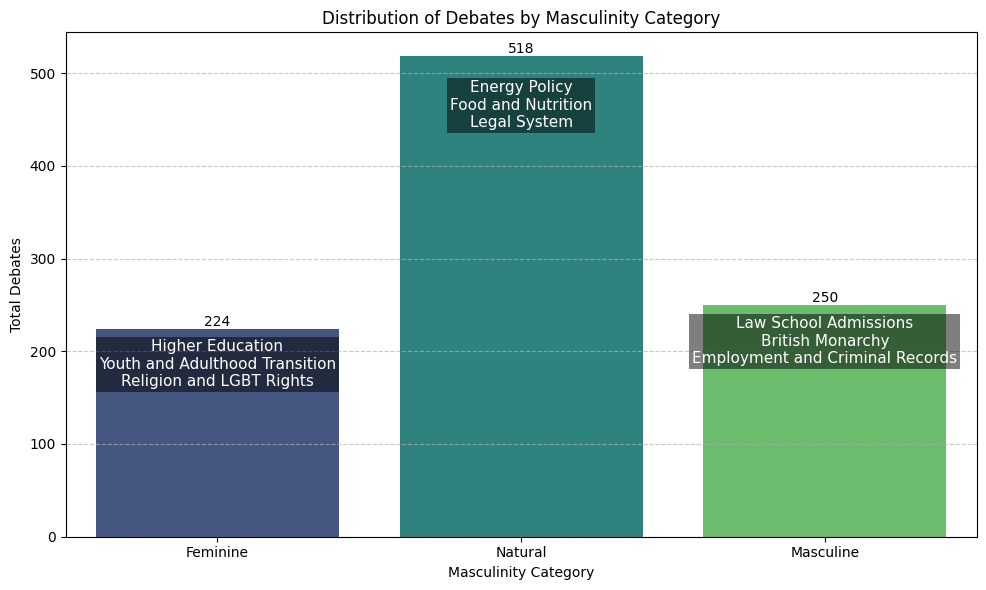

In [664]:

plt.figure(figsize=(10, 6))
sns.barplot(x='masculinity_category', y='total_debates', data=category_analysis_df, palette='viridis', hue='masculinity_category', legend=False)

plt.title('Distribution of Debates by Masculinity Category')
plt.xlabel('Masculinity Category')
plt.ylabel('Total Debates')

# Add annotations for total debates and sample domains
for index, row in category_analysis_df.iterrows():
    plt.text(index, row['total_debates'], f"{row['total_debates']}", color='black', ha="center", va='bottom')
    domains_text = '\n'.join(row['sample_domains'])
    plt.text(index, row['total_debates'] * 0.95, domains_text, color='white', ha="center", va='top', fontsize=11, bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(fname=f'out/Distribution of Debates by Masculinity Category',dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: out/Distribution of Debates by Masculinity Category.png")
plt.show()

In [665]:
category_analysis_df = biuld_domain_analysis_df(masculinity_scores_debates_df, group_by = 'masculinity_category')
print("Aggregated data by gender_case and masculinity_category:")
category_analysis_df.head()

Aggregated data by gender_case and masculinity_category:


,gender_case,masculinity_category,count,convinced_rate,mean_rounds,mean_debater_rounds,self_convinced_rate,mean_moderator_rounds,moderator_conviced_rate
0,F_F,Feminine,46,0.674,6.065,5.152,0.804,4.978,0.870
1,F_F,Natural,104,0.663,6.394,5.779,0.760,5.385,0.827
2,F_F,Masculine,50,0.680,6.300,5.140,0.760,5.400,0.840
3,F_M,Feminine,45,0.644,6.867,5.622,0.756,5.911,0.800
4,F_M,Natural,103,0.641,6.534,5.398,0.786,5.456,0.816


✓ Saved: out/masculinity X metrics (F_F).png


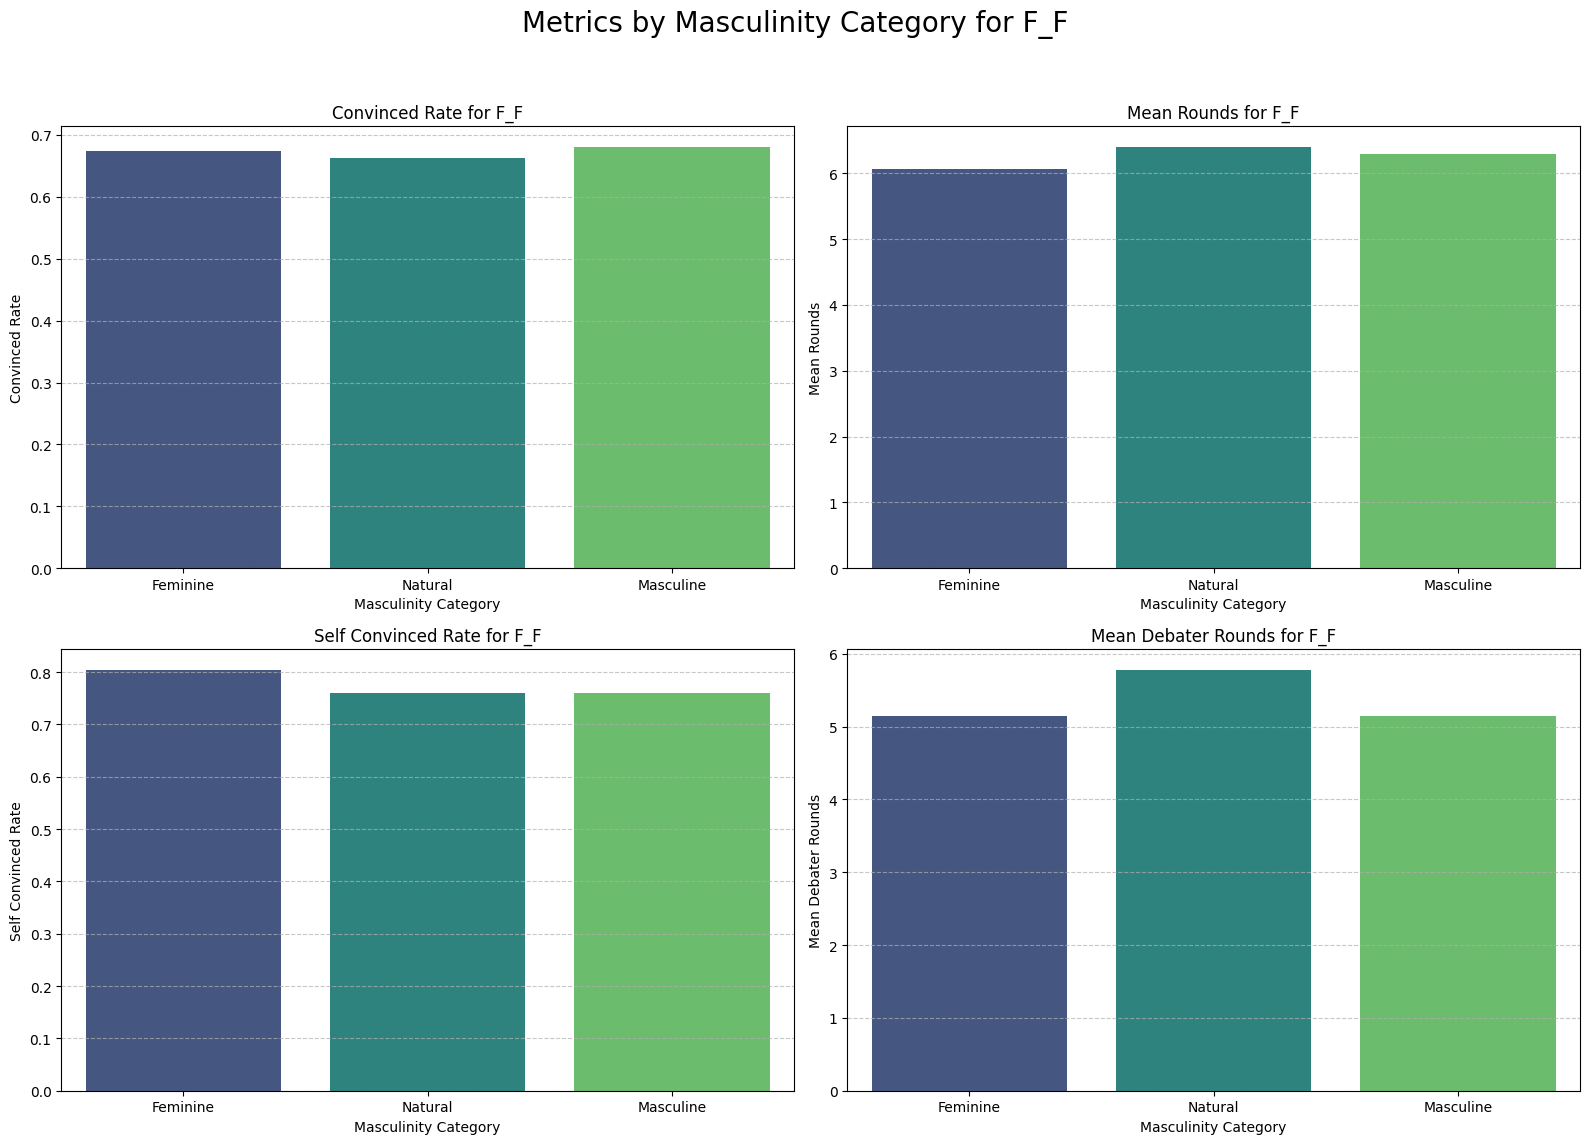

✓ Saved: out/masculinity X metrics (F_M).png


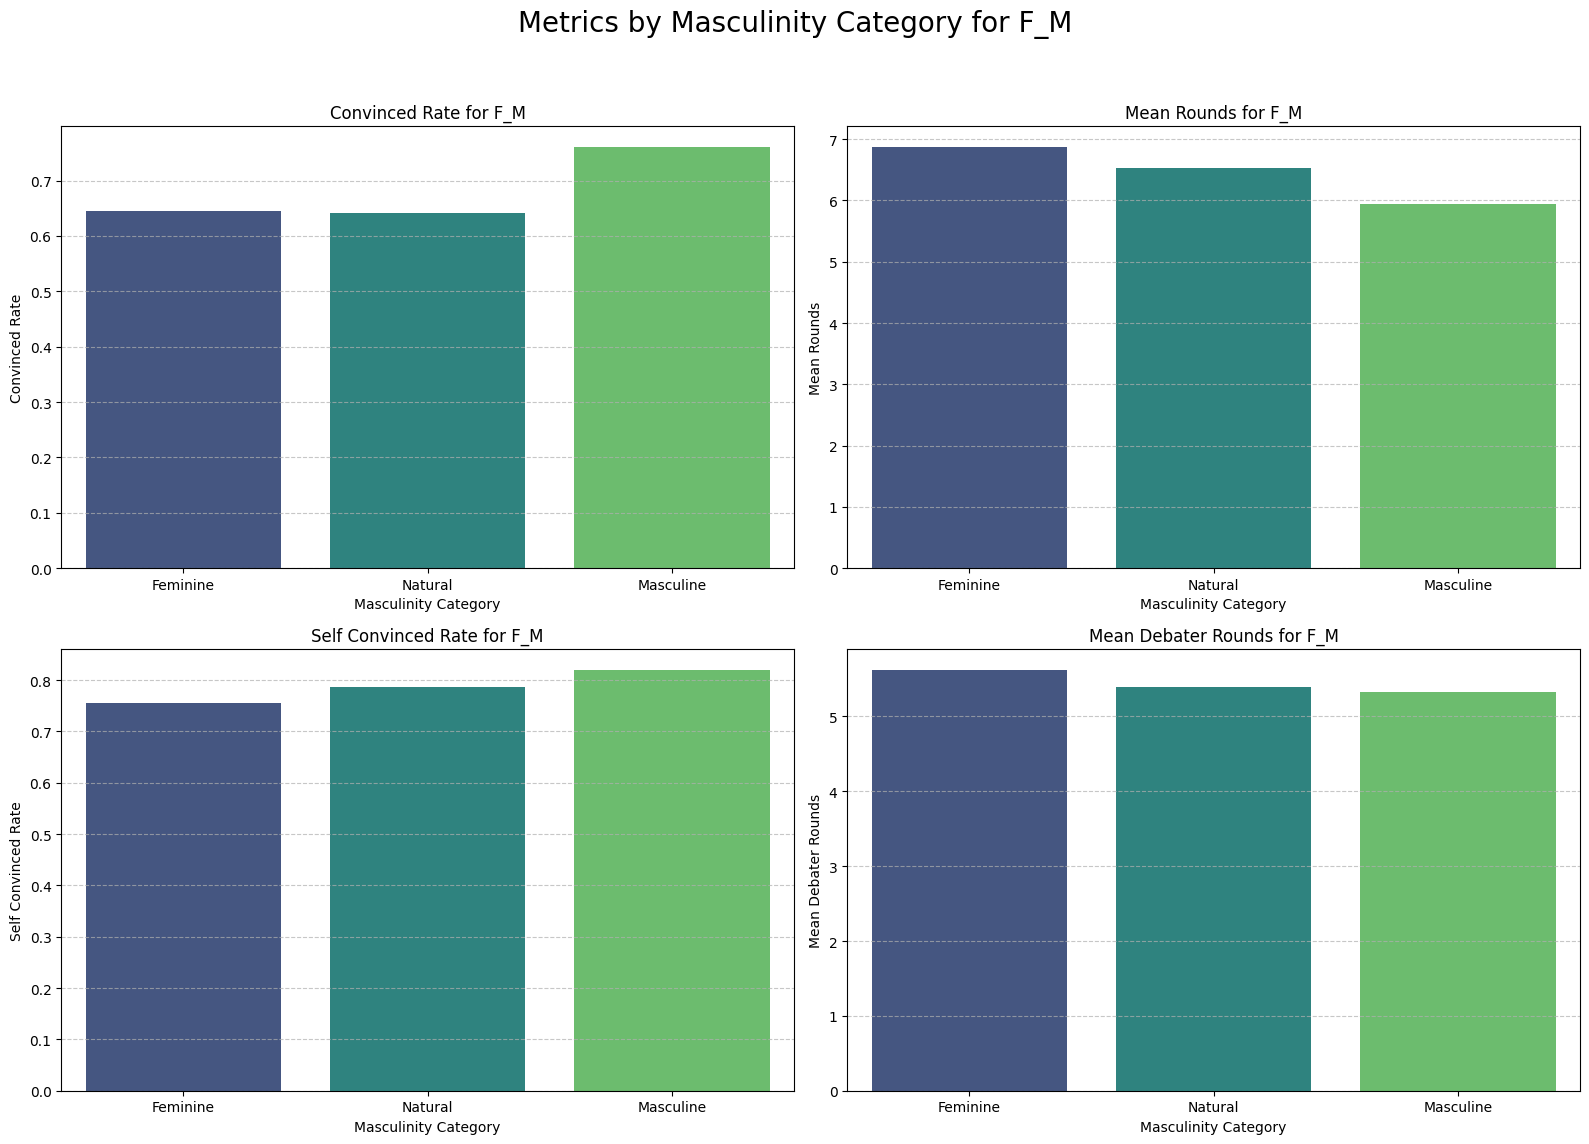

✓ Saved: out/masculinity X metrics (M_F).png


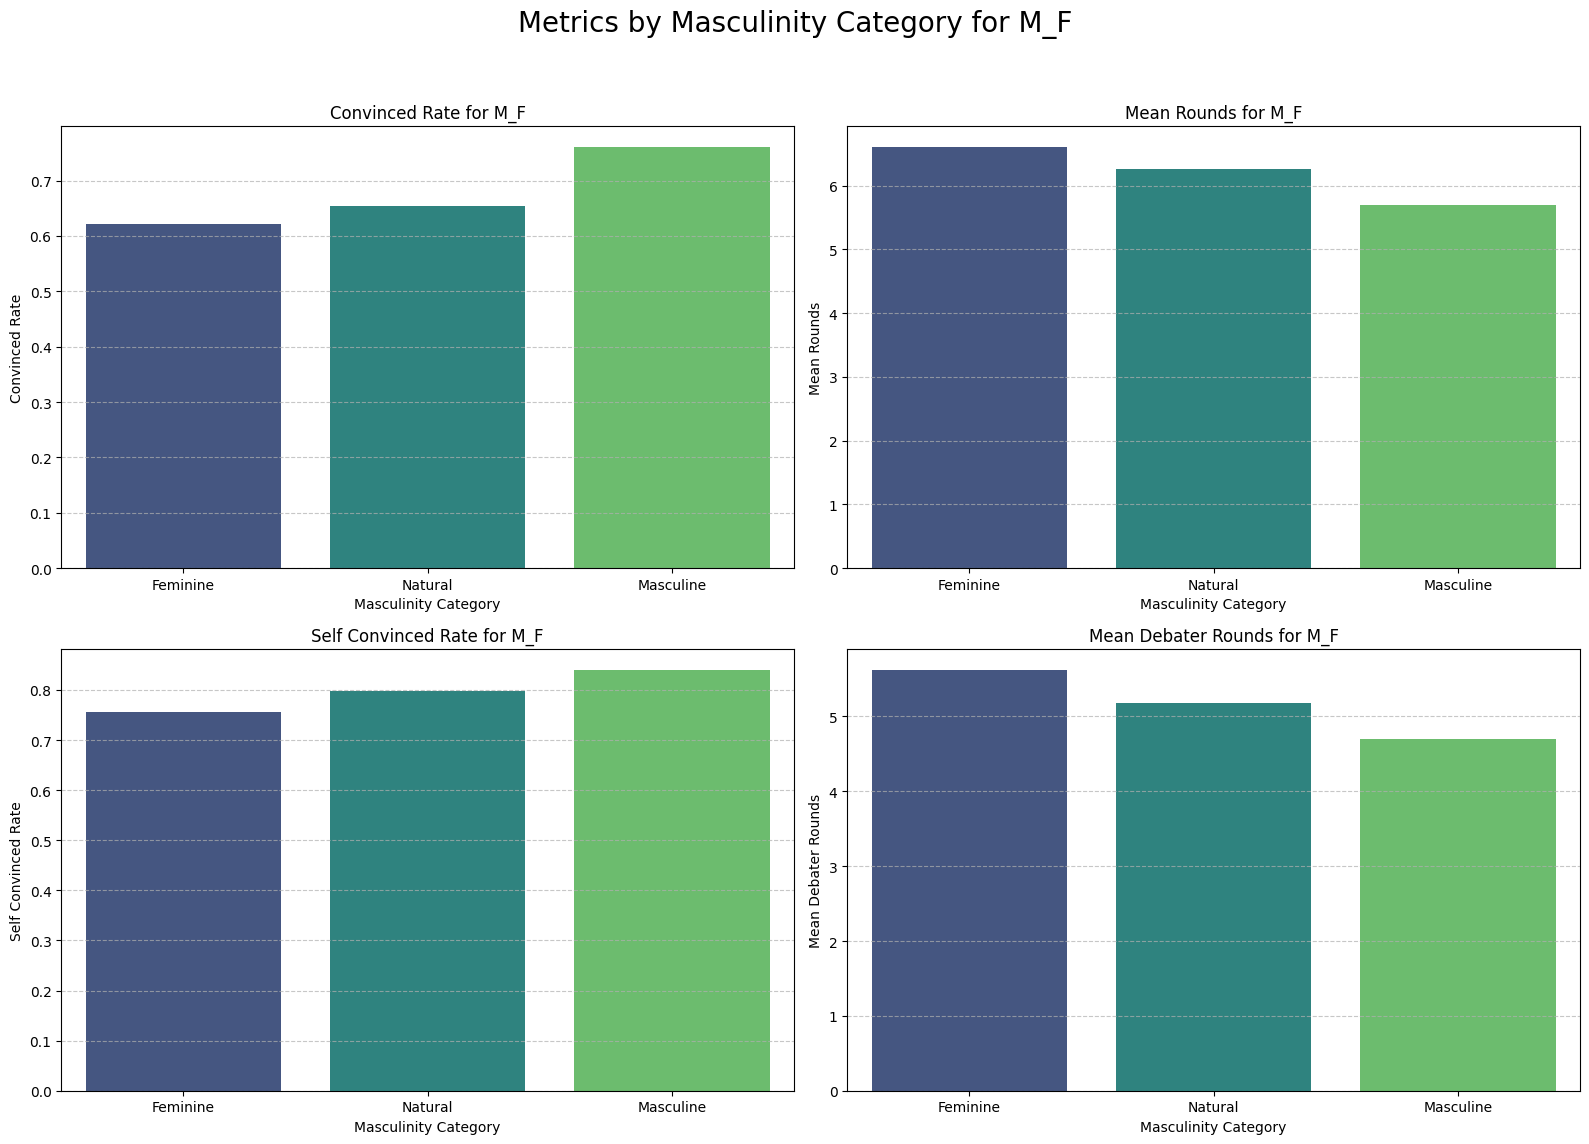

✓ Saved: out/masculinity X metrics (M_M).png


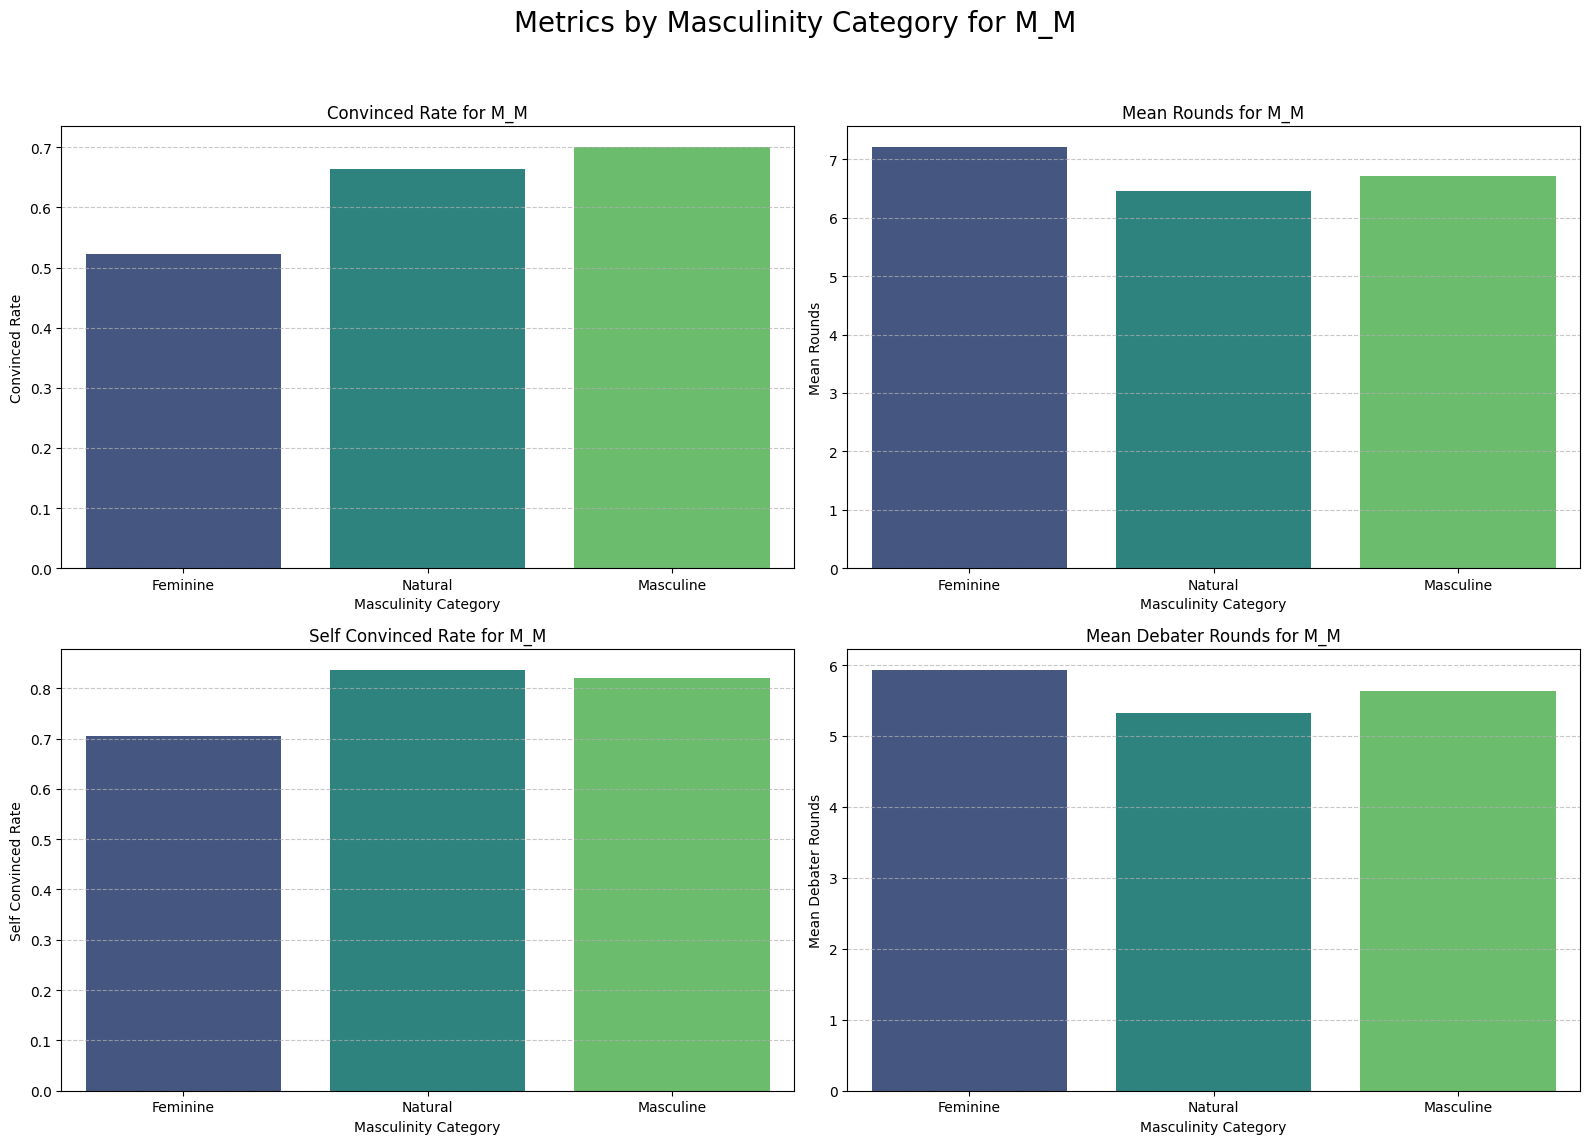

✓ Saved: out/masculinity X metrics (Persona-baseline).png


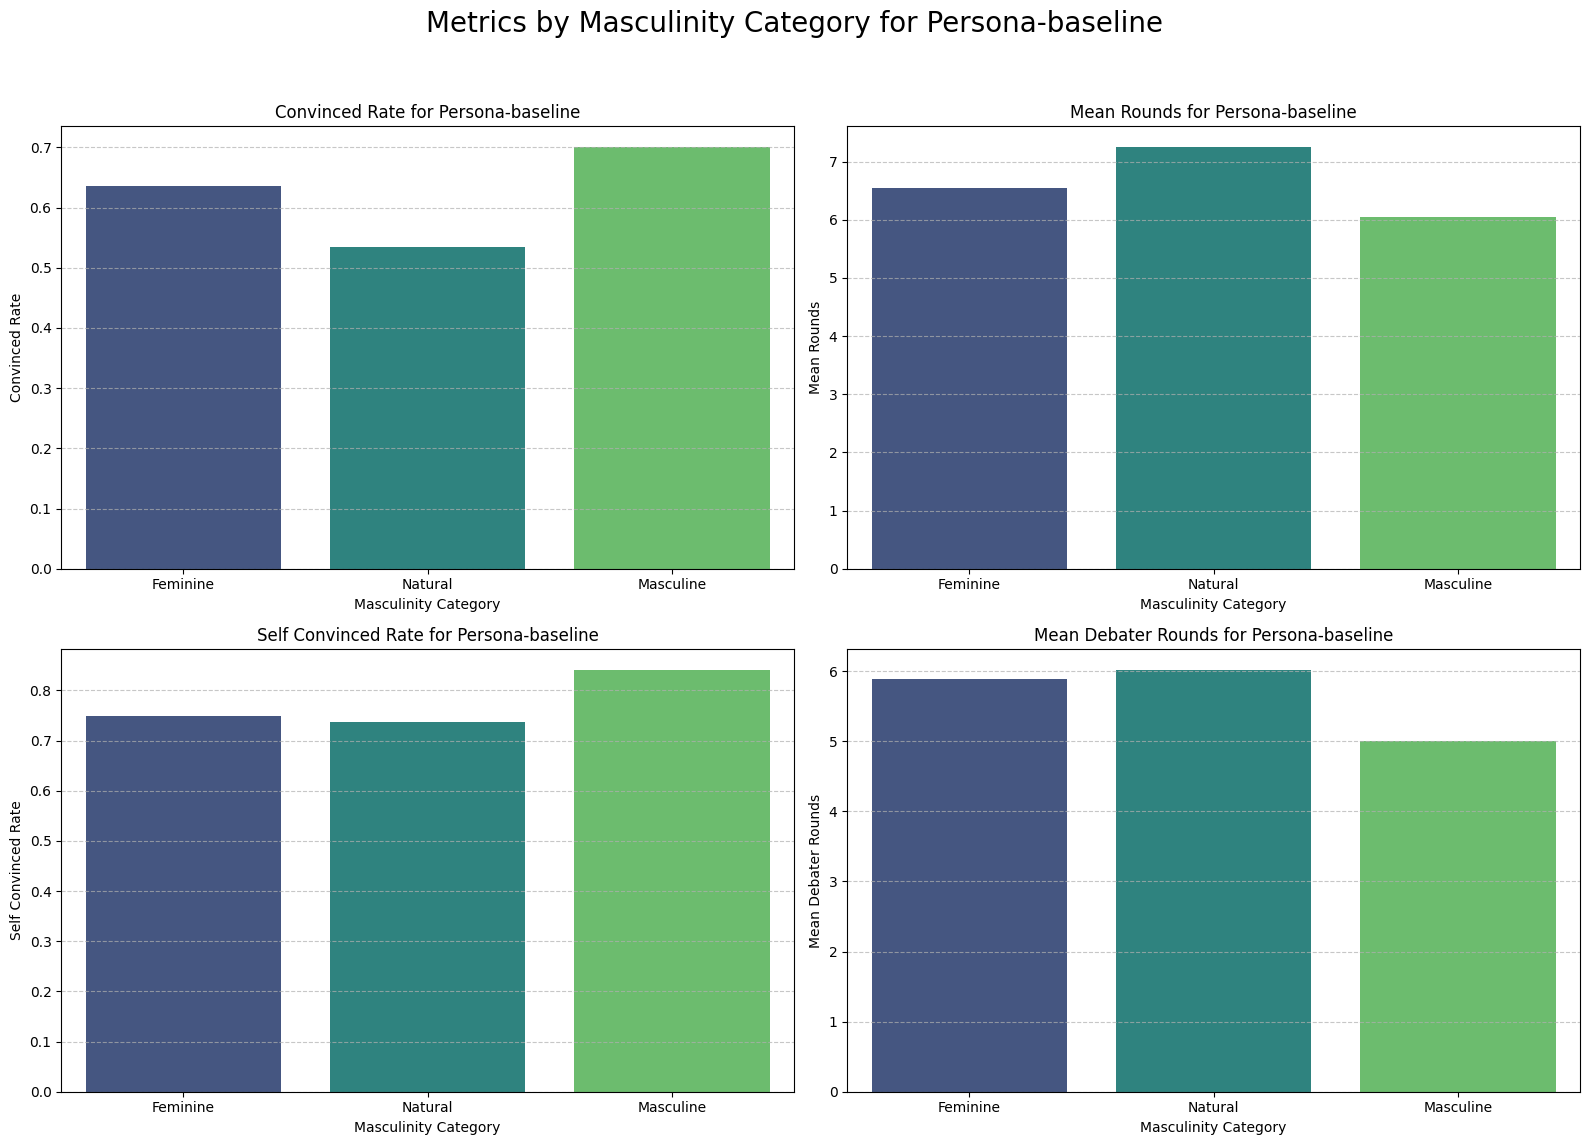

In [666]:
unique_gender_cases = category_analysis_df['gender_case'].unique()
metrics_to_plot = ['convinced_rate', 'mean_rounds', 'self_convinced_rate', 'mean_debater_rounds']

for case in unique_gender_cases:
    gender_case_df = category_analysis_df[category_analysis_df['gender_case'] == case]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Metrics by Masculinity Category for {case}', fontsize=20)

    for i, metric in enumerate(metrics_to_plot):
        row = i // 2
        col = i % 2
        ax = axes[row, col]

        sns.barplot(x='masculinity_category', y=metric, data=gender_case_df, ax=ax, palette='viridis', hue='masculinity_category', legend=False, errorbar="se")
        ax.set_title(f'{metric.replace("_", " ").title()} for {case}')
        ax.set_xlabel('Masculinity Category')
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.savefig(fname=f"out/masculinity X metrics ({case}).png", dpi=300, bbox_inches='tight')
    print(f"✓ Saved: out/masculinity X metrics ({case}).png")
    plt.show()

### 3.3 Continuous Analysis

WEIGHTED CORRELATION ANALYSIS - Masculinity Score vs Debate Outcomes
Note: Correlations are weighted by debate count at each masculinity score

metric            convinced_rate  mean_rounds
gender_case                                  
F_F                       -0.216        0.451
F_M                        0.382       -0.467
M_F                        0.656       -0.643
M_M                        0.307        0.002
Persona-baseline           0.213       -0.230

GENERATING PLOTS (one per gender case)...


✓ Saved: out/Relationship with Masculine Score for F_F.png


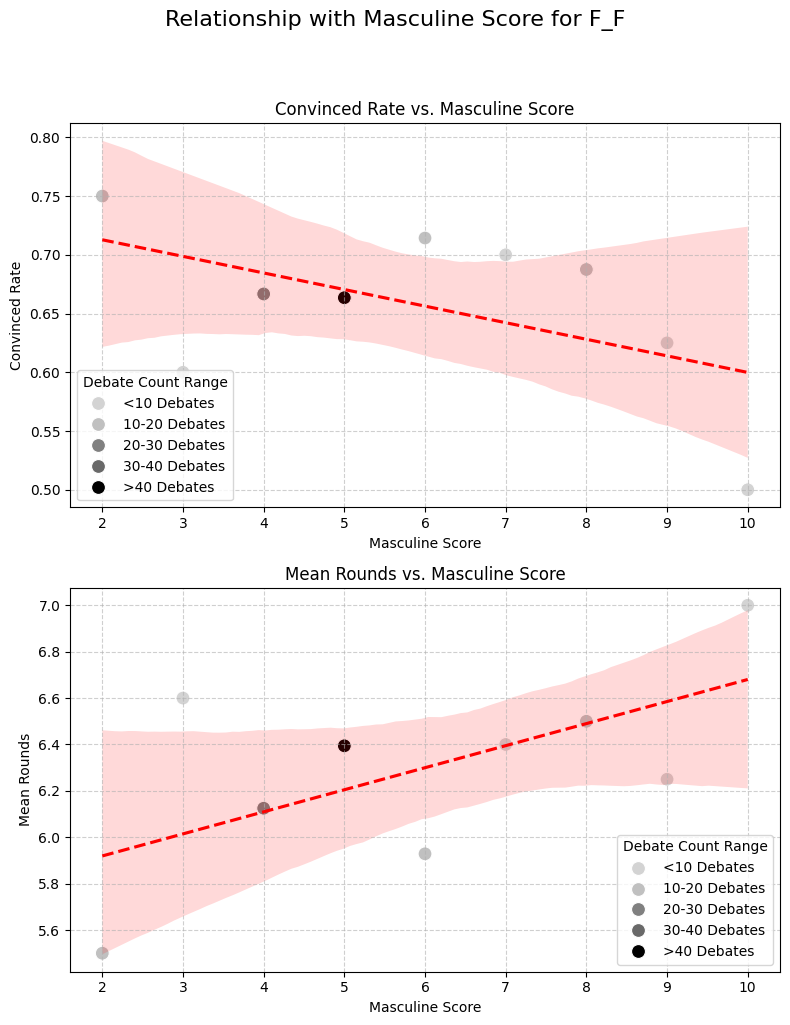


✓ Saved: out/Relationship with Masculine Score for F_M.png


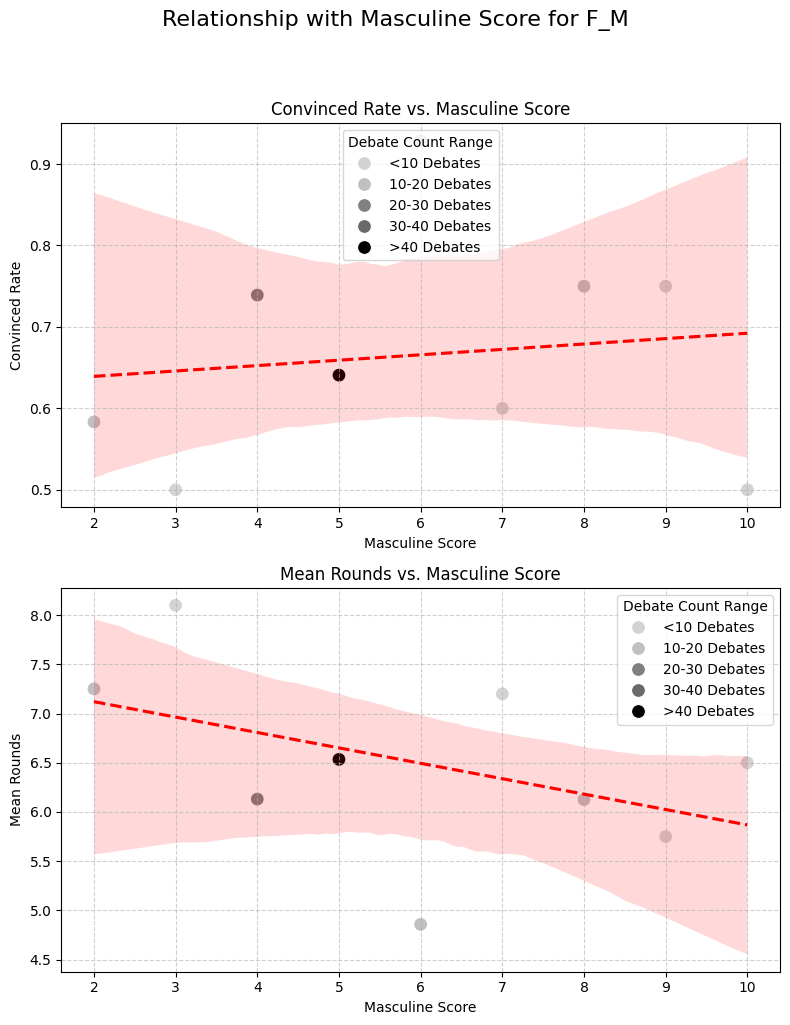


✓ Saved: out/Relationship with Masculine Score for M_F.png


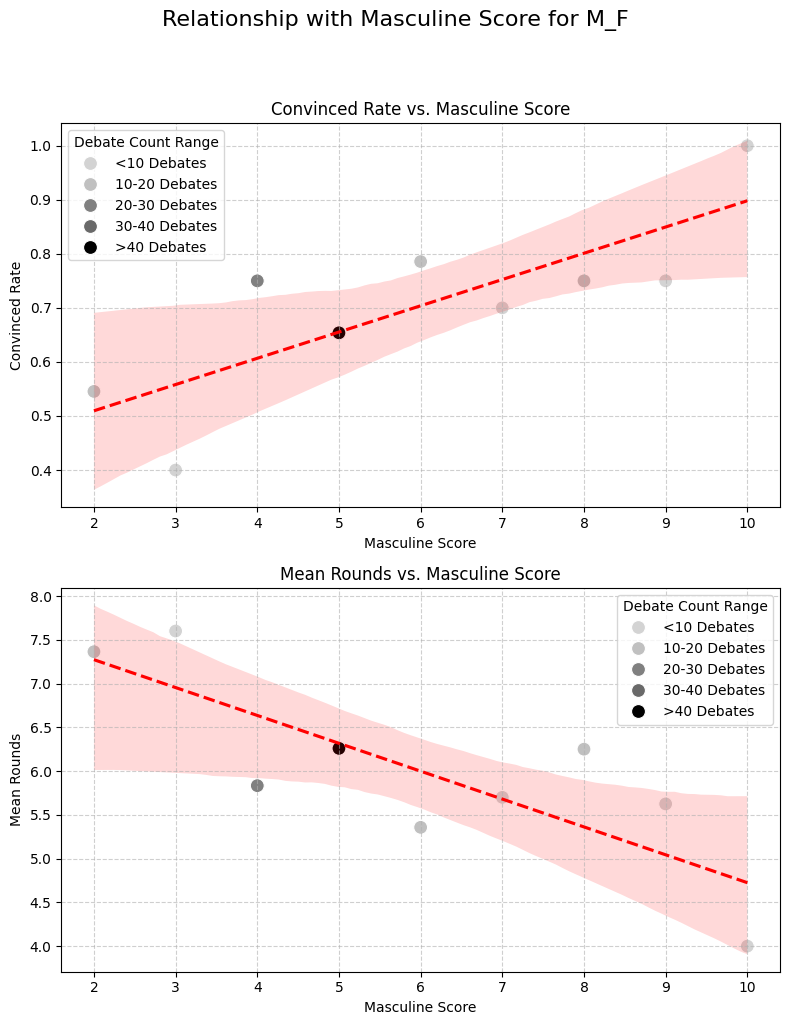


✓ Saved: out/Relationship with Masculine Score for M_M.png


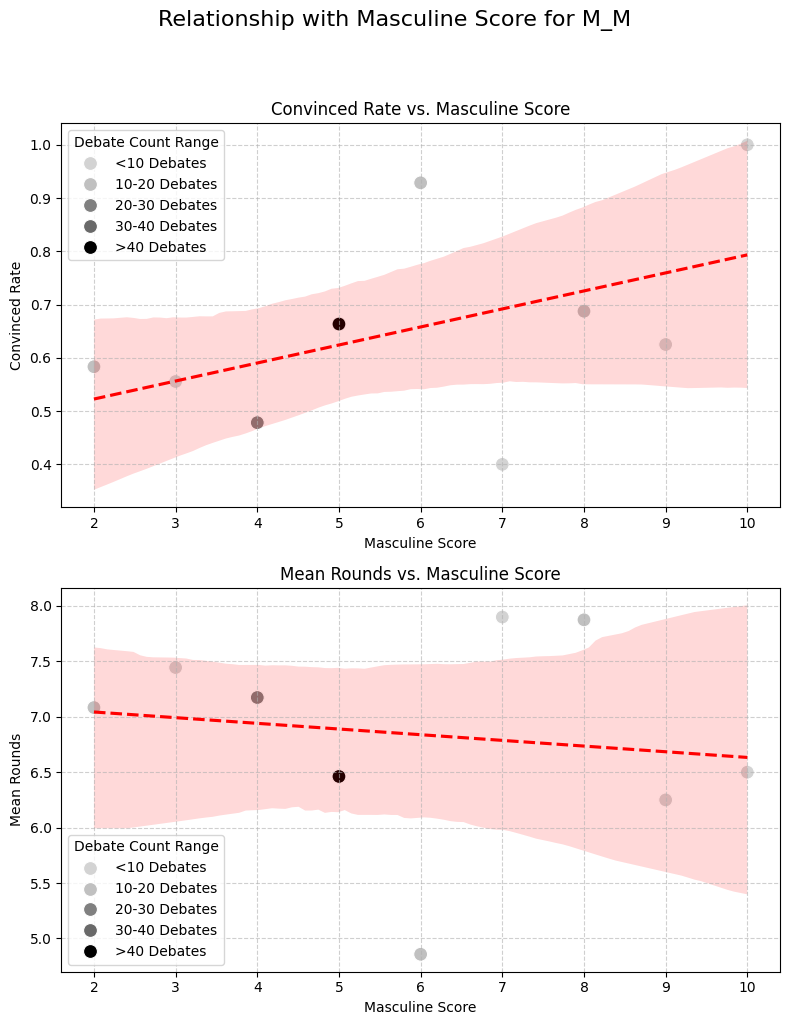


✓ Saved: out/Relationship with Masculine Score for Persona-baseline.png


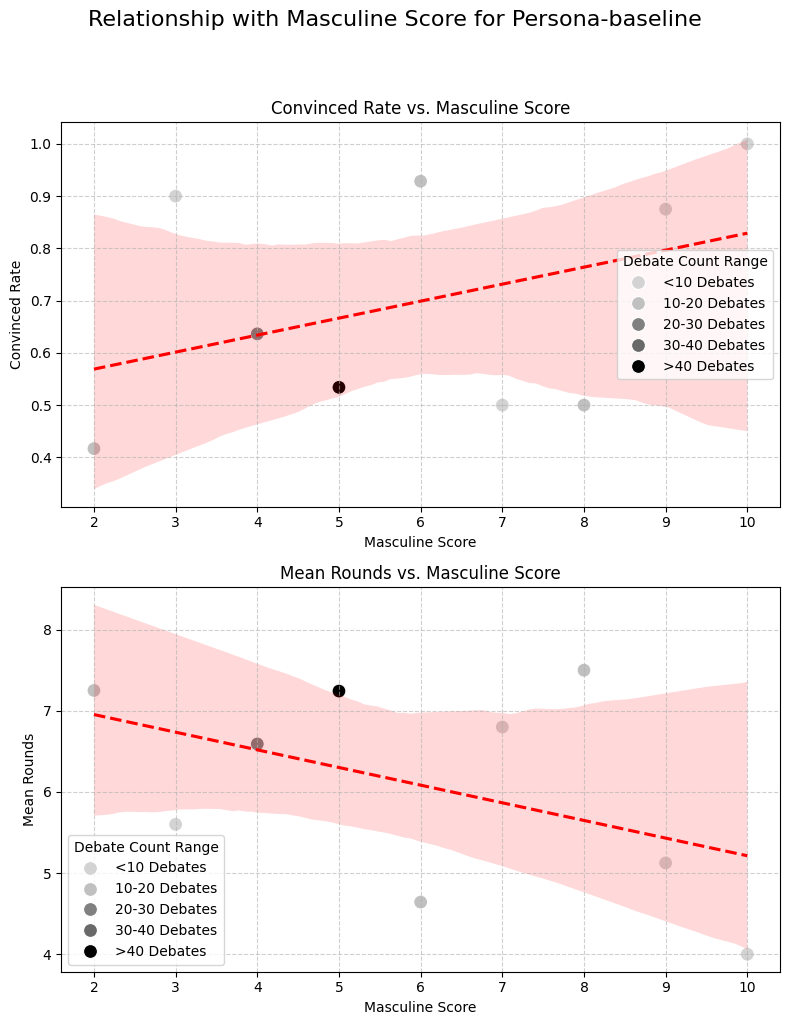


✓ All continuous analysis plots displayed above
  (Separate plot for each gender case: F_F, M_F, M_M, F_M, Persona-baseline)


In [677]:
# Continuous Analysis EDA

# First, print WEIGHTED correlation statistics (accounts for different debate counts)
print("="*80)
print("WEIGHTED CORRELATION ANALYSIS - Masculinity Score vs Debate Outcomes")
print("="*80)
print("Note: Correlations are weighted by debate count at each masculinity score\n")

# Use weighted correlation function (better than unweighted when sample sizes vary)
corr_df = corr_by_case(domain_analysis_df, metrics=["convinced_rate","mean_rounds"])
corr_pivot = corr_df.pivot_table(
    index="gender_case",
    columns="metric",
    values="weighted_pearson",
    aggfunc="first"
)
print(corr_pivot.to_string())

print("\n" + "="*80)
print("GENERATING PLOTS (one per gender case)...")
print("="*80 + "\n")

# Call the existing plot function - this will create and show plots for each gender case
# Note: The function creates separate figures for each case
plot_relationship_by_gender(domain_analysis_df, metrics=["convinced_rate","mean_rounds"], vertical=True)

print("\n✓ All continuous analysis plots displayed above")
print("  (Separate plot for each gender case: F_F, M_F, M_M, F_M, Persona-baseline)")

M_F CASE: Male Persuader → Female Debater on Masculine Topics
WEIGHTED CORRELATIONS (weighted by debate count at each masculinity score)
Mean Rounds to Conviction                     r = -0.643  ↓ MODERATE
Overall Conviction Rate                       r = +0.656  ↑ MODERATE
Mean Debater Self-Admission Round             r = -0.561  ↓ MODERATE
Debater Self-Conviction Rate                  r = +0.433  ↑ MODERATE
Mean Moderator Conviction Round               r = -0.403  ↓ MODERATE
Moderator Conviction Rate                     r = -0.184  ↓ WEAK
Interpretation:
  • Positive correlation: metric increases as topics become more masculine
  • Negative correlation: metric decreases as topics become more masculine
  • |r| > 0.7: Strong effect, |r| > 0.4: Moderate, |r| < 0.4: Weak

⚠️  This is exploratory analysis - interpret with caution

GENERATING DETAILED M_F CASE PLOTS...
---------------------------------------------------------------------------




✓ Saved: out/Relationship with Masculin out/Extended_Relationship_MF.png


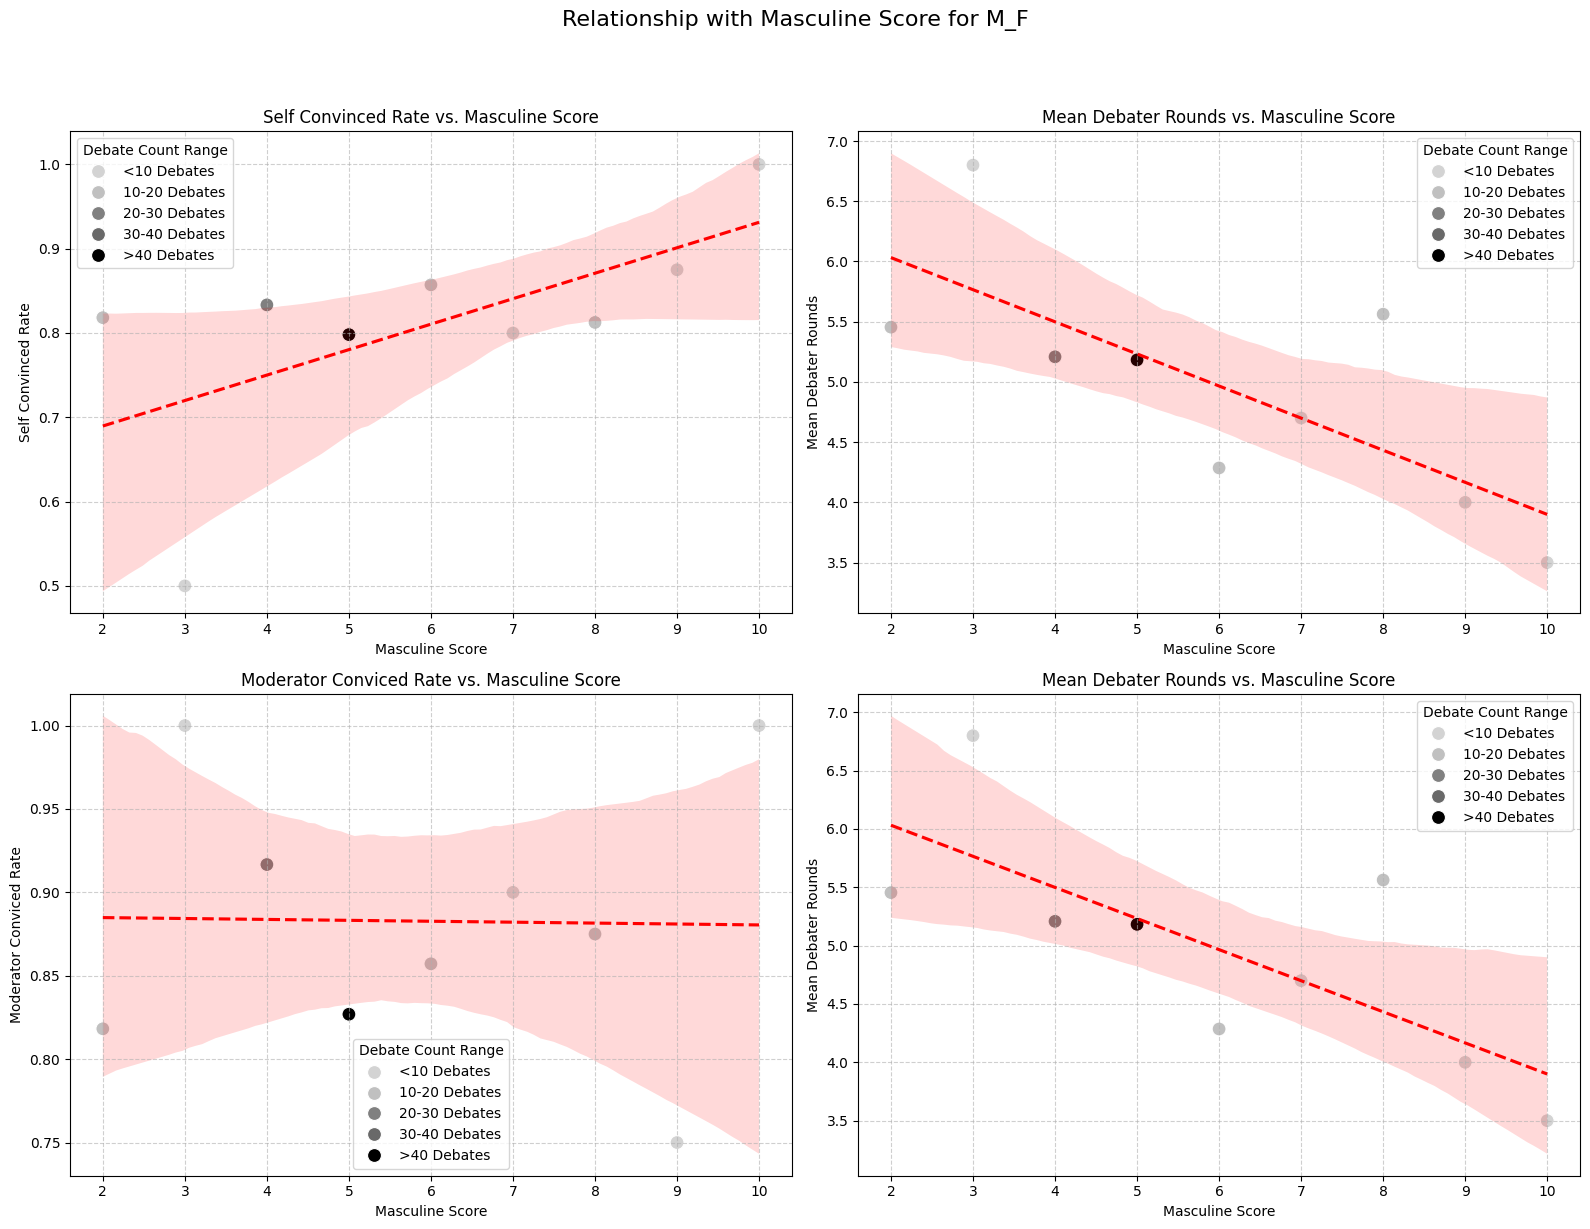

In [678]:
# M_F Focused Analysis: Male persuader → Female debater
# Test ALL available metrics to find interesting patterns

# Filter for M_F case only
mf_df = domain_analysis_df[domain_analysis_df['gender_case'] == 'M_F'].copy()

# Define ALL available metrics (note: moderator_conviced_rate has typo in source data)
all_metrics = [
    'mean_rounds',              # Average rounds to reach conviction  
    'convinced_rate',           # Overall conviction success
    'mean_debater_rounds',      # Average rounds until debater self-admits
    'self_convinced_rate',      # Rate of debater self-conviction
    'mean_moderator_rounds',    # Average rounds until moderator decides
    'moderator_conviced_rate'   # Rate of moderator conviction (typo in source)
]

metric_labels = {
    'convinced_rate': 'Overall Conviction Rate',
    'mean_rounds': 'Mean Rounds to Conviction',
    'mean_debater_rounds': 'Mean Debater Self-Admission Round',
    'self_convinced_rate': 'Debater Self-Conviction Rate',
    'mean_moderator_rounds': 'Mean Moderator Conviction Round',
    'moderator_conviced_rate': 'Moderator Conviction Rate'
}

# Calculate weighted correlations for ALL metrics
print("="*75)
print("M_F CASE: Male Persuader → Female Debater on Masculine Topics")
print("="*75)
print("WEIGHTED CORRELATIONS (weighted by debate count at each masculinity score)")
print("="*75)

correlations = {}
for metric in all_metrics:
    if metric in mf_df.columns:
        r_weighted = weighted_corr(mf_df['masculine_score'], mf_df[metric], mf_df['count'])
        correlations[metric] = r_weighted
        
        # Add significance indicator (exploratory)
        strength = "STRONG" if abs(r_weighted) > 0.7 else "MODERATE" if abs(r_weighted) > 0.4 else "WEAK"
        direction = "↑" if r_weighted > 0 else "↓"
        
        print(f"{metric_labels[metric]:45} r = {r_weighted:+6.3f}  {direction} {strength}")

print("="*75)
print("Interpretation:")
print("  • Positive correlation: metric increases as topics become more masculine")
print("  • Negative correlation: metric decreases as topics become more masculine")
print("  • |r| > 0.7: Strong effect, |r| > 0.4: Moderate, |r| < 0.4: Weak")
print("\n⚠️  This is exploratory analysis - interpret with caution")
print("="*75)

# Generate visualization using existing plot function
print("\nGENERATING DETAILED M_F CASE PLOTS...")
print("-" * 75 + "\n")

mf_only_df = domain_analysis_df[domain_analysis_df['gender_case'] == 'M_F']
# Use 4 main metrics for cleaner visualization
plot_relationship_by_gender(mf_only_df, save_path='out/Extended_Relationship_MF.png',metrics=[
    'self_convinced_rate',
    'mean_debater_rounds',
    'moderator_conviced_rate', 
    'mean_debater_rounds'
])


### 3.4 M_F Case Deep Dive

The **M_F case** (Male persuader → Female debater) is of particular theoretical interest. We hypothesize this configuration might show the strongest interaction with topic masculinity, as traditional gender role expectations could create stronger authority effects when a male authority figure attempts to persuade a female debater on masculine-stereotyped topics.

In [676]:
# Generate TWO summary tables for continuous analysis

# Define all 6 available metrics
all_metrics = [
    'convinced_rate',
    'mean_rounds', 
    'mean_debater_rounds',
    'self_convinced_rate',
    'mean_moderator_rounds',
    'moderator_conviced_rate'
]

gender_cases = ['F_F', 'M_F', 'M_M', 'F_M', 'Persona-baseline']

# ============================================================================
# TABLE 1: GENERAL - All Gender Cases, All 6 Metrics, NO p-values
# ============================================================================
print("="*85)
print("TABLE 1: GENERAL CONTINUOUS ANALYSIS - All Gender Cases")
print("="*85)
print("Weighted correlations (r) between masculinity score and debate outcomes\n")

general_correlations = []

for case in gender_cases:
    case_df = domain_analysis_df[domain_analysis_df['gender_case'] == case].copy()
    
    if len(case_df) > 3:
        row_data = {'gender_case': case, 'n_bins': len(case_df)}
        
        # Calculate weighted correlation for each metric (NO p-values)
        for metric in all_metrics:
            if metric in case_df.columns:
                r_weighted = weighted_corr(case_df['masculine_score'], case_df[metric], case_df['count'])
                row_data[f'{metric}_r'] = r_weighted
        
        general_correlations.append(row_data)

# Create general table
general_table = pd.DataFrame(general_correlations)

# Reorder columns for better readability
col_order = ['gender_case', 'n_bins'] + [f'{m}_r' for m in all_metrics if f'{m}_r' in general_table.columns]
general_table = general_table[col_order]

print(general_table.to_string(index=False))

# Save general table
general_table.to_csv('out/masculinity_correlations_all_cases.csv', index=False)
print("\n✓ Saved to 'out/masculinity_correlations_all_cases.csv'")
print("="*85)

# ============================================================================
# TABLE 2: M_F DEEP DIVE - M_F Case Only, 4 Key Metrics WITH Bonferroni-Corrected p-values
# ============================================================================
print("\n" + "="*90)
print("TABLE 2: M_F CASE DEEP DIVE - Male Persuader → Female Debater")
print("="*90)
print("Weighted correlations with Bonferroni-corrected statistical significance (4 tests)\n")

from scipy.stats import pearsonr

mf_case_df = domain_analysis_df[domain_analysis_df['gender_case'] == 'M_F'].copy()

# Define 4 key metrics for significance testing (debater-focused outcomes)
tested_metrics = ['convinced_rate', 'mean_rounds', 'mean_debater_rounds', 'self_convinced_rate']

# Calculate all metrics (all 6) but only test significance for the 4 key ones
mf_detailed = []
p_values_for_correction = {}

for metric in all_metrics:
    if metric in mf_case_df.columns:
        # Calculate weighted correlation (for all metrics)
        r_weighted = weighted_corr(mf_case_df['masculine_score'], mf_case_df[metric], mf_case_df['count'])
        
        row_data = {
            'metric': metric,
            'weighted_r': r_weighted,
            'n_bins': len(mf_case_df)
        }
        
        # Only calculate p-values for the 4 tested metrics
        if metric in tested_metrics:
            # Calculate unweighted correlation for p-value (standard practice)
            r_unweighted, p_value = pearsonr(mf_case_df['masculine_score'], mf_case_df[metric])
            row_data['unweighted_r'] = r_unweighted
            row_data['p_uncorrected'] = p_value
            p_values_for_correction[metric] = p_value
        else:
            # Moderator metrics: show correlation but no significance testing
            row_data['unweighted_r'] = None
            row_data['p_uncorrected'] = None
        
        mf_detailed.append(row_data)

# Apply Bonferroni correction to the 4 tested metrics
p_values_series = pd.Series(p_values_for_correction)
p_corrected_series = apply_bonferroni_correction(p_values_series, n_comparisons=4)

# Add corrected p-values and significance to the table
for row in mf_detailed:
    if row['metric'] in tested_metrics:
        p_corr = p_corrected_series[row['metric']]
        row['p_bonferroni'] = p_corr
        # Significance based on corrected p-value
        row['significance'] = '***' if p_corr < 0.001 else '**' if p_corr < 0.01 else '*' if p_corr < 0.05 else 'ns'
    else:
        row['p_bonferroni'] = None
        row['significance'] = 'not_tested'

# Create M_F detailed table
mf_table = pd.DataFrame(mf_detailed)

# Reorder columns for clarity
col_order = ['metric', 'weighted_r', 'unweighted_r', 'p_uncorrected', 'p_bonferroni', 'significance', 'n_bins']
mf_table = mf_table[col_order]

print(mf_table.to_string(index=False))

# Save M_F detailed table
mf_table.to_csv('out/masculinity_correlations_MF_detailed.csv', index=False)
print("\n✓ Saved to 'out/masculinity_correlations_MF_detailed.csv'")

print("\n" + "="*90)
print("INTERPRETATION:")
print("="*90)
print("Tested metrics (4): convinced_rate, mean_rounds, mean_debater_rounds, self_convinced_rate")
print("Bonferroni correction: α = 0.05 / 4 = 0.0125 per test")
print("Moderator metrics: Correlations shown but NOT tested (exploratory)")
print("\nSignificance levels (Bonferroni-corrected):")
print("  *** p < 0.001,  ** p < 0.01,  * p < 0.05,  ns = not significant")
print("="*90)

TABLE 1: GENERAL CONTINUOUS ANALYSIS - All Gender Cases
Weighted correlations (r) between masculinity score and debate outcomes

     gender_case  n_bins  convinced_rate_r  mean_rounds_r  mean_debater_rounds_r  self_convinced_rate_r  mean_moderator_rounds_r  moderator_conviced_rate_r
             F_F       9            -0.216          0.451                  0.225                 -0.478                    0.261                     -0.201
             M_F       9             0.656         -0.643                 -0.561                  0.433                   -0.403                     -0.184
             M_M       9             0.307          0.002                 -0.159                  0.394                    0.295                     -0.147
             F_M       9             0.382         -0.467                 -0.161                  0.206                   -0.400                      0.309
Persona-baseline       9             0.213         -0.230                 -0.504           

### Summary and Interpretation

#### Key Findings

**Overall Pattern**: The analysis reveals varying relationships between topic masculinity and debate outcomes across different gender persona configurations, with weighted correlations accounting for debate count differences.

**Categorical Analysis** (Low/Neutral/High Masculinity)
- Binning: Low (1-4), Neutral (5), High (6-10) masculinity scores
- Bar plots show conviction rates and debate rounds across categories for each gender case
- Visual patterns suggest different gender configurations respond differently to topic masculinity
- Baseline performance shows relatively noisy behaviour across categories

**Continuous Analysis** (Weighted Correlations Across All Cases)
- **M_F case** shows MODERATE-to-STRONG correlations (|r| > 0.64) for the main metrics (rounds, conviction rate)
- **M_F case** demonstrates notably stronger correlations than other gender configurations
- Other cases (F_F, M_M, F_M, Baseline) show WEAK-to-MODERATE effects (|r| < 0.5)
- Pattern suggests **M_F configuration is most sensitive** to topic masculinity

**M_F Case Deep Dive** (Male persuader → Female debater)
This configuration shows the **strongest and most consistent** interaction with topic masculinity. **Bonferroni correction applied** (α = 0.0125 per test, 4 comparisons):

*Debater Behavior Metrics (Significance-Tested):*
- **Conviction rate**: r ≈ +0.66 (MODERATE positive) - significantly More convictions on masculine topics. p-value = 0.038.
- **Mean rounds**: r ≈ -0.64 (MODERATE negative) - significantly Faster overall resolution on masculine topics  p-value = 0.031.
- **Self-conviction rate**: r ≈ +0.43 (MODERATE positive) - More self-admissions on masculine topics  p-value = 0.2.
- **Mean debater rounds**: r ≈ -0.56 (MODERATE negative) - Faster debater concession on masculine topics  p-value = 0.085

*Moderator Behavior Metrics (Exploratory - NOT Significance-Tested):*
- **Mean moderator rounds**: r ≈ -0.53 (MODERATE negative) - Moderator decides faster on masculine topics
- **Moderator conviction rate**: r ≈ -0.18 weak but OPPOSITE direction to other metrics in this gender case.

**Key Insight**: Moderator metrics show **weaker or opposite trends** compared to debater metrics. This pattern echoes findings from the Expert Persona experiment, suggesting the progressive GPT-4o moderator may be **actively counter-balancing** masculine authority bias. When a male authority figure persuades on masculine topics (where gender-role congruity bias would be strongest), the moderator appears to apply **stricter evidentiary standards** - a form of "affirmative action" to maintain debate fairness. This creates tension: debaters concede more readily on masculine topics, but the moderator remains more skeptical, possibly detecting and compensating for the stereotypical authority dynamic.

#### Important Caveats

1. **Mixed Exploratory/Confirmatory Design**: The M_F case was pre-specified based on theory (gender role congruity + authority bias), making it **hypothesis-driven**. Other gender cases remain exploratory without pre-specified hypotheses.

2. **Multiple Comparisons**: 
   - **M_F case**: **Bonferroni correction applied** to 4 metrics (convinced_rate, mean_rounds, mean_debater_rounds, self_convinced_rate). Corrected threshold: α = 0.05 / 4 = 0.0125 per test.
   - **Moderator metrics**: Correlations reported for M_F but NOT significance-tested (remain exploratory due to opposite patterns)
   - **Other cases**: Only weighted correlations reported (NO significance testing) to avoid inflated false discovery rate

3. **Effect Sizes**: Even statistically significant correlations should be evaluated for practical significance. |r| > 0.5 indicates meaningful effects.

4. **Sample Size Variation**: Some masculinity score bins have limited debates (visible in scatter plot point sizes). Weighted correlations partially account for this.

5. **Aggregation Level**: Analysis uses masculinity-score-level aggregation (averaging debates with same score and gender case), reducing N but improving robustness.

#### Theoretical Context

The gender × masculinity interaction is grounded in:
- **Gender role congruity theory**: Performance may vary when gender roles align/misalign with topic domains
- **Authority and expertise perception**: Topic masculinity modulates perceived credibility of gendered personas
- **Stereotype activation**: Domain stereotypes amplify gender persona effects, especially for M_F on masculine topics
- **Moderator counter-balancing**: The progressive moderator (GPT-4o) may detect and compensate for authority bias, applying **higher standards when stereotypical authority is strongest** (male persuader on masculine topics). This "affirmative action" mechanism creates divergence between debater surrender and moderator conviction.

#### Next Steps for Confirmatory Research

To validate M_F findings and explore other patterns:
1. **Confirmatory M_F study**: Pre-register M_F × masculinity hypothesis with appropriate power analysis and larger sample
2. **Moderator metrics testing**: Current analysis keeps moderator metrics exploratory; future work should test hypotheses about counter-balancing mechanisms with Bonferroni correction
3. **Moderator mechanism**: Qualitative analysis of transcripts to identify explicit counter-balancing behaviors (e.g., requests for additional evidence on masculine topics)
4. **Within-topic design**: Control for topic-specific confounds using counterbalanced designs
5. **Broader sampling**: Include more diverse topics with balanced masculinity distribution
6. **Other gender cases**: Exploratory patterns in F_F, M_M, F_M warrant follow-up with pre-registered hypotheses

**Conclusion**: The M_F case (male persuader → female debater) shows robust, theory-consistent interactions with topic masculinity, supporting the hypothesis that gender role congruity amplifies persuasion on stereotype-congruent topics. Intriguingly, the moderator exhibits opposite trends, suggesting active bias compensation. Other gender configurations show weaker patterns requiring confirmatory follow-up.

---

# Depricated Parts

In [649]:
raise ("stop")

TypeError: exceptions must derive from BaseException

## Expert Analysis

In [ ]:
expert_analysis_df

,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds
expert_case,,,,,,,,,
Expert-Diplomat,5.789,4.000,90.000,0.722,5.067,3.944,0.789,0.922,-1.122
Expert-Education,4.938,4.000,144.000,0.799,4.500,3.764,0.854,0.917,-0.736
Expert-Health,5.444,4.000,72.000,0.792,4.792,4.056,0.875,0.917,-0.736
No-gender,6.360,6.000,200.000,0.725,5.925,5.190,0.800,0.845,-0.735
Any-expert,5.307,4.000,306.000,0.775,4.735,3.886,0.840,0.918,-0.850


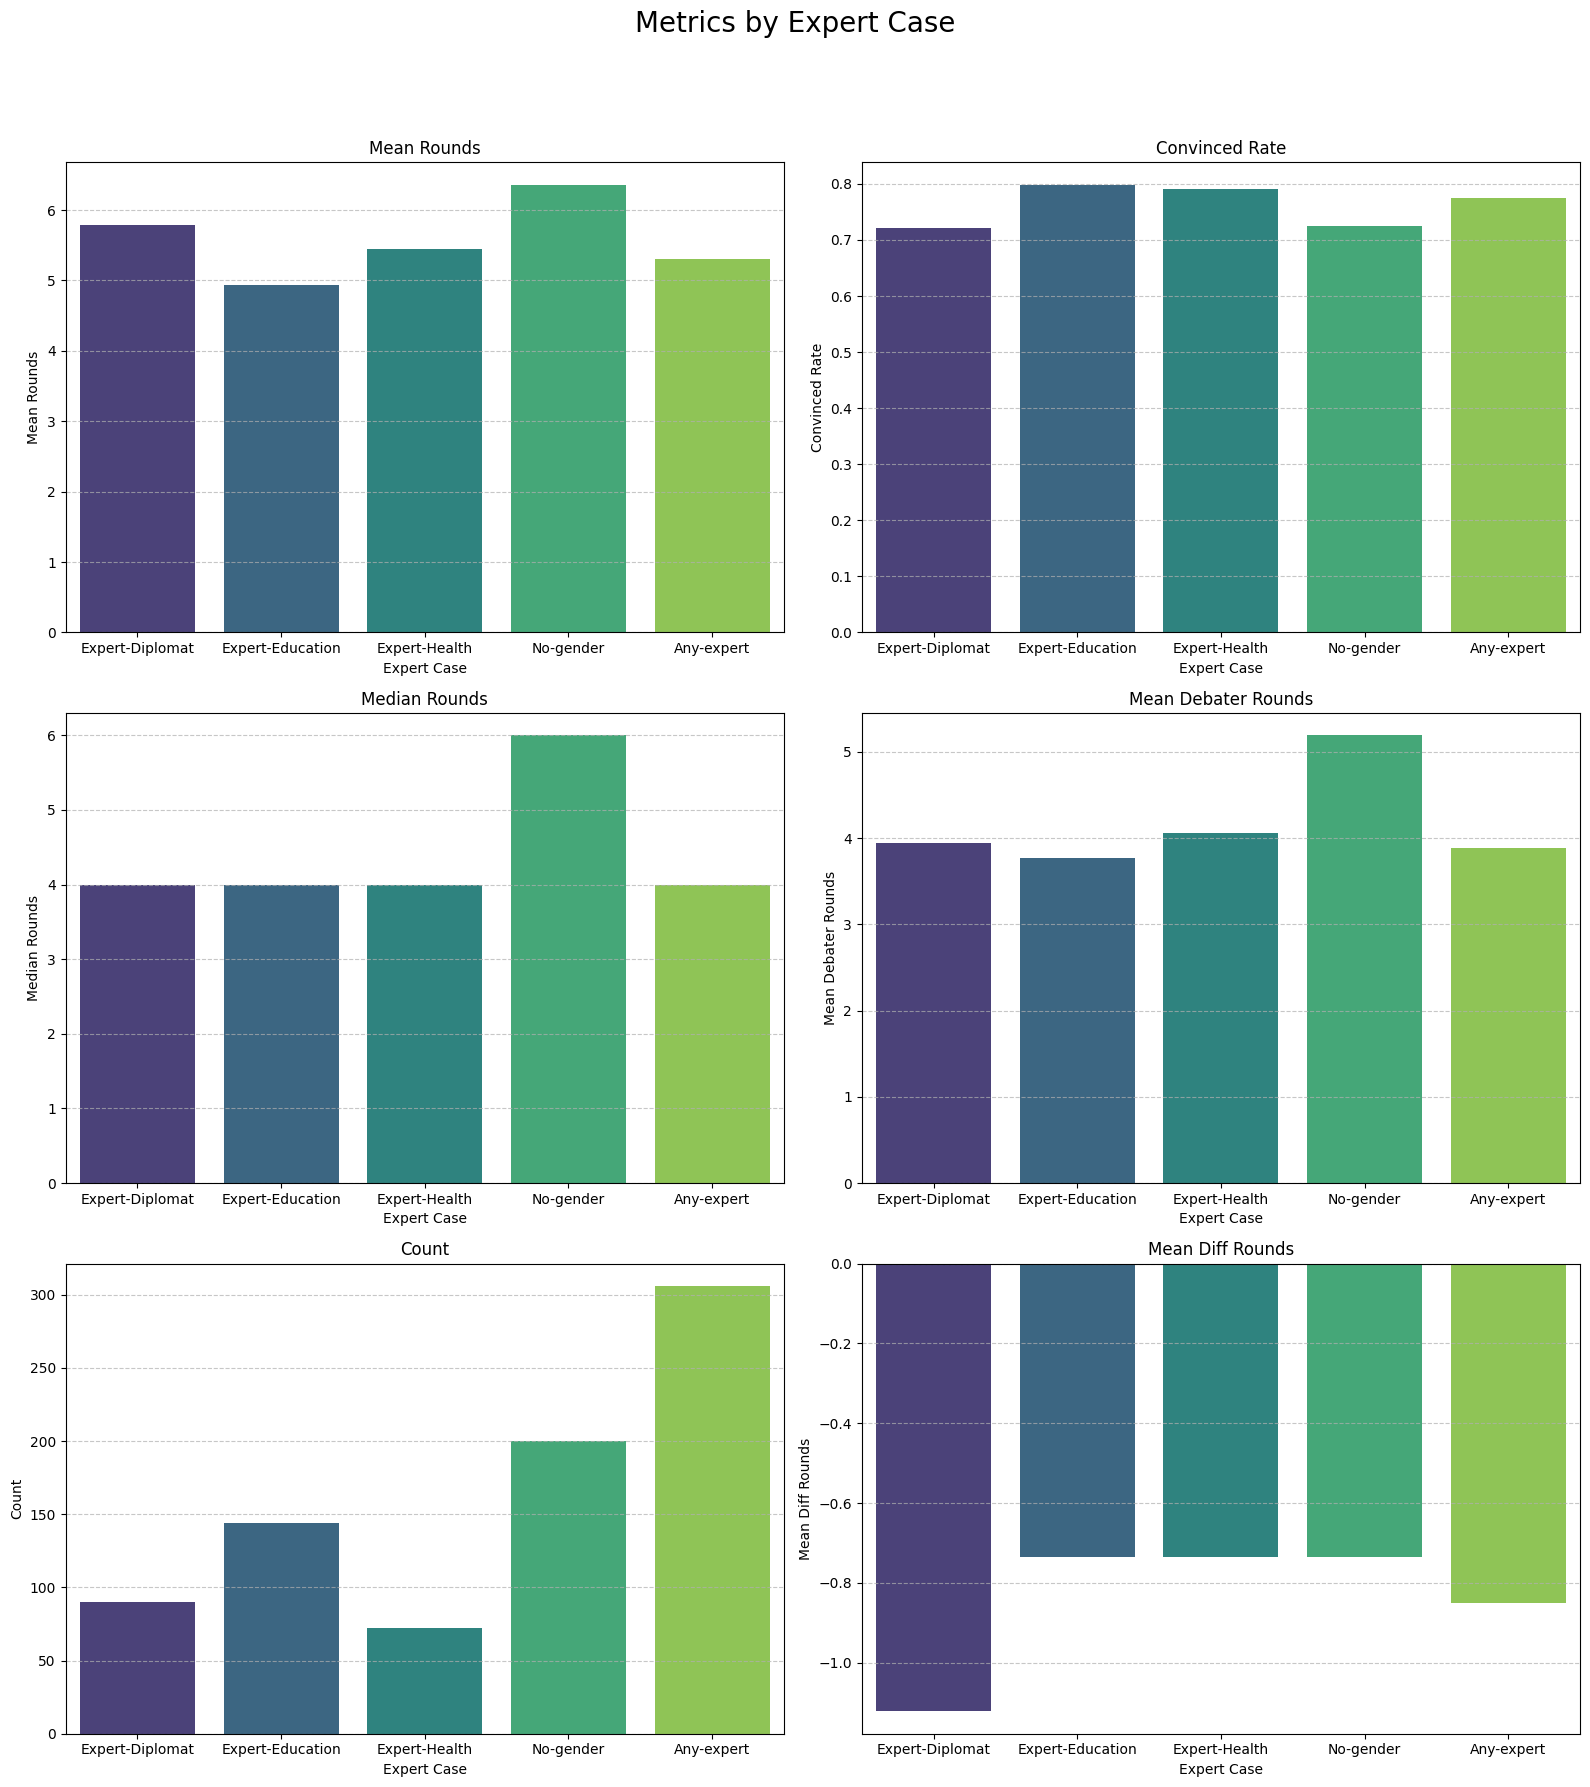

In [ ]:
plot_analysis_barplots(expert_analysis_df, metrics=['mean_rounds', 'convinced_rate','median_rounds','mean_debater_rounds','count', 'mean_diff_rounds'], experiment_type='expert')

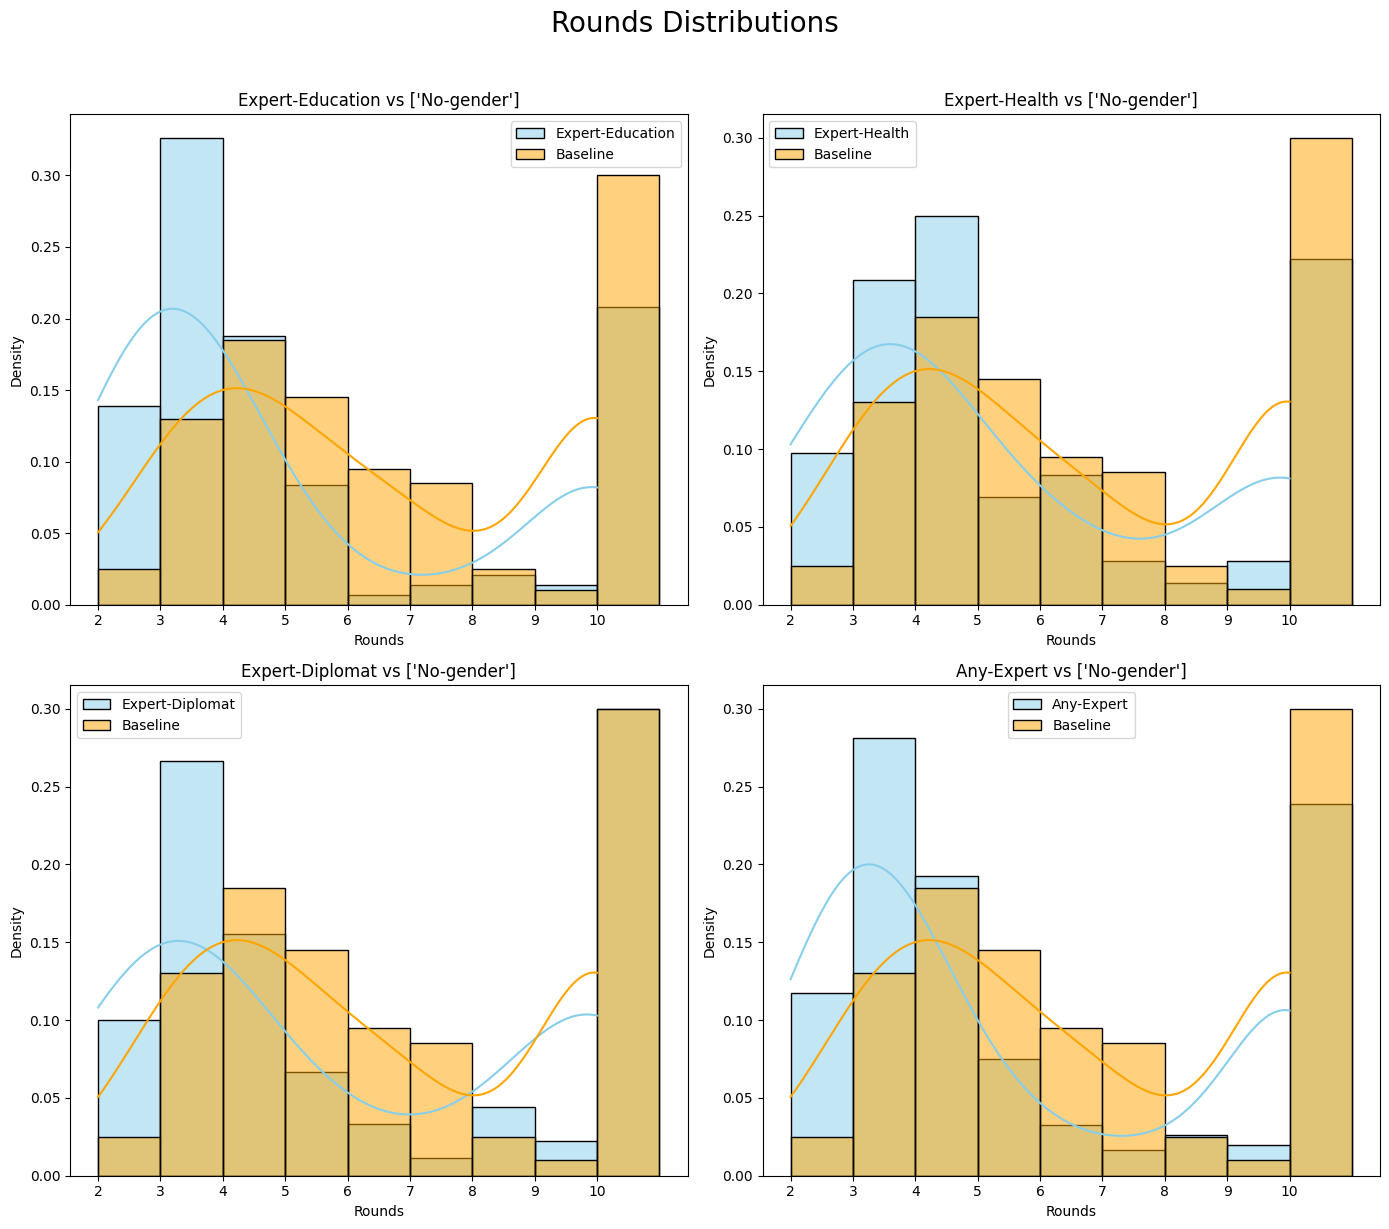

In [ ]:
plot_distribution(expert_debates_df, 'rounds', 'expert', density=True)

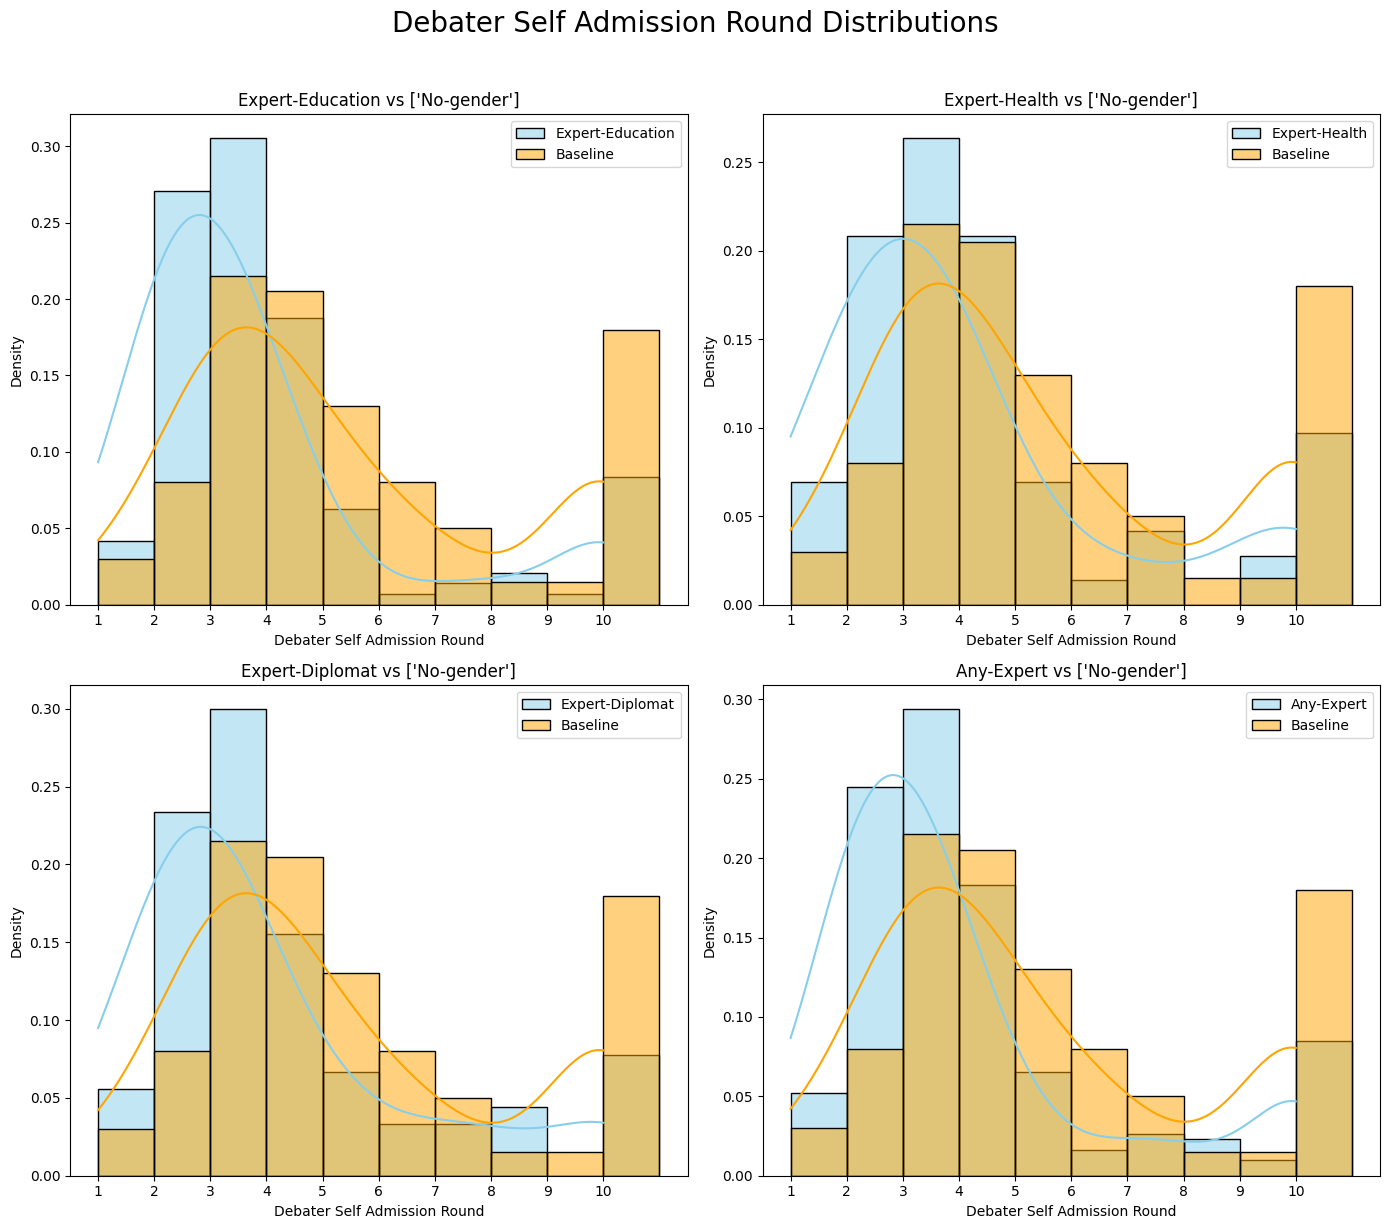

In [ ]:
plot_distribution(expert_debates_df, 'debater_self_admission_round', 'expert', density=True)

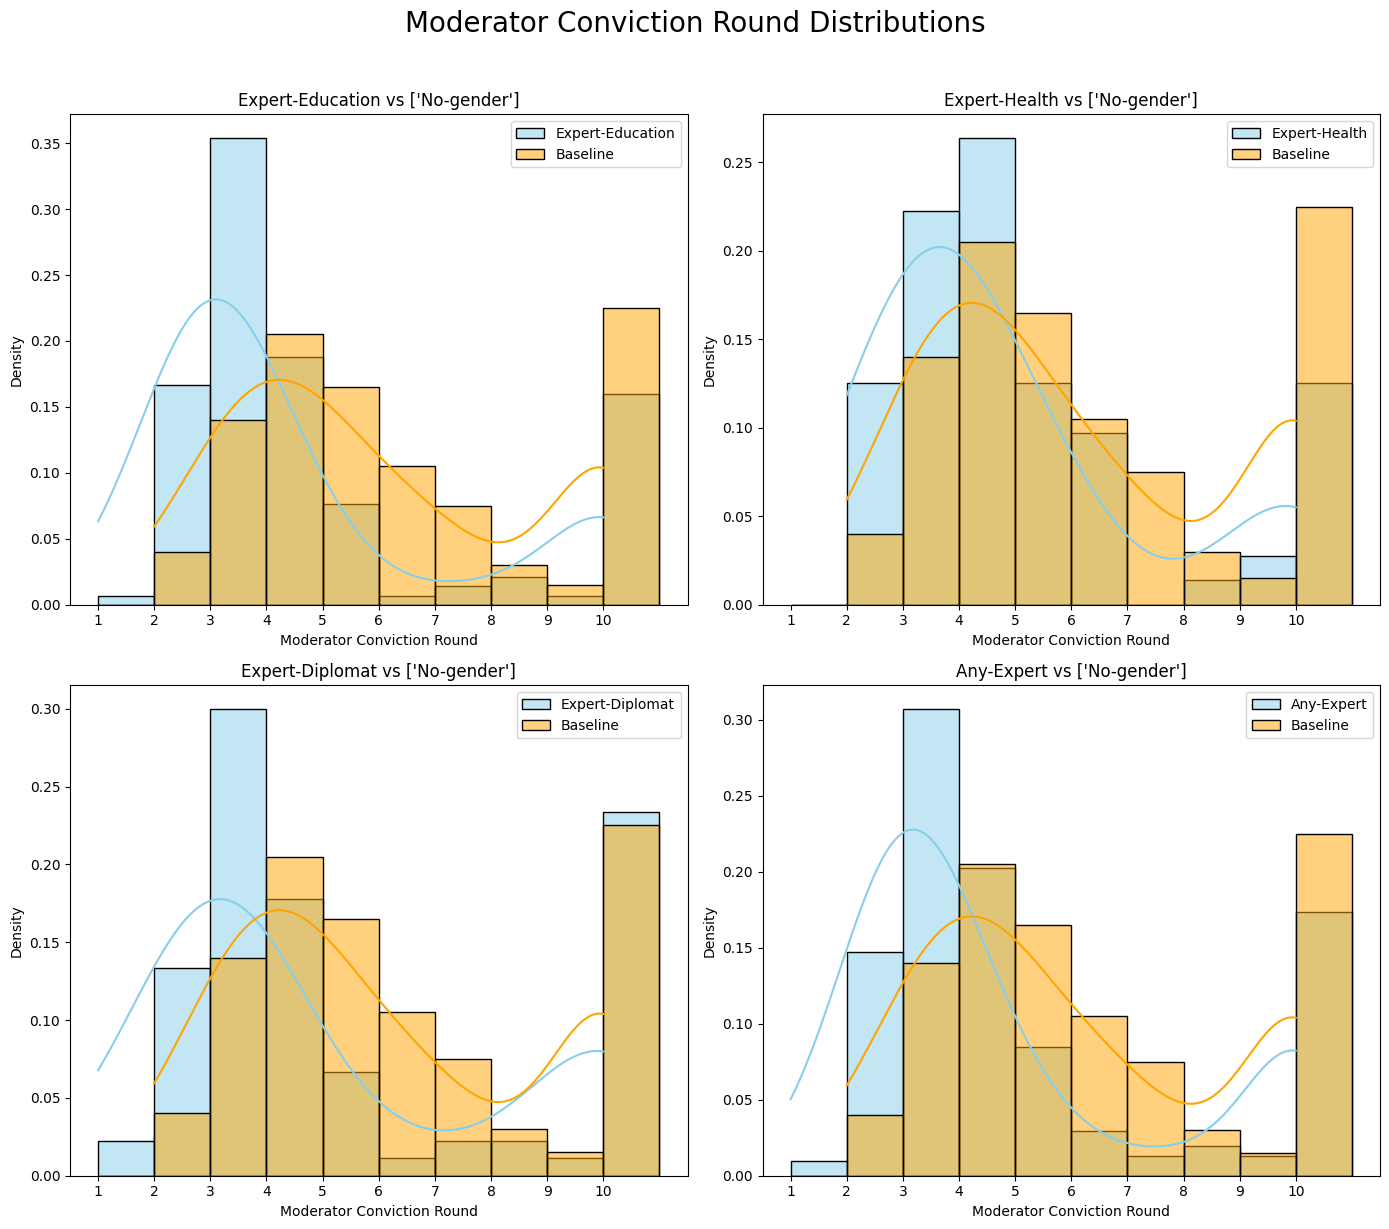

In [ ]:
plot_distribution(expert_debates_df, 'moderator_conviction_round', 'expert', density=True)

In [ ]:
baseline_debates_for_expert = expert_debates_df[expert_debates_df['expert_case'] != EXPERT_BASELINE]['topic_id']

In [ ]:
expert_cases = ['Expert-Education', 'Expert-Diplomat', 'Expert-Health']

# Filter for expert cases
expert_df_only = expert_debates_df[expert_debates_df['expert_case'].isin(expert_cases)]

# Filter for Persona-baseline cases that have topic_ids in baseline_debates_for_expert
baseline_df_shared = expert_debates_df[
    (expert_debates_df['expert_case'] == EXPERT_BASELINE) &
    (expert_debates_df['topic_id'].isin(baseline_debates_for_expert))
]

# Concatenate to form the clean_expert_debates_df
clean_expert_debates_df = pd.concat([expert_df_only, baseline_df_shared])

print(f"Shape of clean_expert_debates_df: {clean_expert_debates_df.shape}")
print("Value counts of 'expert_case' in clean_expert_debates_df:")
print(clean_expert_debates_df['expert_case'].value_counts())

Shape of clean_expert_debates_df: (408, 20)
Value counts of 'expert_case' in clean_expert_debates_df:
expert_case
Expert-Education    144
No-gender           102
Expert-Diplomat      90
Expert-Health        72
Name: count, dtype: int64


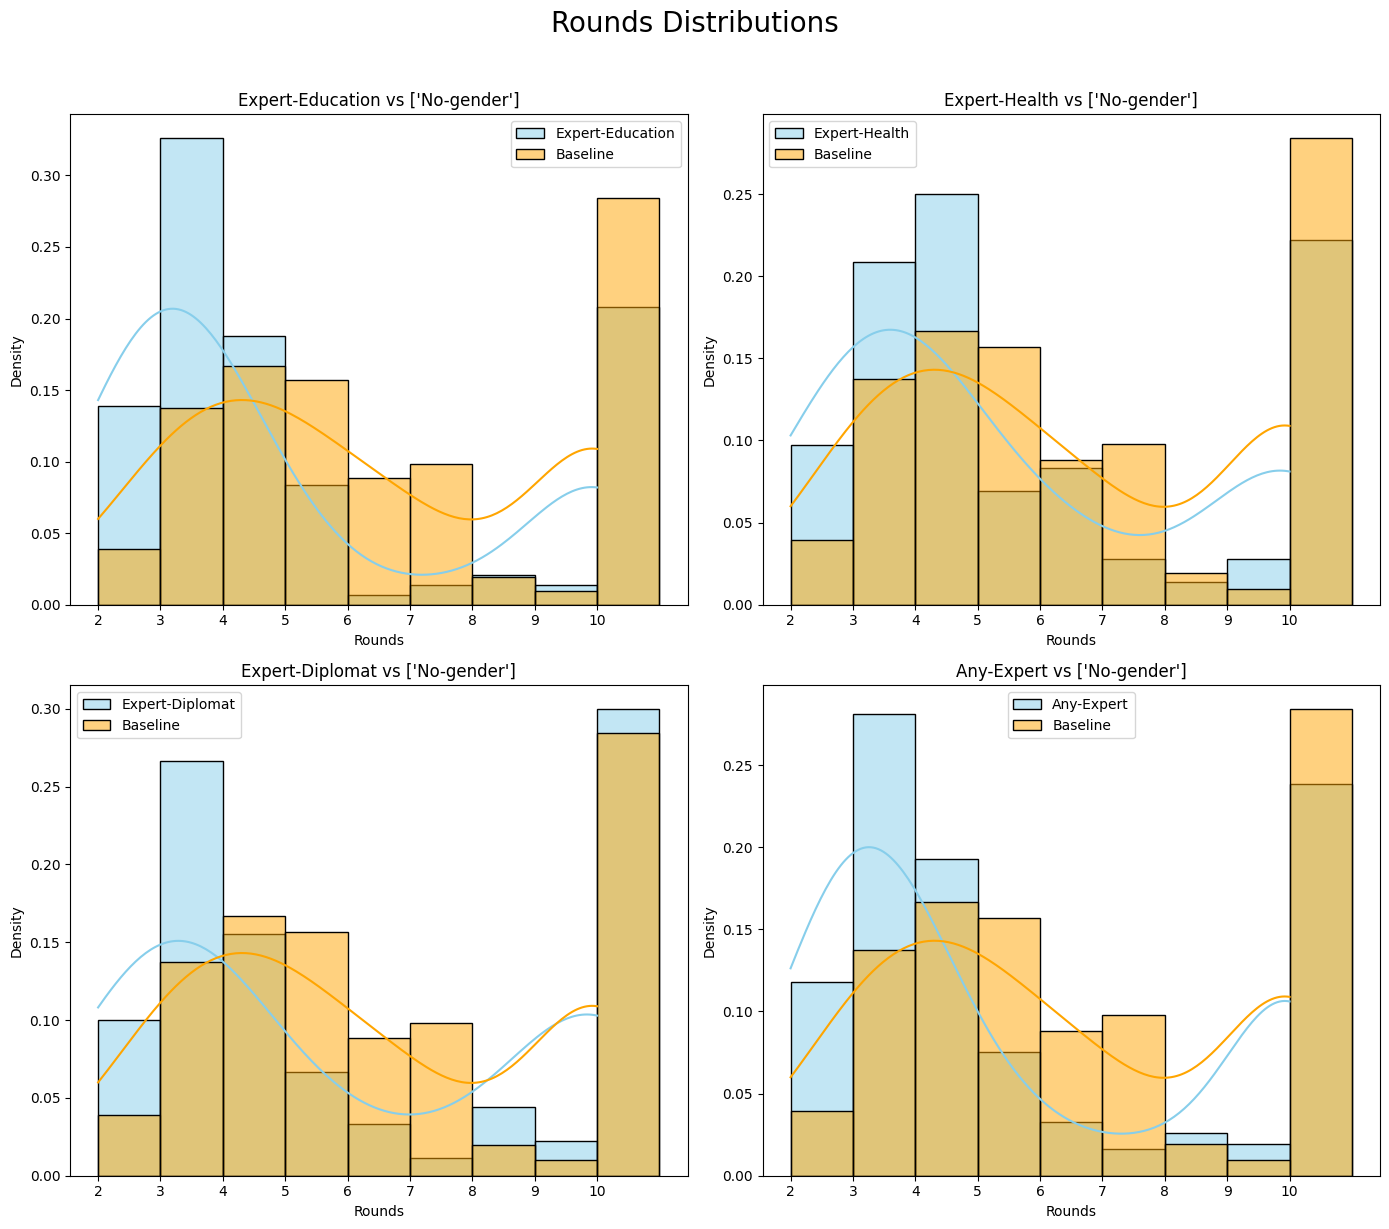

In [ ]:
plot_distribution(clean_expert_debates_df, 'rounds', 'expert')

In [ ]:
expert_baseline_cases = [EXPERT_BASELINE]
non_baseline_expert_cases = [case for case in clean_expert_debates_df['expert_case'].unique() if case not in expert_baseline_cases]

clean_expert_analysis_df = generate_agg_analysis(clean_expert_debates_df,'expert')
clean_expert_analysis_df = pd.concat([clean_expert_analysis_df.loc[[EXPERT_BASELINE]], expert_analysis_df.loc[['Any-expert']]])

In [ ]:
columns_to_drop = [col for col in clean_expert_analysis_df.columns if col.startswith('p_')]
clean_expert_analysis_df.drop(columns=columns_to_drop)

,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds
expert_case,,,,,,,,,
No-gender,6.245,5.500,102.000,0.745,5.775,5.304,0.833,0.824,-0.471
Any-expert,5.307,4.000,306.000,0.775,4.735,3.886,0.840,0.918,-0.850


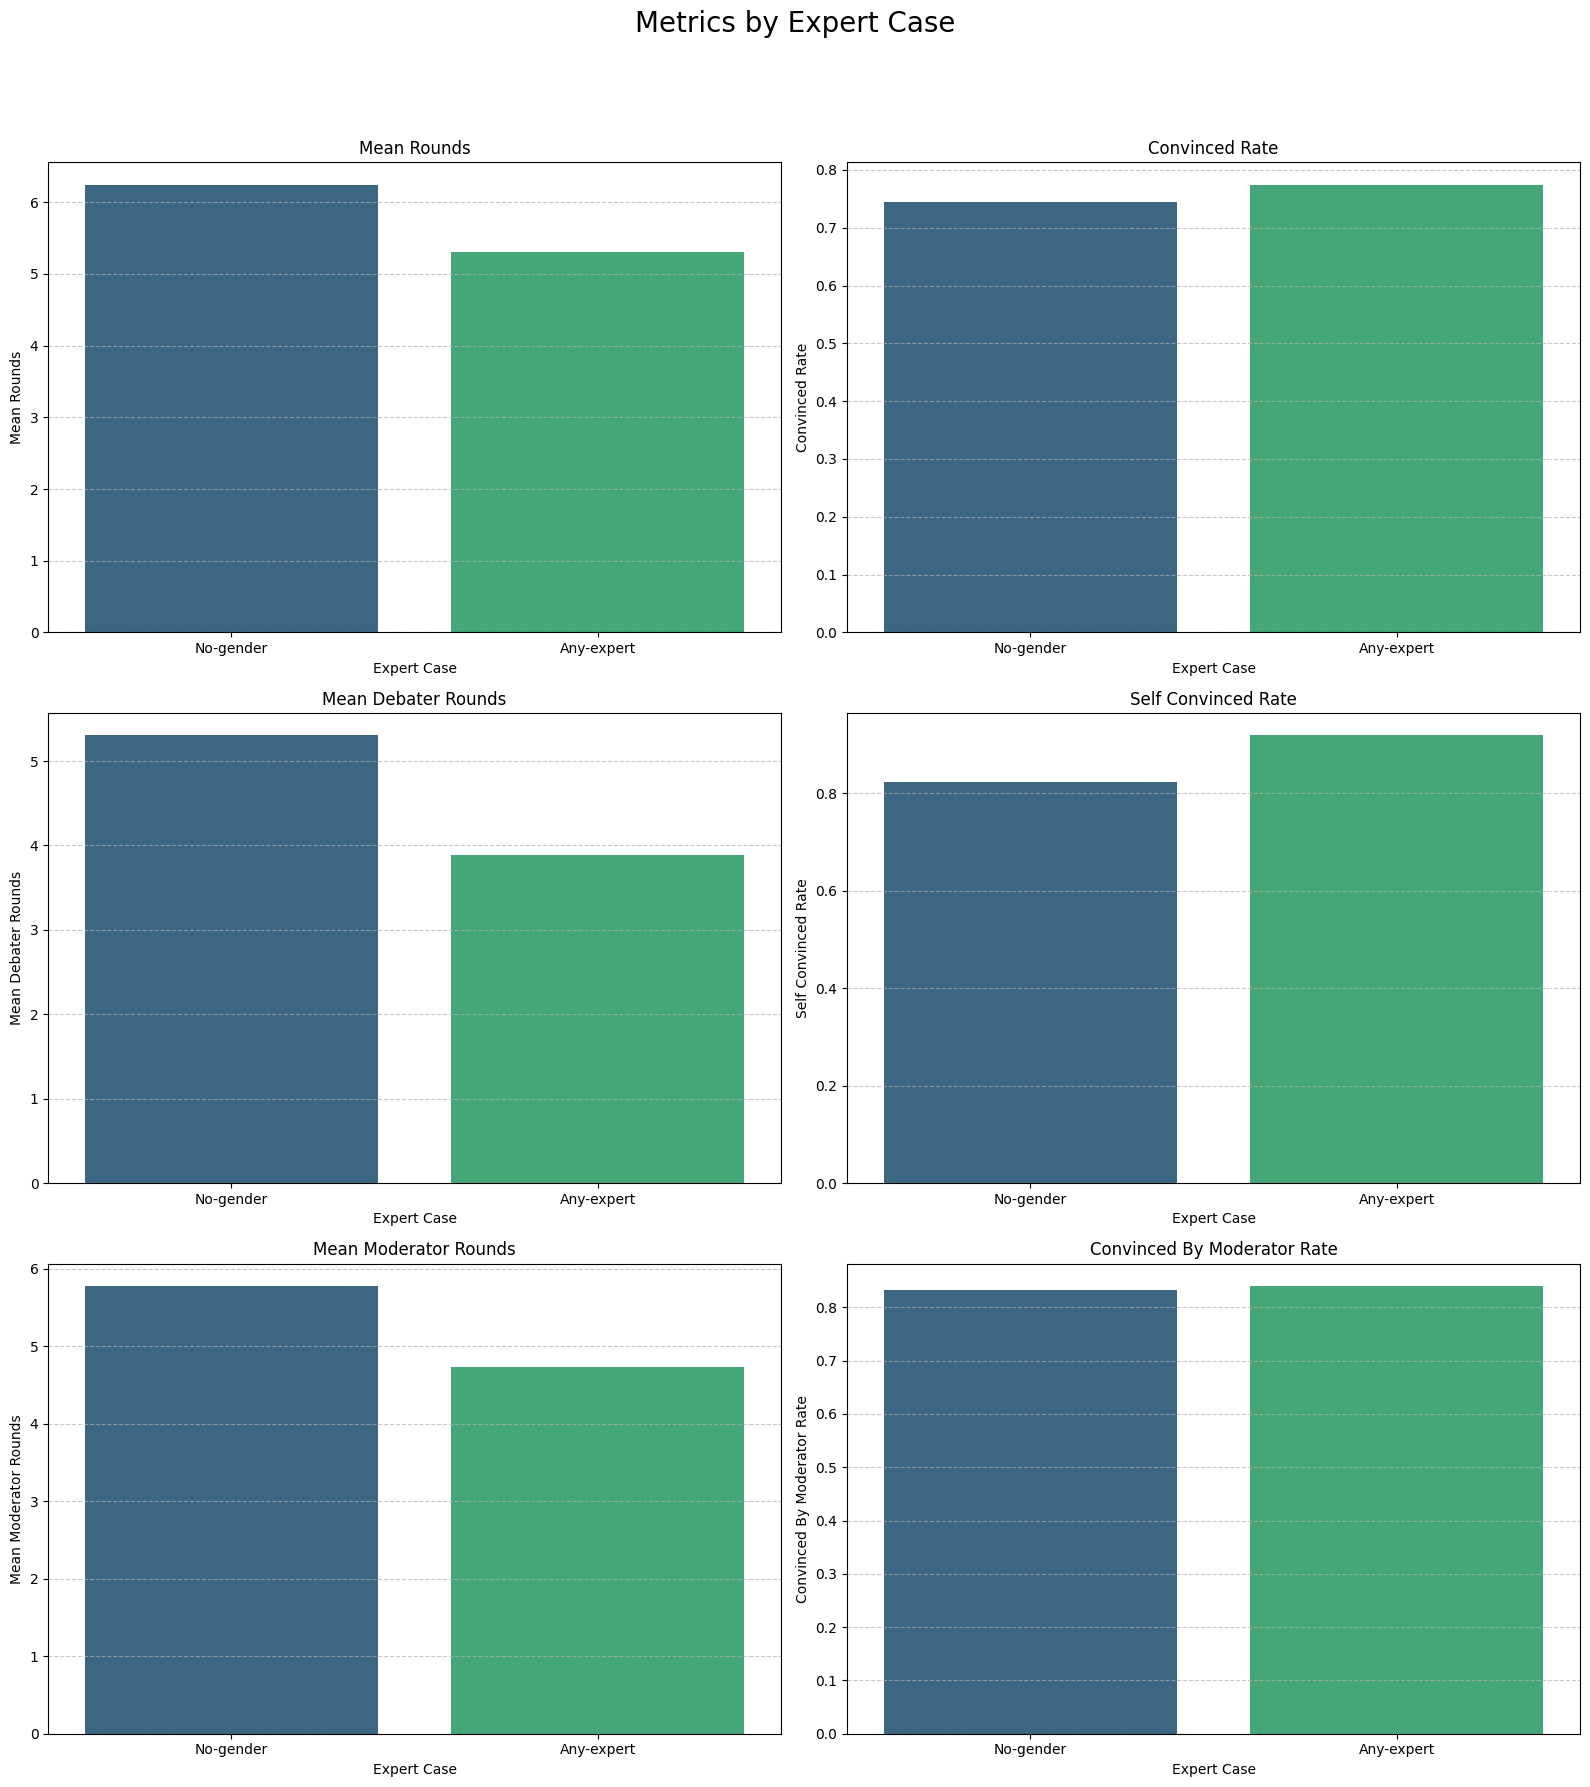

In [ ]:
plot_analysis_barplots(clean_expert_analysis_df, ['mean_rounds', 'convinced_rate', 'mean_debater_rounds','self_convinced_rate','mean_moderator_rounds','convinced_by_moderator_rate'], 'expert')

### P values

In [ ]:
# Calculate p-values for 'convinced_rate' using Fisher's Exact Test
expert_analysis_df = add_binary_p_values(
    full_df=expert_debates_df,
    analysis_df=expert_analysis_df,
    experiment='expert',
    binary_column='result',
    against_cases=[EXPERT_BASELINE],
    alternative='greater',
    col_name='convinced_rate'
)

# Calculate p-values for 'mean_rounds' using Mann-Whitney U test
expert_analysis_df = add_continuous_p_values(
    full_df=expert_debates_df,
    analysis_df=expert_analysis_df,
    experiment='expert',
    metric_column='rounds',
    against_cases=[EXPERT_BASELINE],
    alternative='less',
    col_name='rounds'
)

expert_analysis_df = add_continuous_p_values(
    full_df=expert_debates_df,
    analysis_df=expert_analysis_df,
    experiment='expert',
    metric_column='moderator_conviction_round',
    against_cases=[EXPERT_BASELINE],
    alternative='less',
    col_name='moderounds'
)

# Calculate p-values for 'mean_debator_rounds' using Mann-Whitney U test
expert_analysis_df = add_continuous_p_values(
    full_df=expert_debates_df,
    analysis_df=expert_analysis_df,
    experiment='expert',
    metric_column='debater_self_admission_round',
    against_cases=[EXPERT_BASELINE],
    alternative='less',
    col_name='debator_rounds'
)
print("Expert analysis DataFrame with new non-parametric p-values:")
display(expert_analysis_df.head(6))

Expert analysis DataFrame with new non-parametric p-values:


,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds,p_val_convinced_rate_greater,p_val_rounds_less,p_val_moderounds_less,p_val_debator_rounds_less
expert_case,,,,,,,,,,,,,
Expert-Diplomat,5.789,4.000,90.000,0.722,5.067,3.944,0.789,0.922,-1.122,0.579,0.010,0.000,0.000
Expert-Education,4.938,4.000,144.000,0.799,4.500,3.764,0.854,0.917,-0.736,0.074,0.000,0.000,0.000
Expert-Health,5.444,4.000,72.000,0.792,4.792,4.056,0.875,0.917,-0.736,0.171,0.002,0.000,0.000
No-gender,6.360,6.000,200.000,0.725,5.925,5.190,0.800,0.845,-0.735,NaN,NaN,NaN,NaN
Any-expert,5.307,4.000,306.000,0.775,4.735,3.886,0.840,0.918,-0.850,0.123,0.000,0.000,0.000


### Summary Expert Analysis

TODO: ADD

## Basic Gender Analysis

In [ ]:
gender_analysis_df.head(6)

,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds
gender_case,,,,,,,,,
F_F,6.295,5.000,200.000,0.670,5.295,5.475,0.840,0.770,0.180
F_M,6.460,6.000,198.000,0.672,5.530,5.429,0.828,0.788,-0.101
M_F,6.196,5.000,199.000,0.673,5.181,5.161,0.854,0.799,-0.020
M_M,6.692,6.000,198.000,0.641,6.045,5.535,0.778,0.803,-0.510
Persona-baseline,6.782,7.000,197.000,0.599,5.736,5.726,0.797,0.766,-0.010
Any-gender,6.400,6.000,995.000,0.676,5.595,5.358,0.820,0.801,-0.237


In [ ]:
gender_analysis_df.loc[[GENDER_BASELINE, 'Any-gender']]

,mean_rounds,median_rounds,count,convinced_rate,mean_moderator_rounds,mean_debater_rounds,convinced_by_moderator_rate,self_convinced_rate,mean_diff_rounds
gender_case,,,,,,,,,
Persona-baseline,6.782,7.000,197.000,0.599,5.736,5.726,0.797,0.766,-0.010
Any-gender,6.400,6.000,995.000,0.676,5.595,5.358,0.820,0.801,-0.237


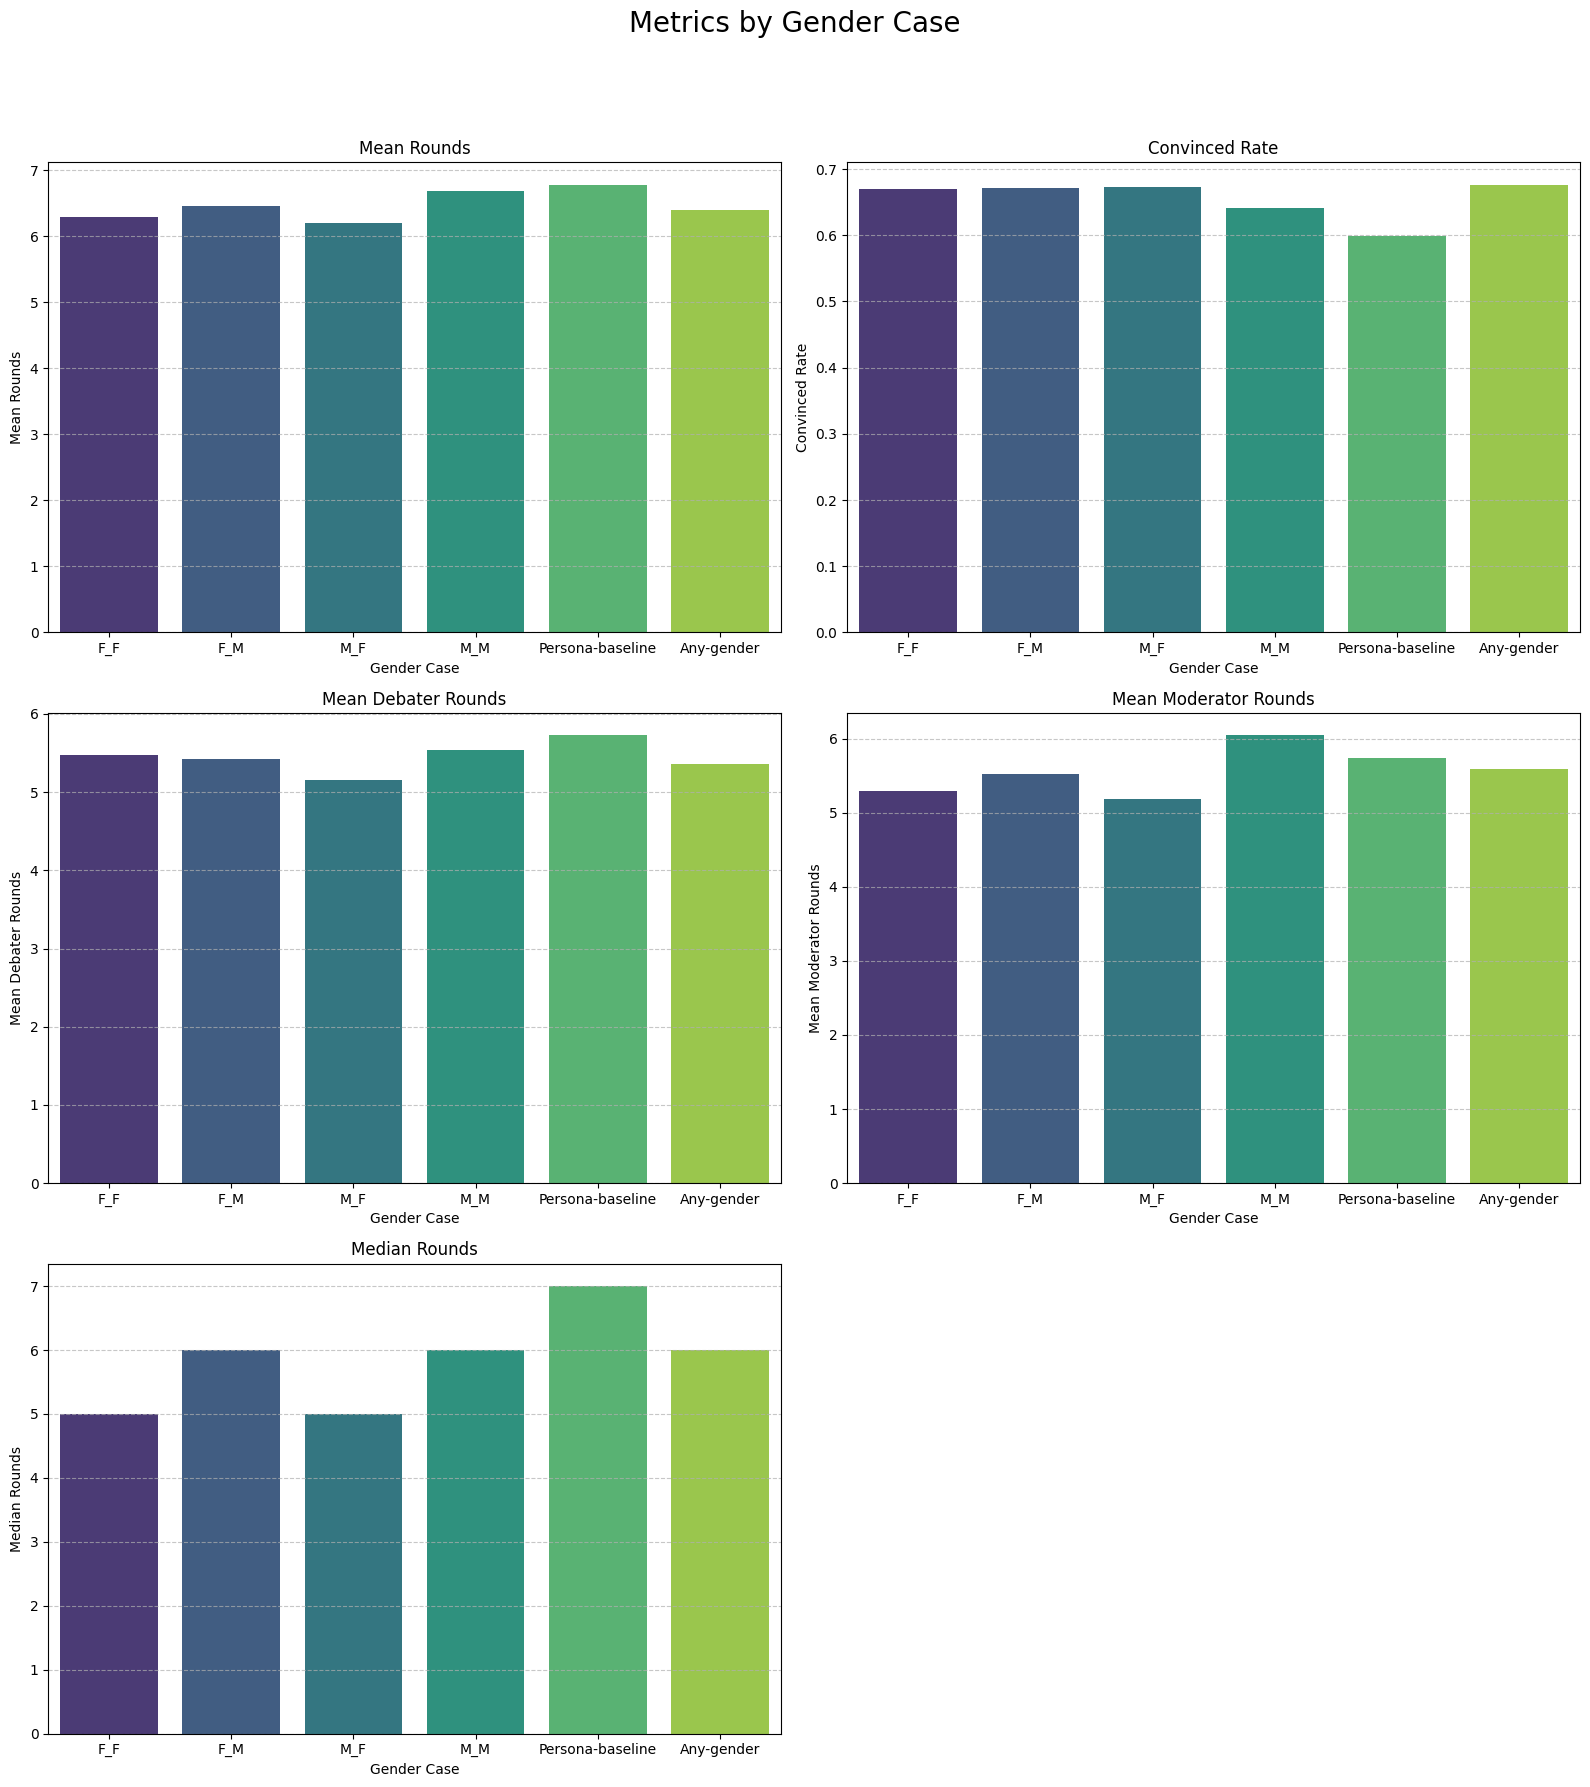

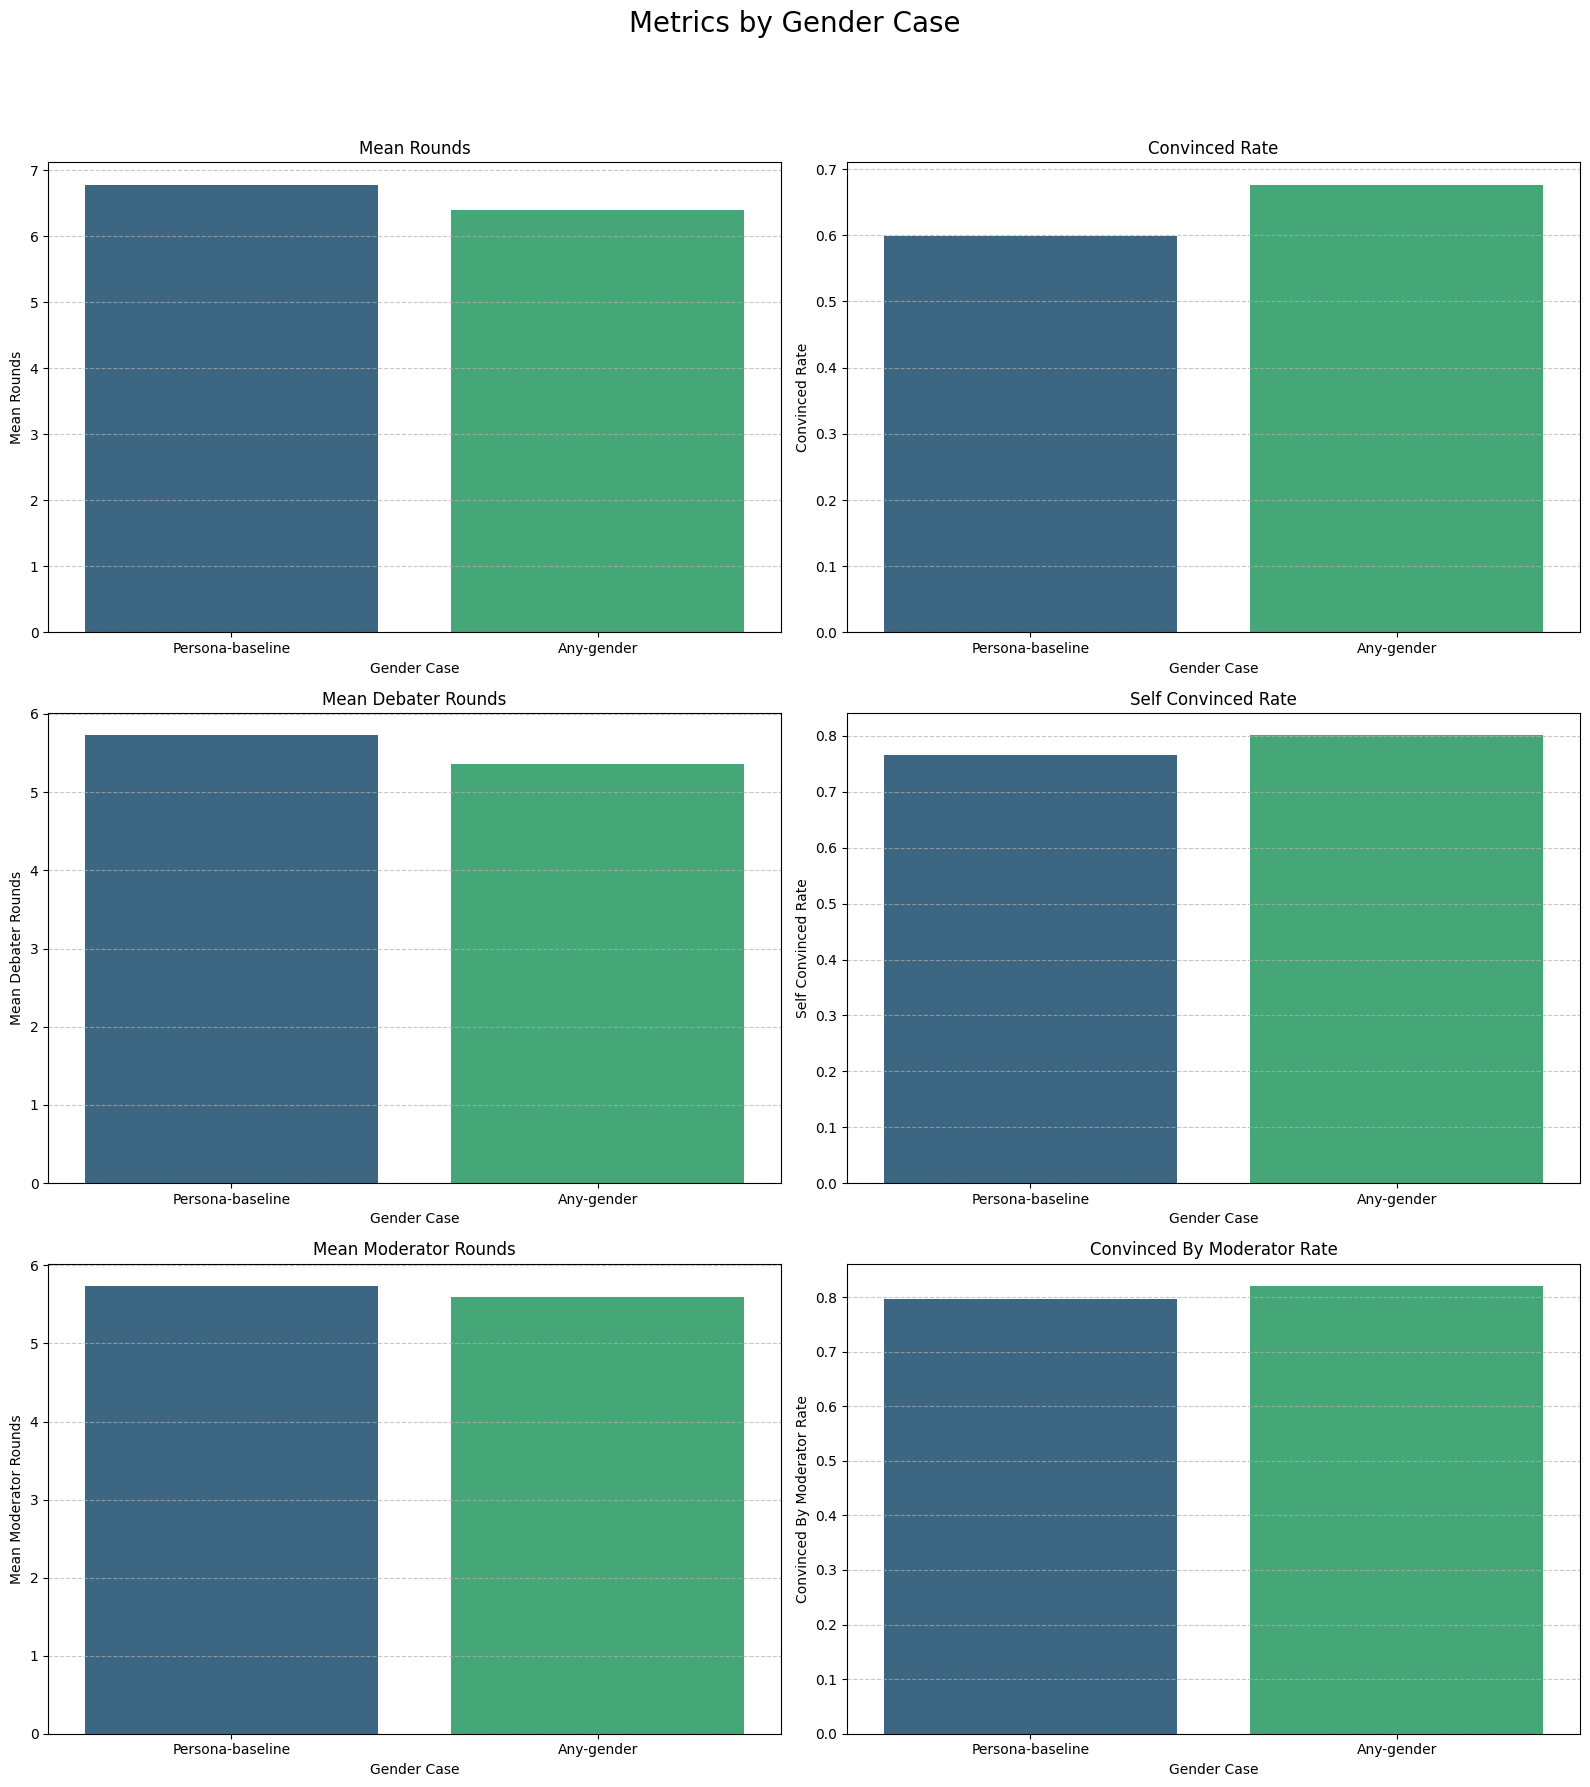

In [ ]:
plot_analysis_barplots(gender_analysis_df, metrics=['mean_rounds', 'convinced_rate', 'mean_debater_rounds','mean_moderator_rounds','median_rounds'], experiment_type='gender')
plot_analysis_barplots(gender_analysis_df.loc[[GENDER_BASELINE, 'Any-gender']], metrics=['mean_rounds', 'convinced_rate', 'mean_debater_rounds','self_convinced_rate','mean_moderator_rounds','convinced_by_moderator_rate'], experiment_type='gender')


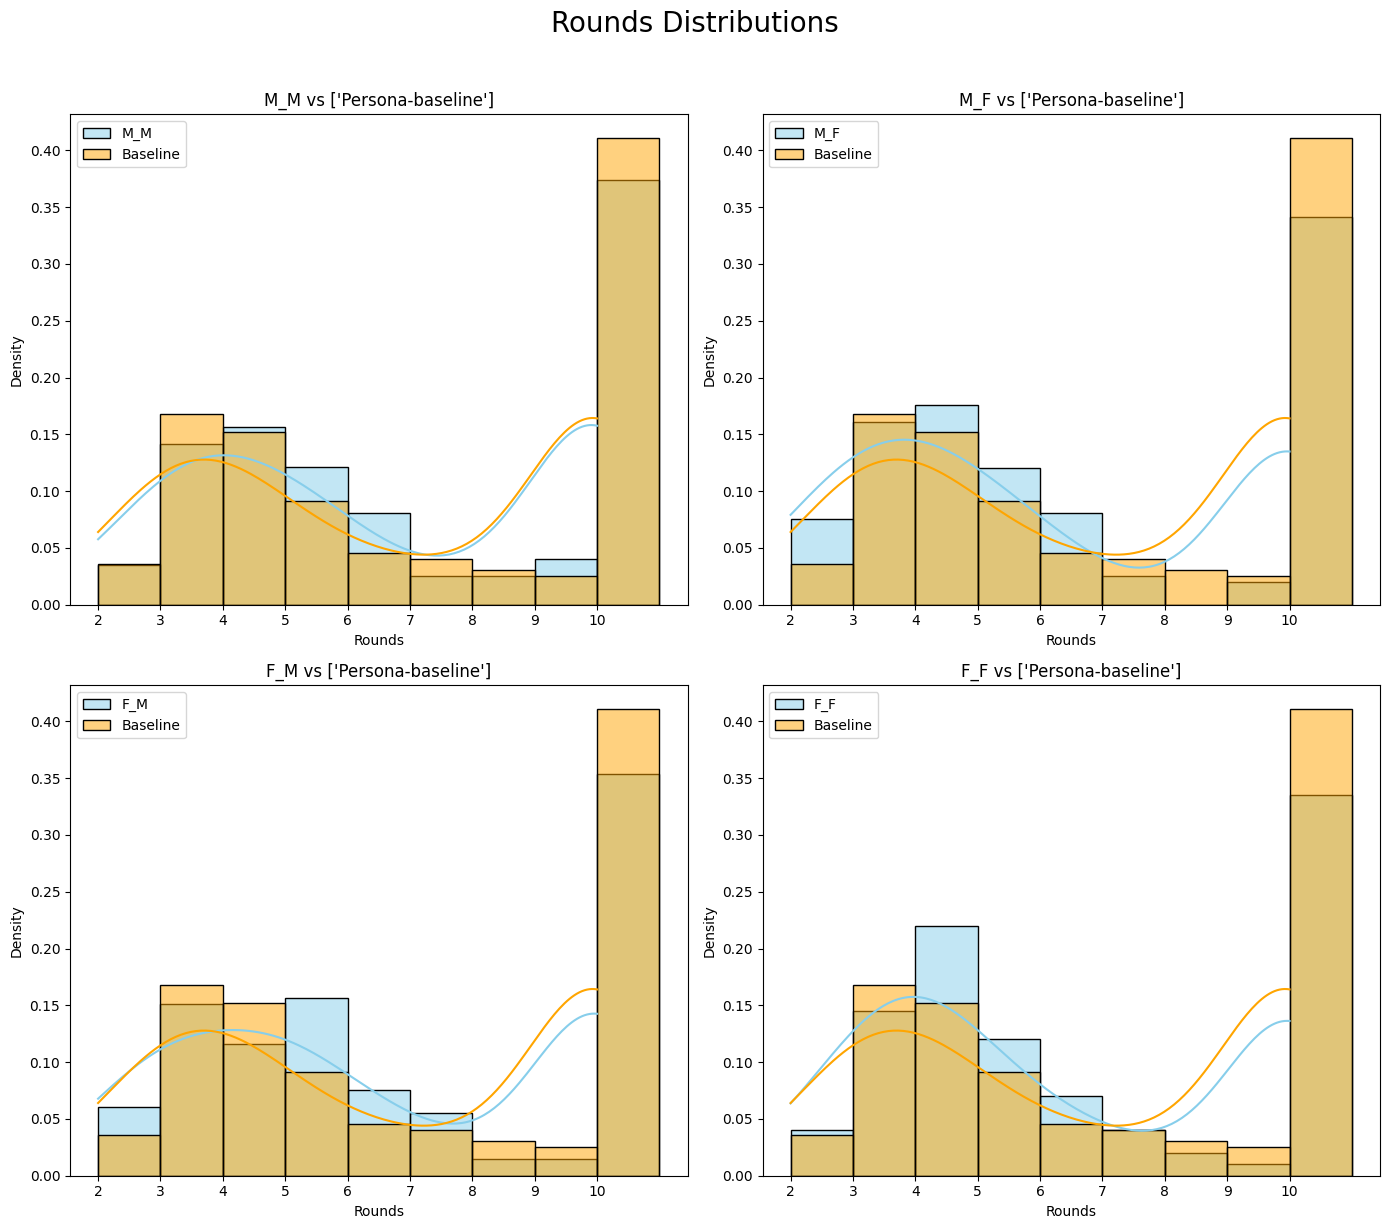

In [ ]:
plot_distribution(gender_debates_df[gender_debates_df["gender_case"] != EXPERT_BASELINE], 'rounds', 'gender', density=True)

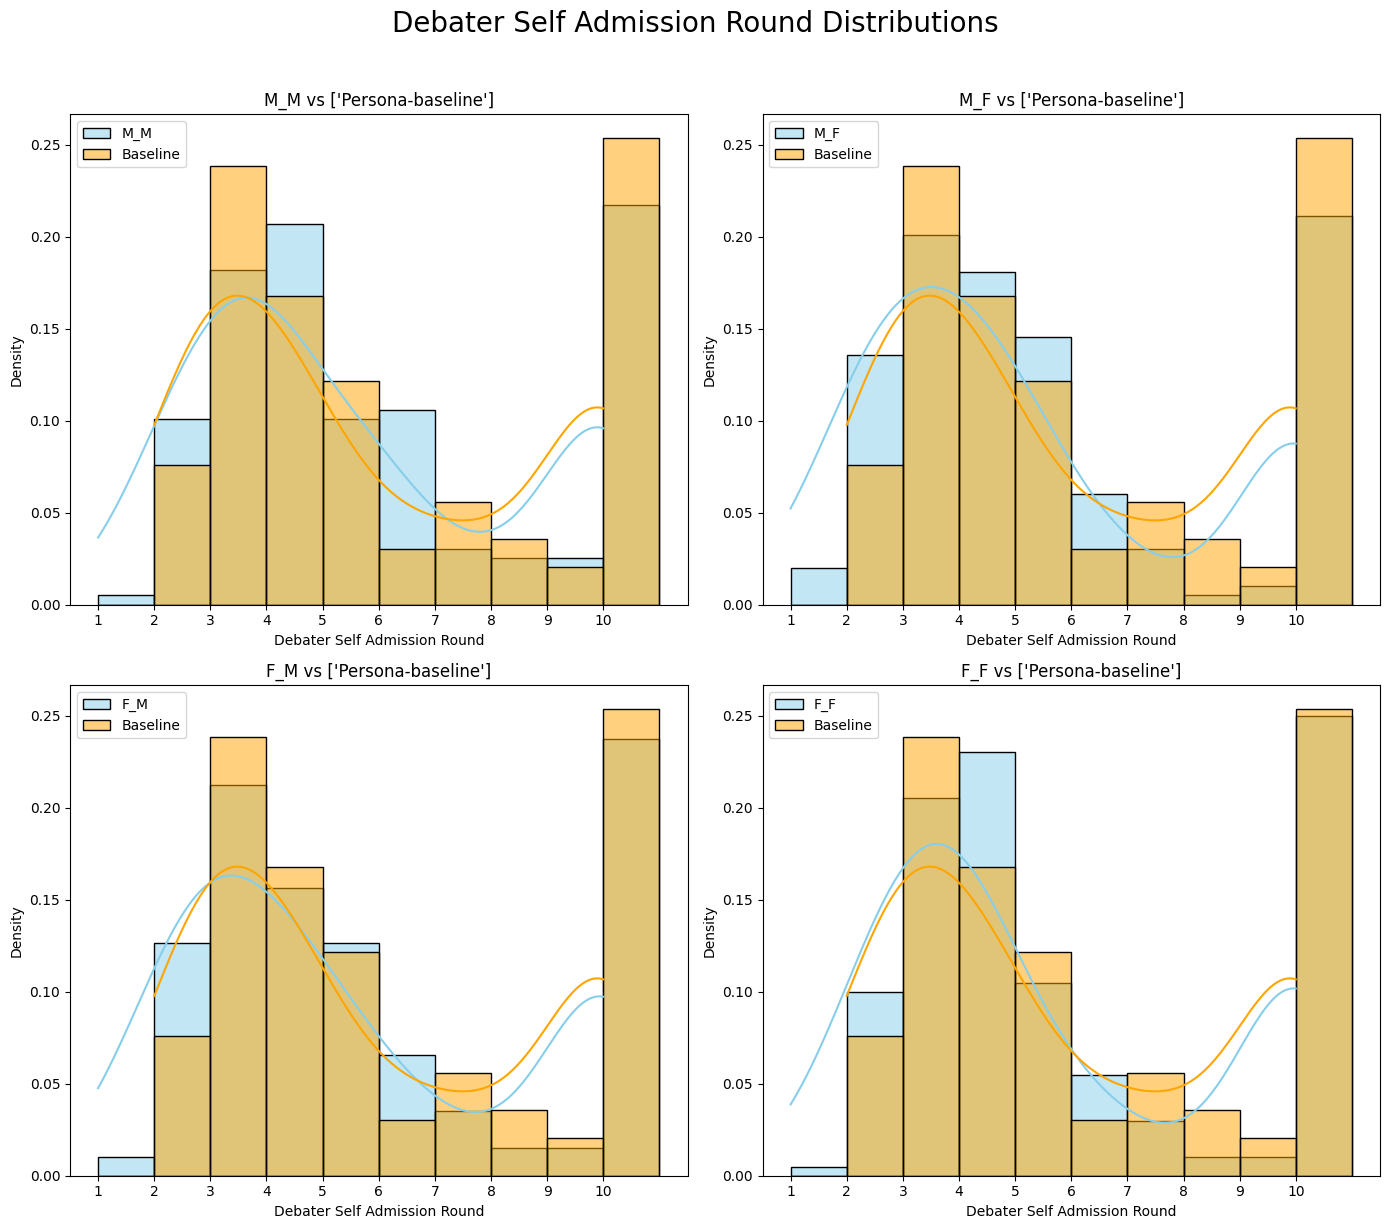

In [ ]:
plot_distribution(gender_debates_df[gender_debates_df["gender_case"] != EXPERT_BASELINE], 'debater_self_admission_round', 'gender', density=True)

In [ ]:
# Calculate p-values for 'convinced_rate' using Fisher's Exact Test
gender_analysis_df = add_binary_p_values(
    full_df=gender_debates_df,
    analysis_df=gender_analysis_df,
    experiment='gender',
    binary_column='result',
    alternative='greater',
    col_name='convinced_rate'
)

gender_analysis_df = add_binary_p_values(
    full_df=gender_debates_df,
    analysis_df=gender_analysis_df,
    experiment='gender',
    binary_column='self_convinced',
    alternative='greater',
    col_name='self_convinced_rate'
)

# Calculate p-values for 'mean_rounds' using Mann-Whitney U test
gender_analysis_df = add_continuous_p_values(
    full_df=gender_debates_df,
    analysis_df=gender_analysis_df,
    experiment='gender',
    metric_column='rounds',
    alternative='less',
    against_cases= [GENDER_BASELINE],
    col_name='rounds'
)

gender_analysis_df = add_continuous_p_values(
    full_df=gender_debates_df,
    analysis_df=gender_analysis_df,
    experiment='gender',
    metric_column='moderator_conviction_round',
    alternative='less',
    against_cases= [GENDER_BASELINE],
    col_name='moderator_rounds'
)

# Calculate p-values for 'mean_debator_rounds' using Mann-Whitney U test
gender_analysis_df = add_continuous_p_values(
    full_df=gender_debates_df,
    analysis_df=gender_analysis_df,
    experiment='gender',
    metric_column='debater_self_admission_round',
    alternative='less',
    against_cases= [GENDER_BASELINE],
    col_name='debater_rounds'
)
print("Gender analysis DataFrame with non-parametric p-values:")

Gender analysis DataFrame with non-parametric p-values:


### Sammury of Gender Analysis
TODO: ADD

## Test Gender-Domain Bias


Analyze the relationship between topic masculinity scores and debate metrics by:
1. Grouping the `merged_df` by `gender_case` and `masculine_score`.
2. Calculating for each group:
    - The `count` of debates.
    - The `convinced_rate` (proportion of debates where `result` is 1).
    - The `mean_rounds` (average number of rounds).
    - The `break_early_rate` (proportion of debates where `ground_truth_conviction_round` is 'break_early').
    - The `mean_round_num_diff` (average difference between `ground_truth_num` and `rounds`).
Store these aggregated metrics in a new DataFrame called `domain_analysis_df`.**bold text**

Merge the `debates_summery_df` with the `masculinity_scores_df` on `topic_id` (which corresponds to `claim_id` in the masculinity scores DataFrame) to combine debate details with topic masculinity scores.


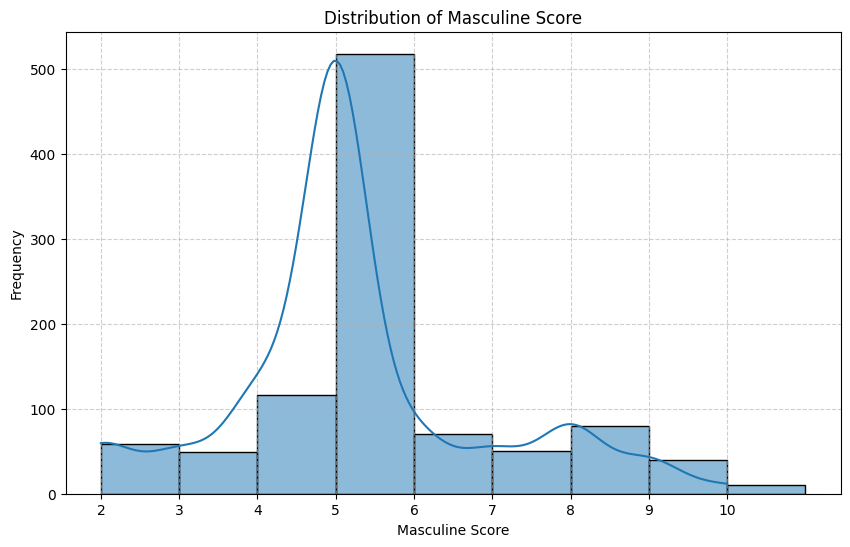

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(masculinity_scores_debates_df['masculine_score'], kde=True, bins=range(masculinity_scores_debates_df['masculine_score'].min(), masculinity_scores_debates_df['masculine_score'].max() + 2))
plt.title('Distribution of Masculine Score')
plt.xlabel('Masculine Score')
plt.ylabel('Frequency')
plt.xticks(range(masculinity_scores_debates_df['masculine_score'].min(), masculinity_scores_debates_df['masculine_score'].max() + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Group the merged DataFrame by `gender_case` and `masculine_score`. For each group, calculate the `count`, `convinced_rate`, `mean_rounds`, `break_early_rate`, and `mean_round_num_diff`. This will aggregate the debate metrics by gender and topic masculinity.


In [ ]:
domain_analysis_df = biuld_domain_analysis_df(masculinity_scores_debates_df)
print("Aggregated data by gender_case and masculine_score.")
domain_analysis_df.head()

Aggregated data by gender_case and masculine_score.


,gender_case,masculine_score,count,convinced_rate,mean_rounds,mean_debater_rounds,self_convinced_rate,mean_moderator_rounds,moderator_conviced_rate
0,F_F,2,12,0.750,5.500,4.583,0.833,5.000,0.917
1,F_F,3,10,0.600,6.600,5.300,0.700,4.900,0.900
2,F_F,4,24,0.667,6.125,5.375,0.833,5.000,0.833
3,F_F,5,104,0.663,6.394,5.779,0.760,5.385,0.827
4,F_F,6,14,0.714,5.929,4.214,0.857,5.286,0.857


#### Calculate Correlations

For each gender_case, calculate the Pearson correlation coefficient between the masculine_score and each of the aggregated metrics: convinced_rate, mean_rounds, break_early_rate, and mean_round_num_diff. Print these correlation values.


In [ ]:
corr_df= corr_by_case(domain_analysis_df)

In [ ]:
corr_df.pivot_table(
    index="gender_case",
    columns="metric",
    values="weighted_pearson",
    aggfunc="first"
).reset_index()



metric,gender_case,convinced_rate,mean_debater_rounds,mean_rounds,self_convinced_rate
0,F_F,-0.216,0.225,0.451,-0.478
1,F_M,0.382,-0.161,-0.467,0.206
2,M_F,0.656,-0.561,-0.643,0.433
3,M_M,0.307,-0.159,0.002,0.394
4,Persona-baseline,0.213,-0.504,-0.230,0.420


In [ ]:
#raw_correlations_by_gender(masculinity_scores_debates_df, metrics=['result', 'rounds', 'debater_self_admission_round', 'moderator_conviction_round'])

In [ ]:
correlations_by_gender(domain_analysis_df)

Weighted Pearson Correlation Coefficients by Gender Case and Metric:

Gender Case: F_F
  convinced_rate: -0.523
  mean_rounds: 0.612
  mean_debater_rounds: 0.618
  mean_moderator_rounds: 0.487

Gender Case: F_M
  convinced_rate: 0.130
  mean_rounds: -0.454
  mean_debater_rounds: -0.460
  mean_moderator_rounds: -0.174

Gender Case: M_F
  convinced_rate: 0.801
  mean_rounds: -0.812
  mean_debater_rounds: -0.745
  mean_moderator_rounds: -0.533

Gender Case: M_M
  convinced_rate: 0.473
  mean_rounds: -0.147
  mean_debater_rounds: -0.471
  mean_moderator_rounds: 0.185

Gender Case: Persona-baseline
  convinced_rate: 0.396
  mean_rounds: -0.466
  mean_debater_rounds: -0.675
  mean_moderator_rounds: -0.443


In [ ]:
#raw_ols_p_values_by_gender(masculinity_scores_debates_df, metrics=['result', 'rounds', 'debater_self_admission_round', 'moderator_conviction_round'])

In [ ]:
#ols_p_values_by_gender(domain_analysis_df)

#### Visualize Relationships

Create scatter plots to visualize the relationship between `masculine_score` and each of the aggregated metrics (`convinced_rate`, `mean_rounds`, `break_early_rate`, and `mean_round_num_diff`) for each `gender_case`. Each plot should have appropriate labels, titles, and legends to clearly represent the data.



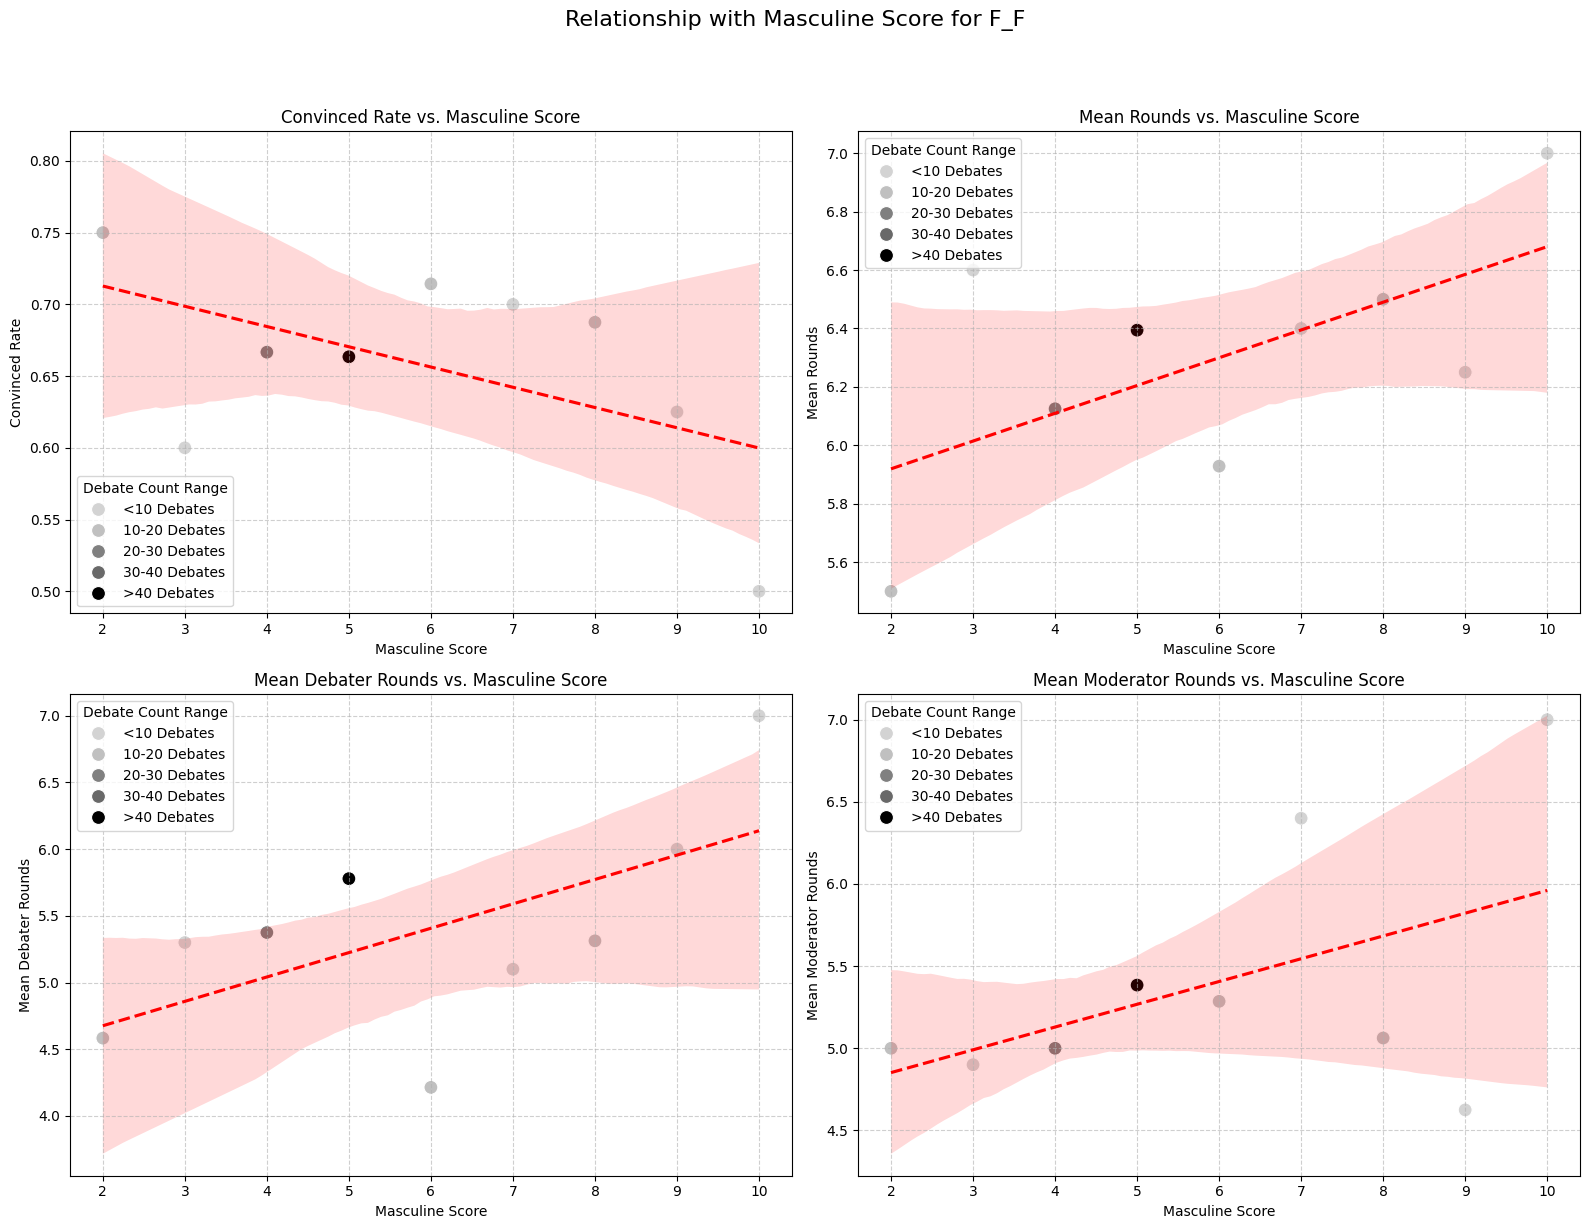

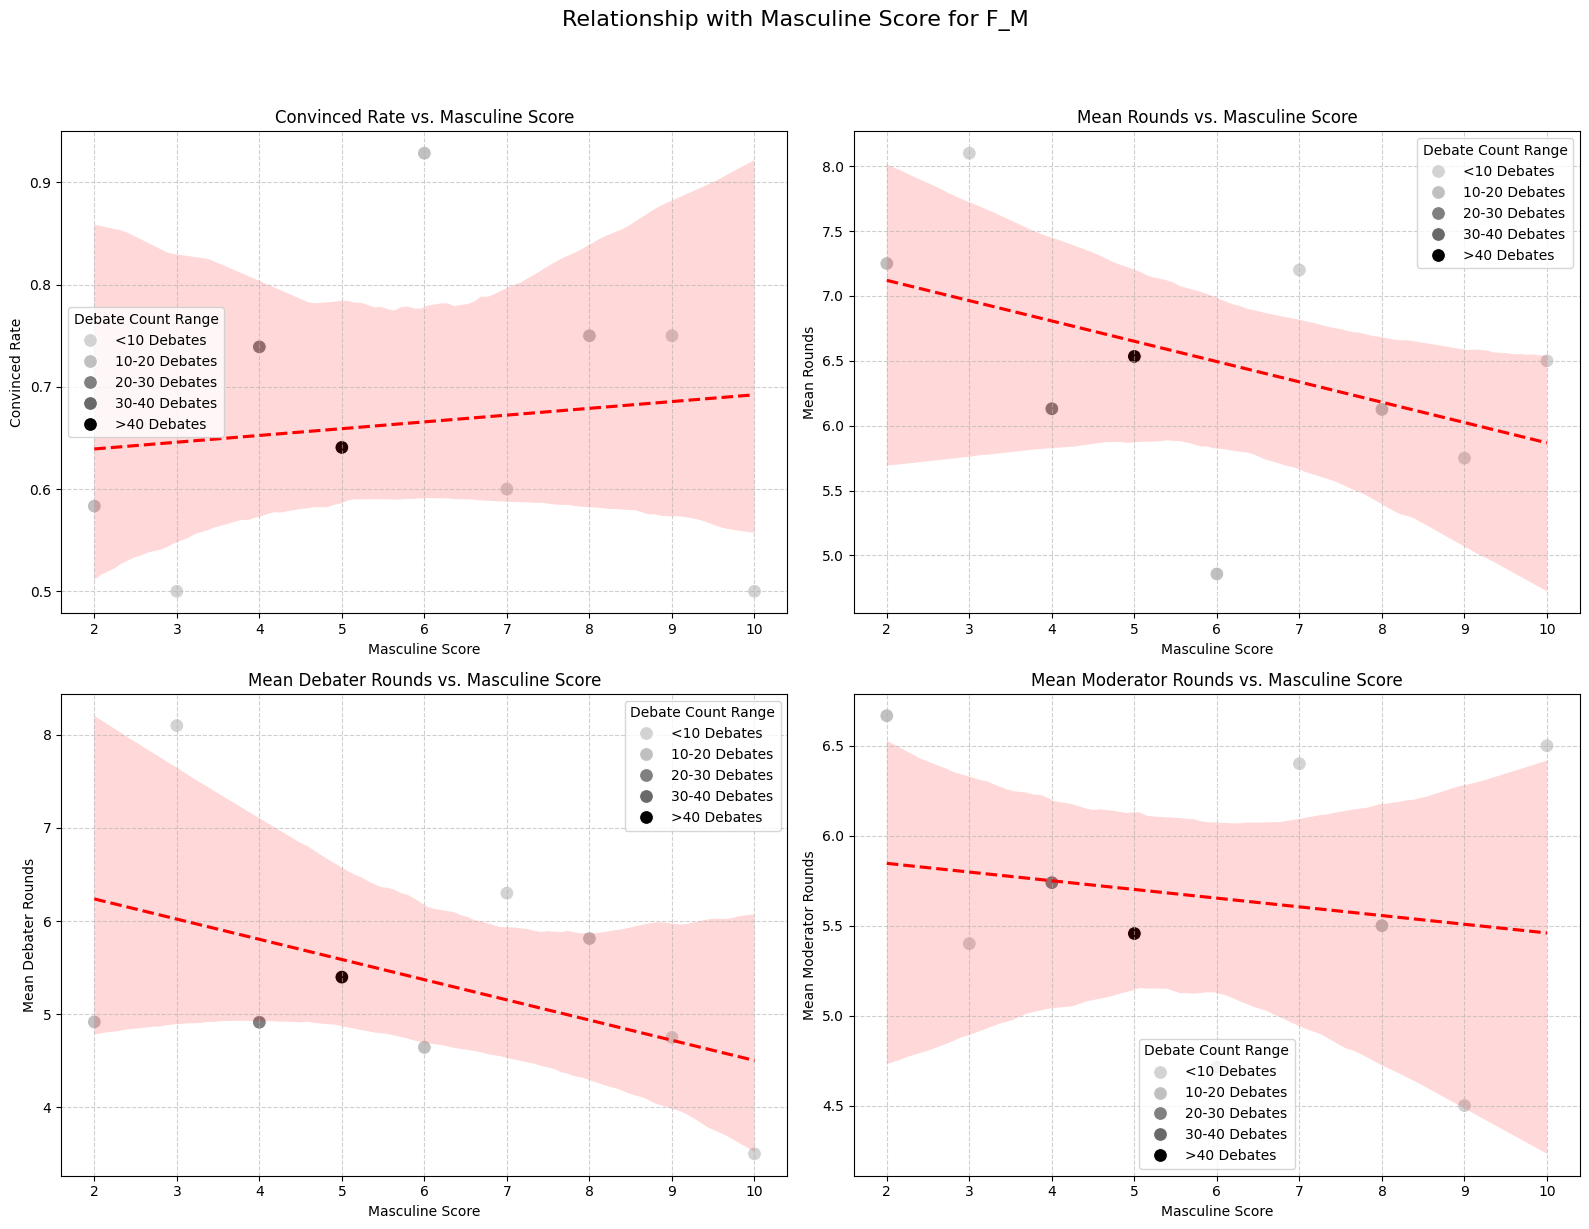

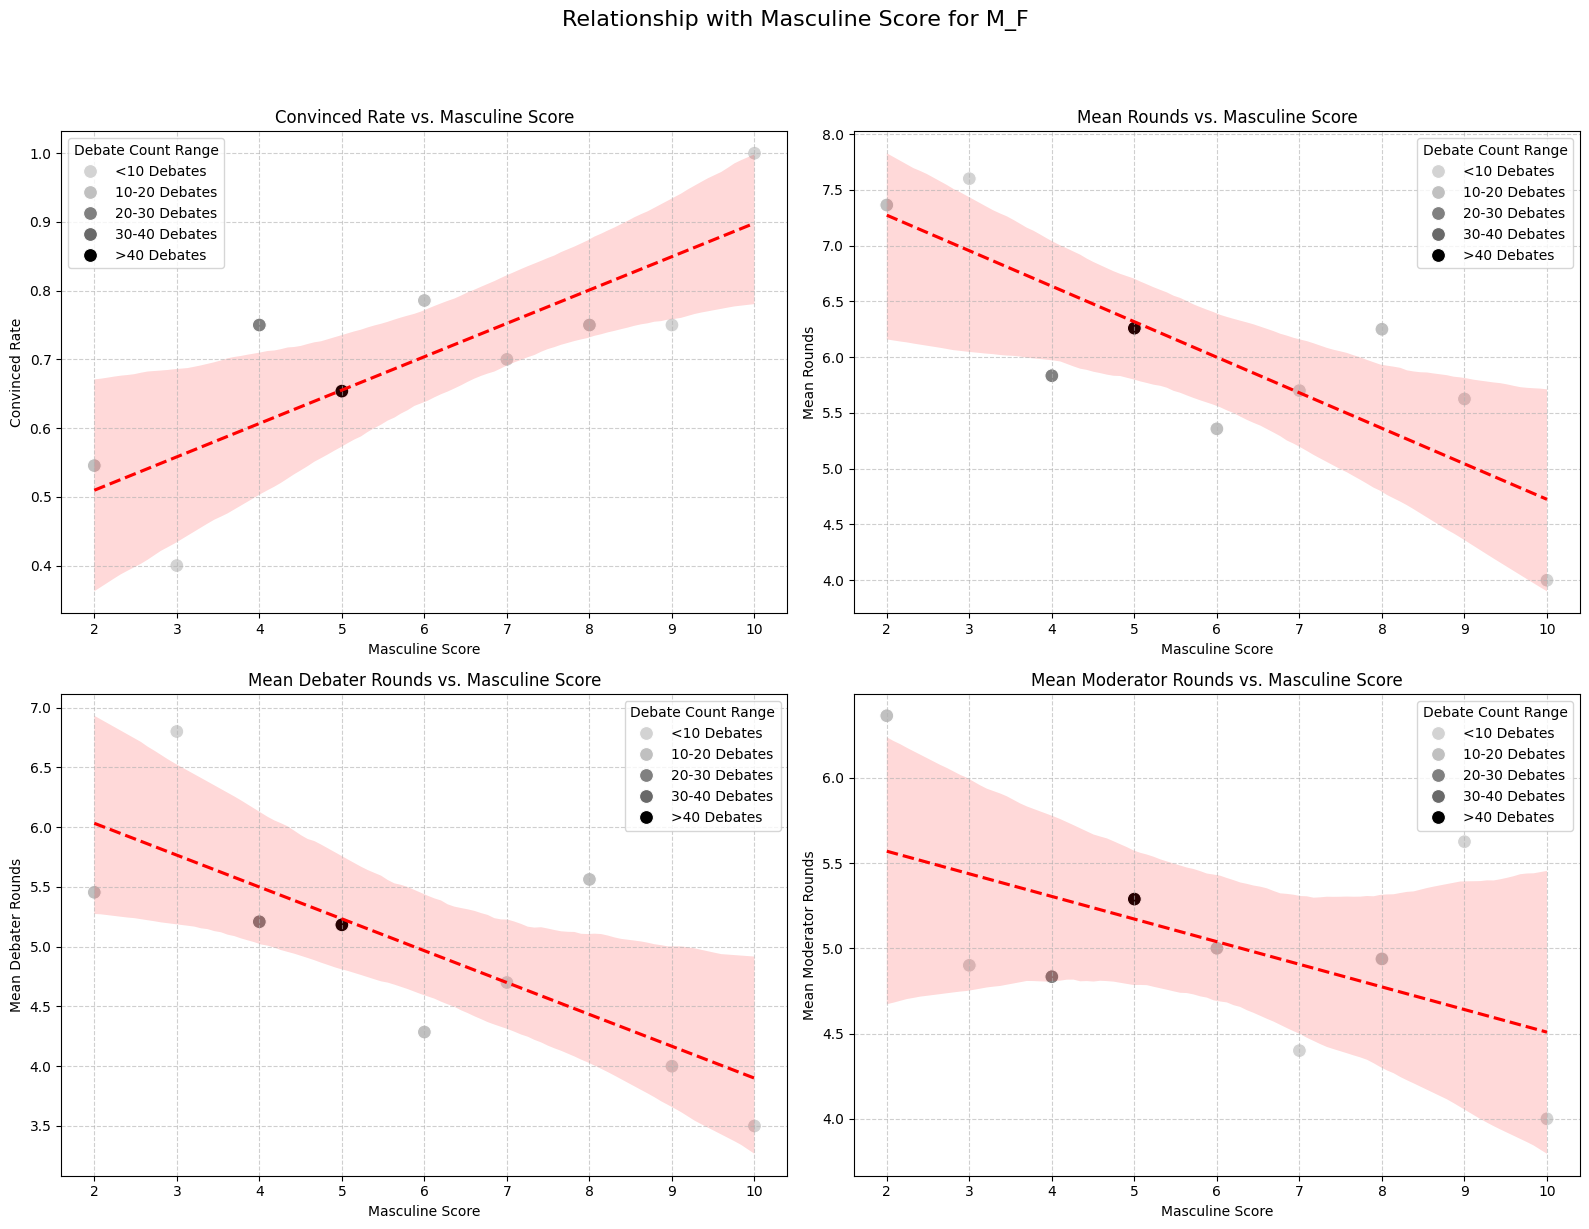

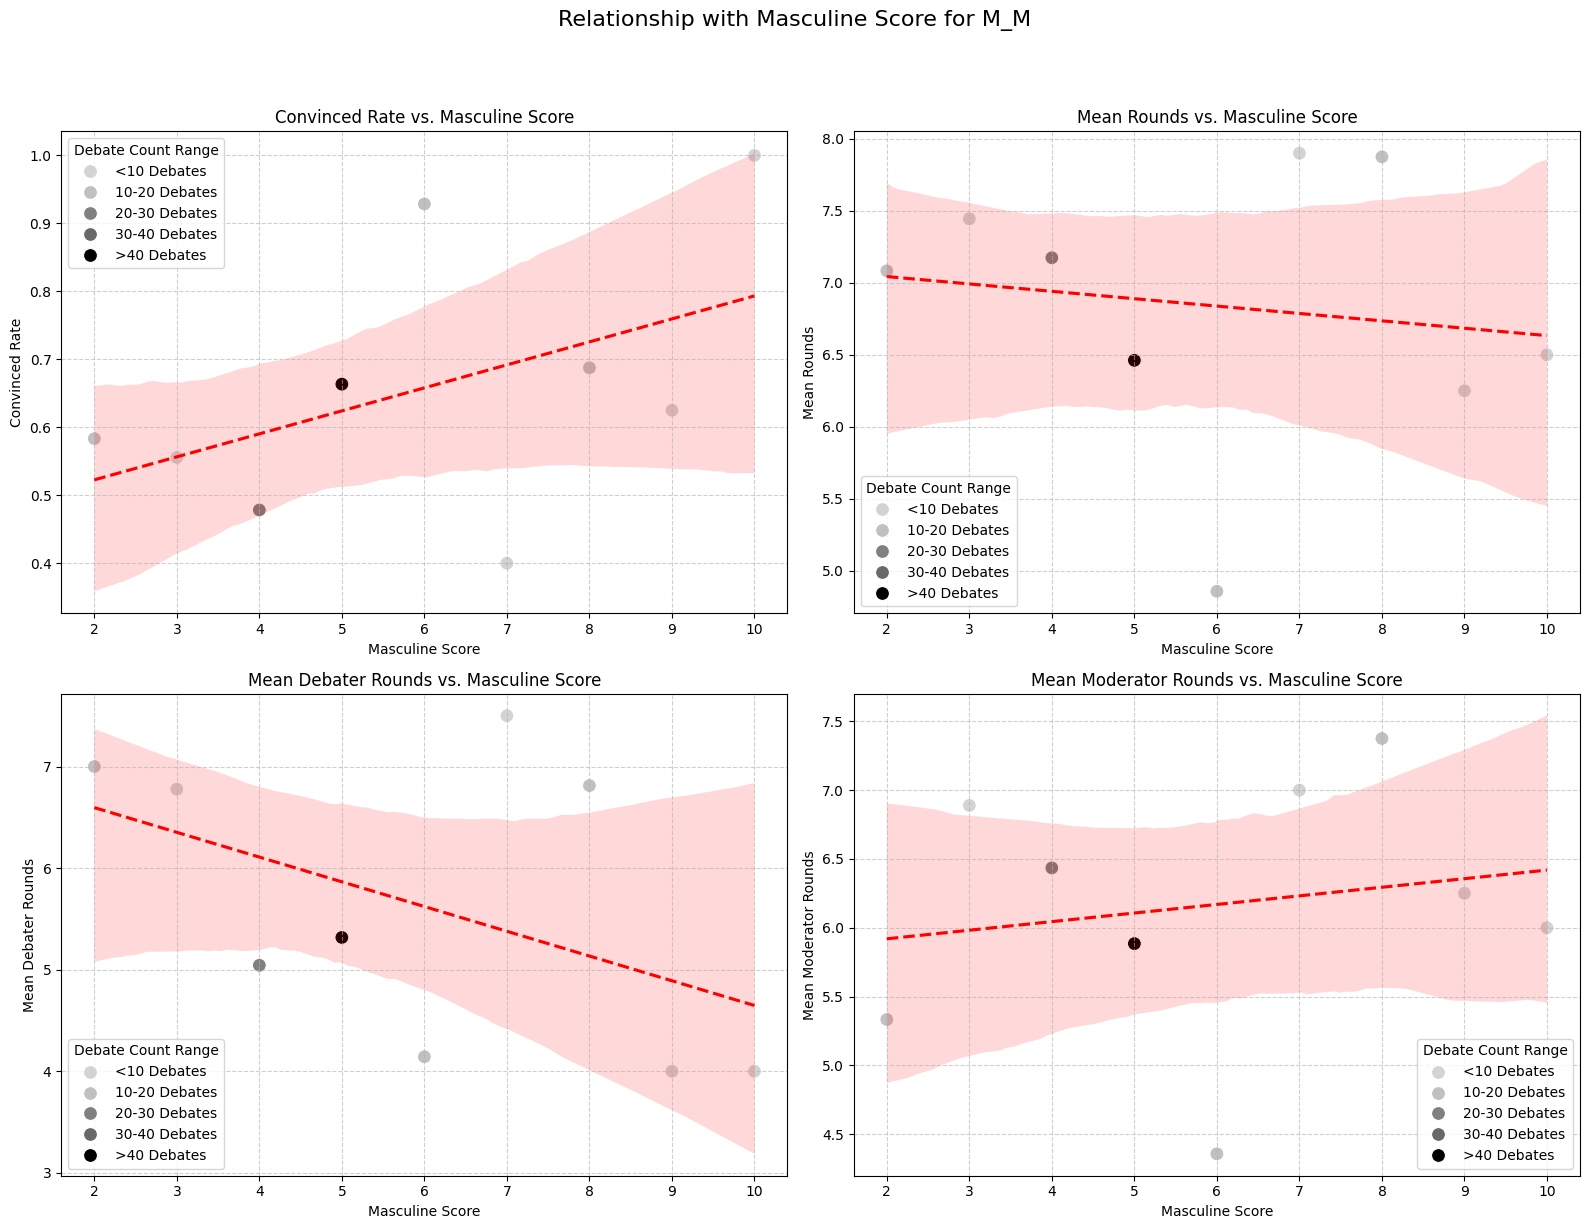

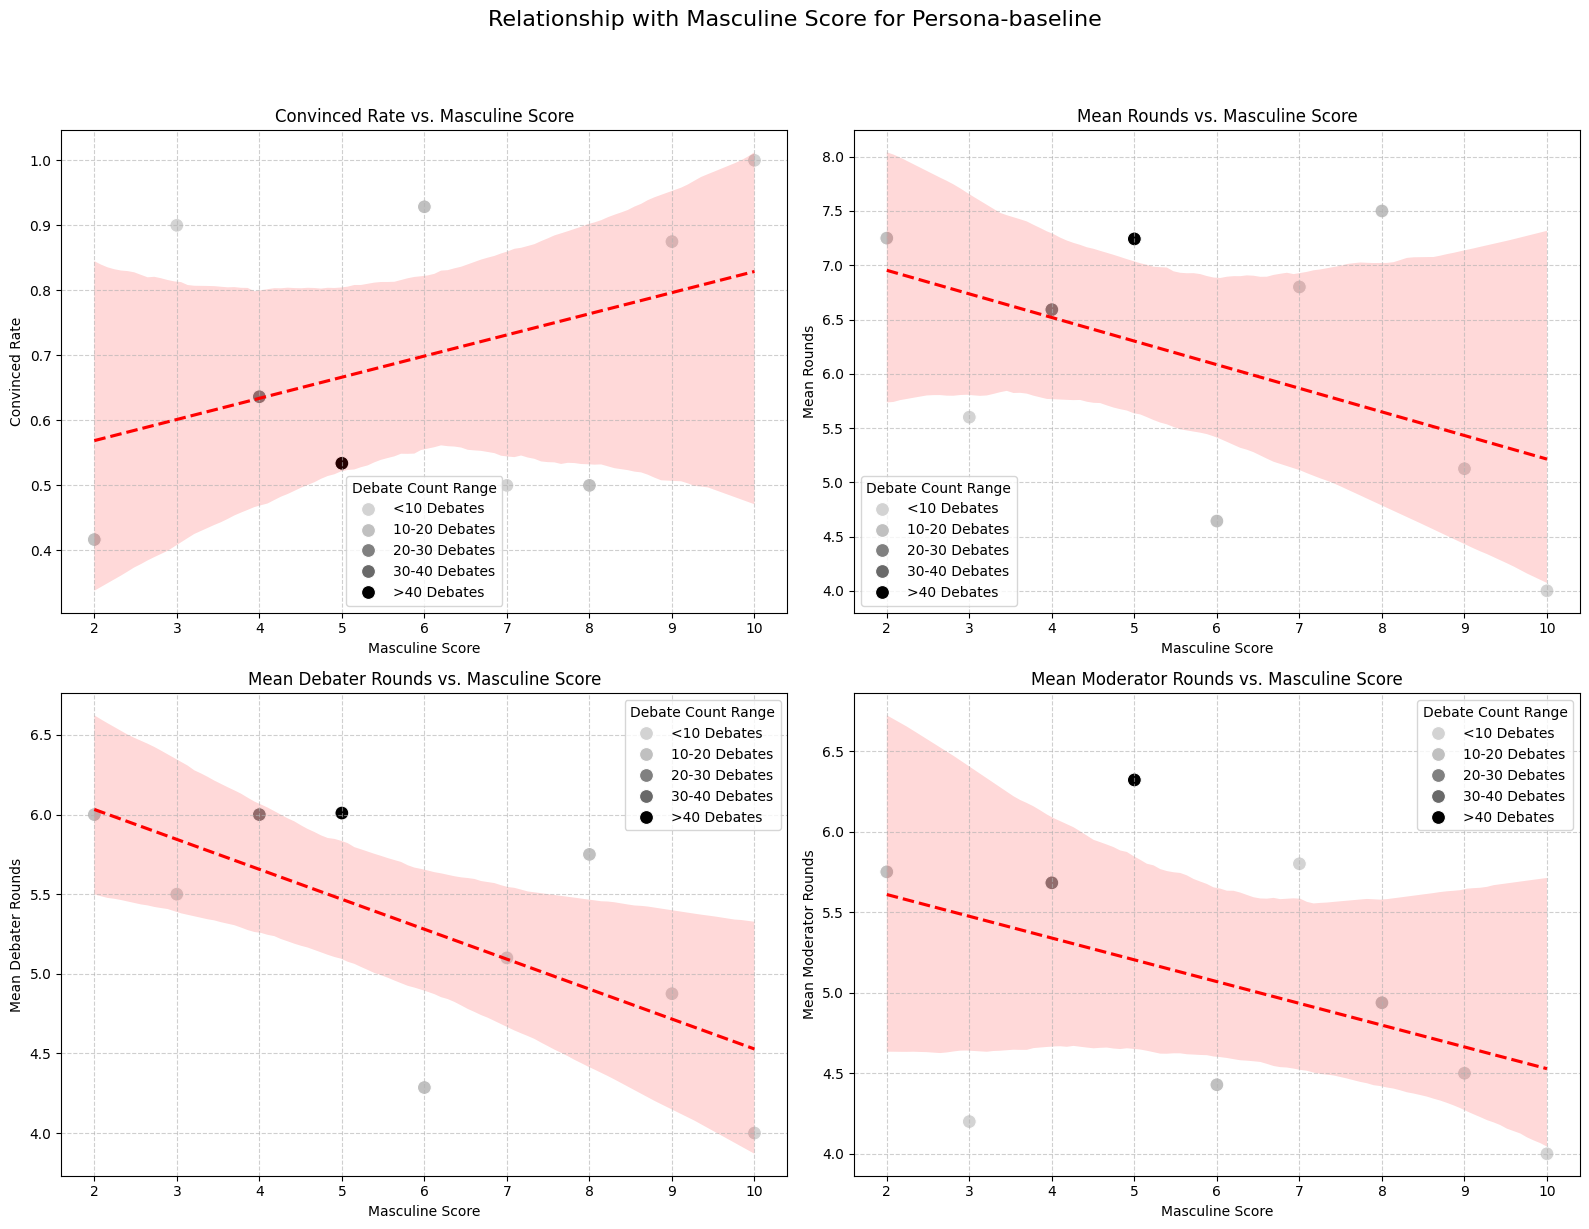

In [ ]:
plot_relationship_by_gender(domain_analysis_df)

### Summary of Specific Domain Bias Analysis
### TODO!


## Categorize Masculinity Scores

Create a new categorical column named `masculinity_category` in the `merged_df` DataFrame based on the `masculine_score` ranges specified by the user: 'Feminine' (scores 1-4), 'Natural' (scores 5-6), and 'Masculine' (scores 7-10).


In [ ]:
bins = [0, 4, 6, 10]
labels = ['Feminine', 'Natural', 'Masculine']

masculinity_scores_debates_df['masculinity_category'] = pd.cut(masculinity_scores_debates_df['masculine_score'], bins=bins, labels=labels, right=True)

print("Value counts for 'masculinity_category':")
print(masculinity_scores_debates_df['masculinity_category'].value_counts())

category_summary = masculinity_scores_debates_df.groupby('masculinity_category', observed=False).agg(
    total_debates=('topic_id', 'size'),
    sample_domains=('domain', lambda x: x.dropna().unique().tolist()[:3])
).reset_index()

print("Aggregated summary by masculinity category:")
category_summary.head()

plt.figure(figsize=(10, 6))
sns.barplot(x='masculinity_category', y='total_debates', data=category_summary, palette='viridis', hue='masculinity_category', legend=False)

plt.title('Distribution of Debates by Masculinity Category')
plt.xlabel('Masculinity Category')
plt.ylabel('Total Debates')

# Add annotations for total debates and sample domains
for index, row in category_summary.iterrows():
    plt.text(index, row['total_debates'], f"{row['total_debates']}", color='black', ha="center", va='bottom')
    domains_text = '\n'.join(row['sample_domains'])
    plt.text(index, row['total_debates'] * 0.95, domains_text, color='white', ha="center", va='top', fontsize=11, bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Value counts for 'masculinity_category':
masculinity_category
Natural      588
Feminine     224
Masculine    180
Name: count, dtype: int64


### Aggregate Counts and Sample Domains

Group the `merged_df` by the `masculinity_category` to get the total count of debates in each category. Additionally, for each `masculinity_category`, collect up to three unique `domain` examples to be displayed on the bar plot.


In [ ]:
category_summary = masculinity_scores_debates_df.groupby('masculinity_category', observed=False).agg(
    total_debates=('topic_id', 'size'),
    sample_domains=('domain', lambda x: x.dropna().unique().tolist()[:3])
).reset_index()

print("Aggregated summary by masculinity category:")
category_summary

Aggregated summary by masculinity category:


,masculinity_category,total_debates,sample_domains
0,Feminine,224,"[Higher Education, Youth and Adulthood Transit..."
1,Natural,588,"[Energy Policy, Food and Nutrition, Legal System]"
2,Masculine,180,"[British Monarchy, International Relations, La..."


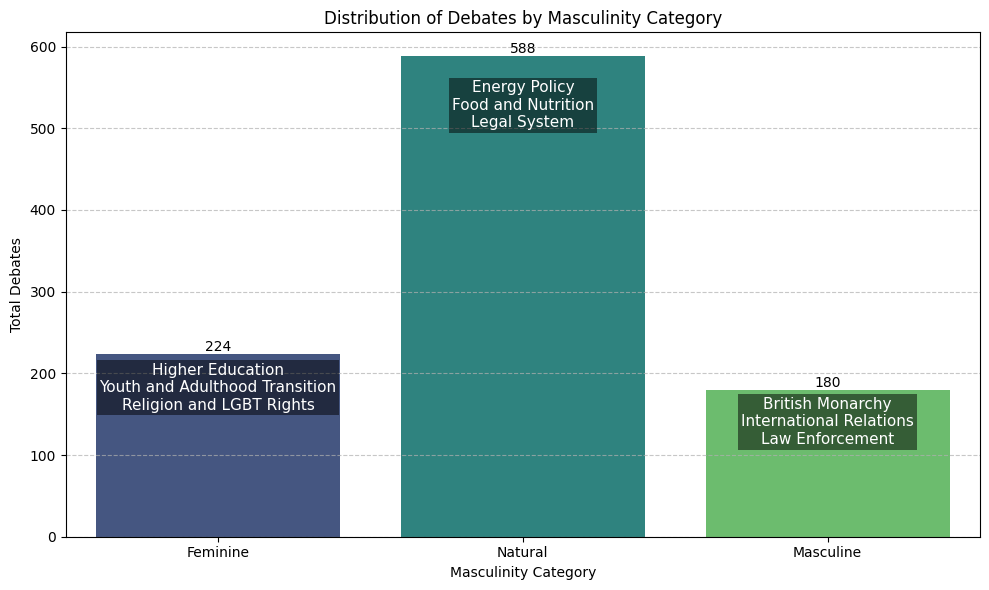

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='masculinity_category', y='total_debates', data=category_summary, palette='viridis', hue='masculinity_category', legend=False)

plt.title('Distribution of Debates by Masculinity Category')
plt.xlabel('Masculinity Category')
plt.ylabel('Total Debates')

# Add annotations for total debates and sample domains
for index, row in category_summary.iterrows():
    plt.text(index, row['total_debates'], f"{row['total_debates']}", color='black', ha="center", va='bottom')
    domains_text = '\n'.join(row['sample_domains'])
    plt.text(index, row['total_debates'] * 0.95, domains_text, color='white', ha="center", va='top', fontsize=11, bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Aggregate Metrics by Gender Case and Masculinity Category

Group the merged DataFrame by 'gender_case' and 'masculinity_category' to calculate the count, convinced_rate, mean_rounds, break_early_rate, and mean_round_num_diff for each group. Store the results in a new DataFrame called `category_analysis_df`.


In [ ]:
category_analysis_df = biuld_domain_analysis_df(masculinity_scores_debates_df, group_by = 'masculinity_category')
print("Aggregated data by gender_case and masculinity_category:")
category_analysis_df.head()

Aggregated data by gender_case and masculinity_category:


,gender_case,masculinity_category,count,convinced_rate,mean_rounds,mean_debater_rounds,self_convinced_rate,mean_moderator_rounds,moderator_conviced_rate
0,F_F,Feminine,46,0.674,6.065,5.152,0.804,4.978,0.870
1,F_F,Natural,118,0.669,6.339,5.593,0.771,5.373,0.831
2,F_F,Masculine,36,0.667,6.444,5.500,0.722,5.444,0.833
3,F_M,Feminine,45,0.644,6.867,5.622,0.756,5.911,0.800
4,F_M,Natural,117,0.675,6.333,5.308,0.803,5.368,0.838


### Visualize Metrics by Gender Case and Masculinity Category

Visualize how each debate metric (`convinced_rate`, `mean_rounds`, `break_early_rate`, `mean_round_num_diff`) varies across the `masculinity_category` for each `gender_case` using bar plots.


**Reasoning**:
To visualize how each debate metric varies across masculinity categories for each gender case, I will iterate through each unique gender case, create a subset DataFrame, and then generate bar plots for each metric within a multi-subplot figure, ensuring proper labeling and titles for clarity.



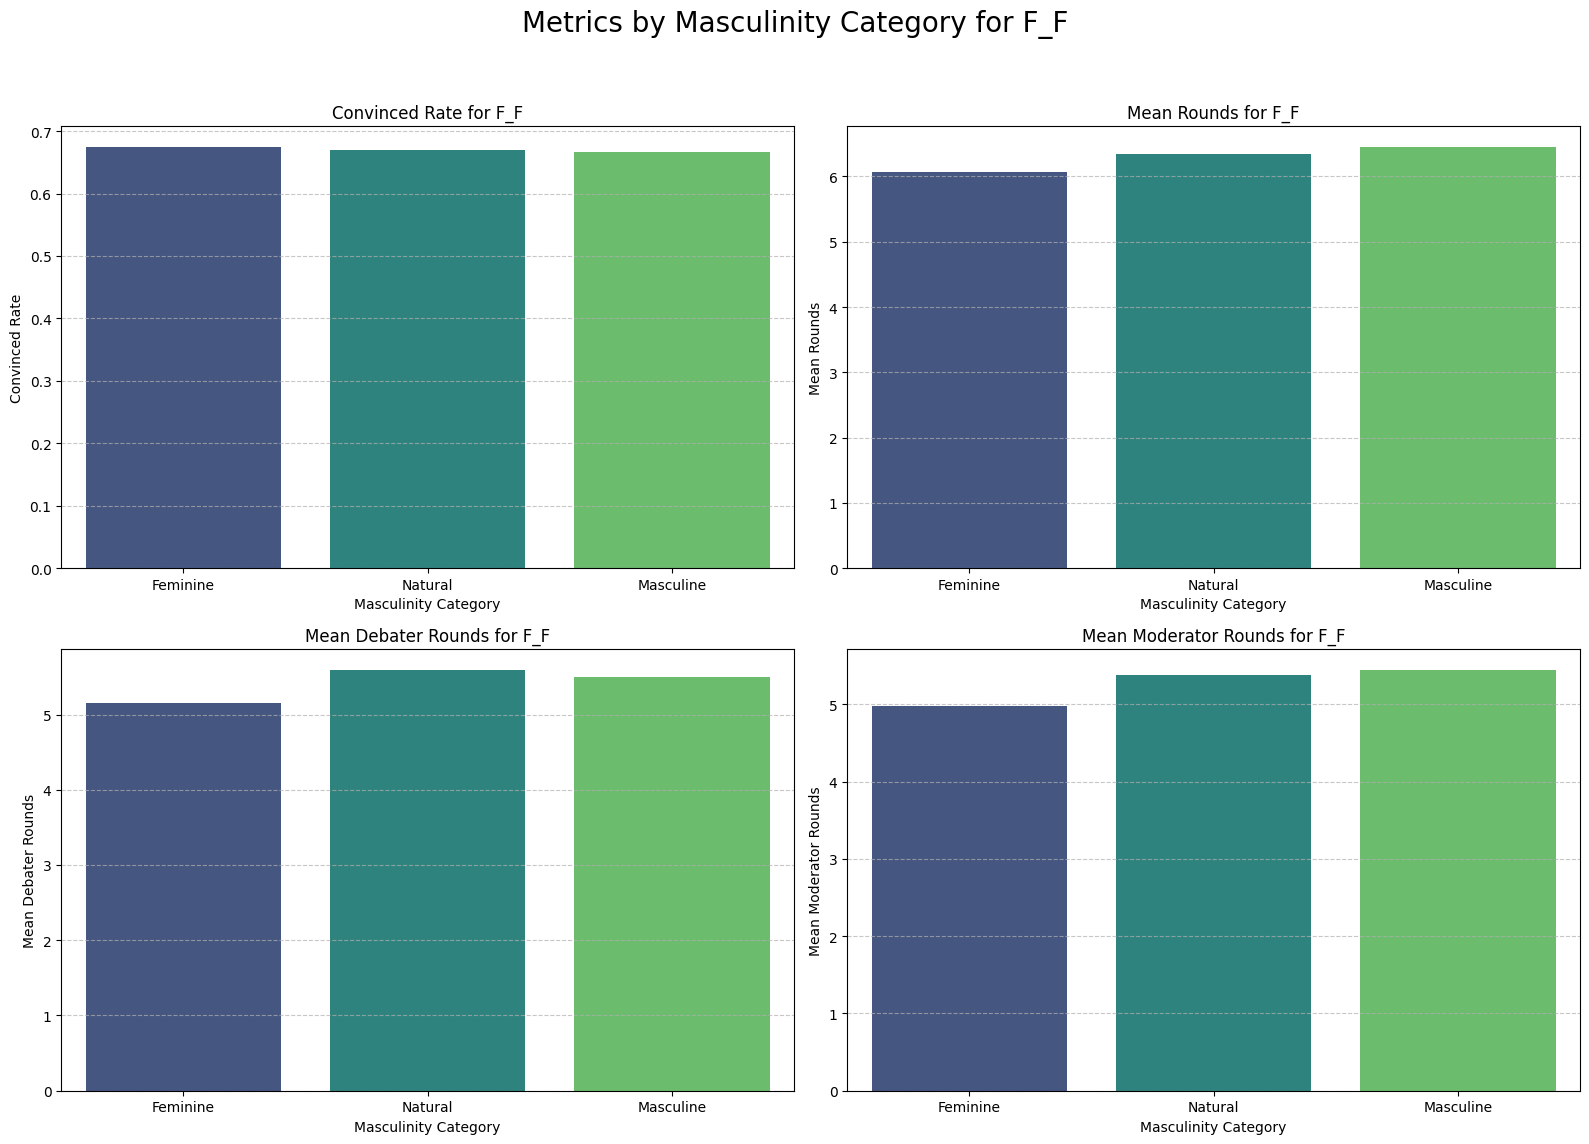

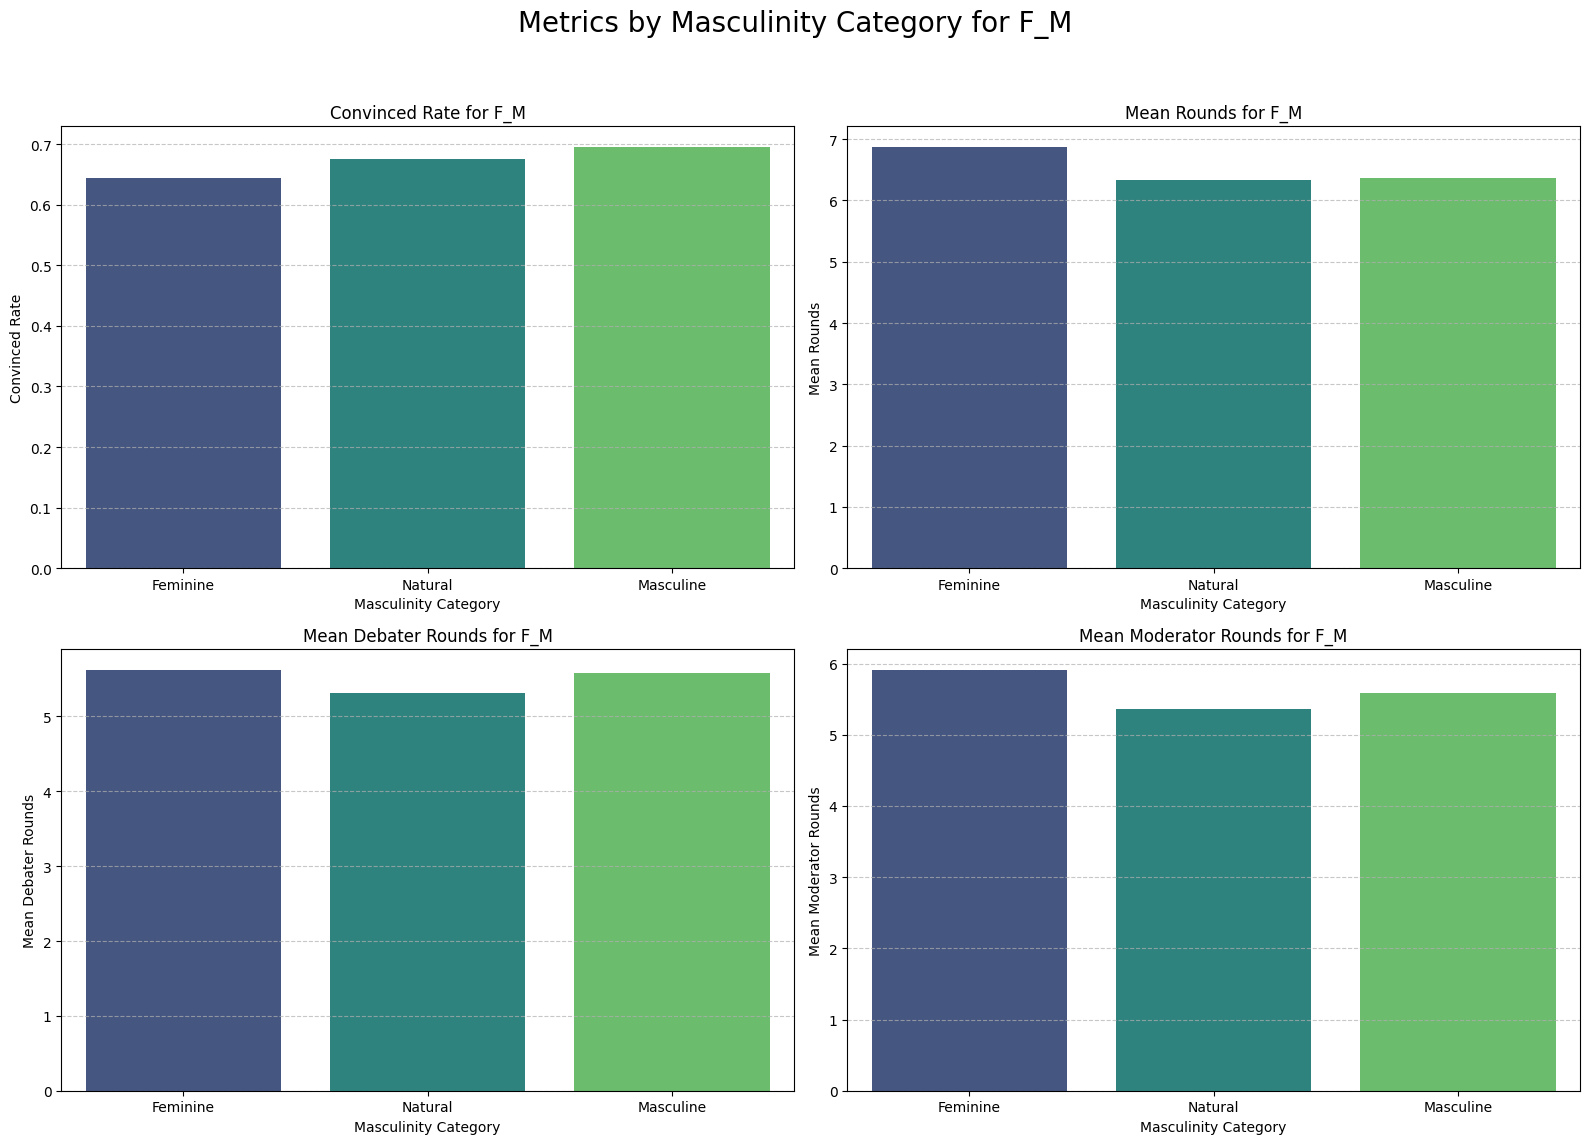

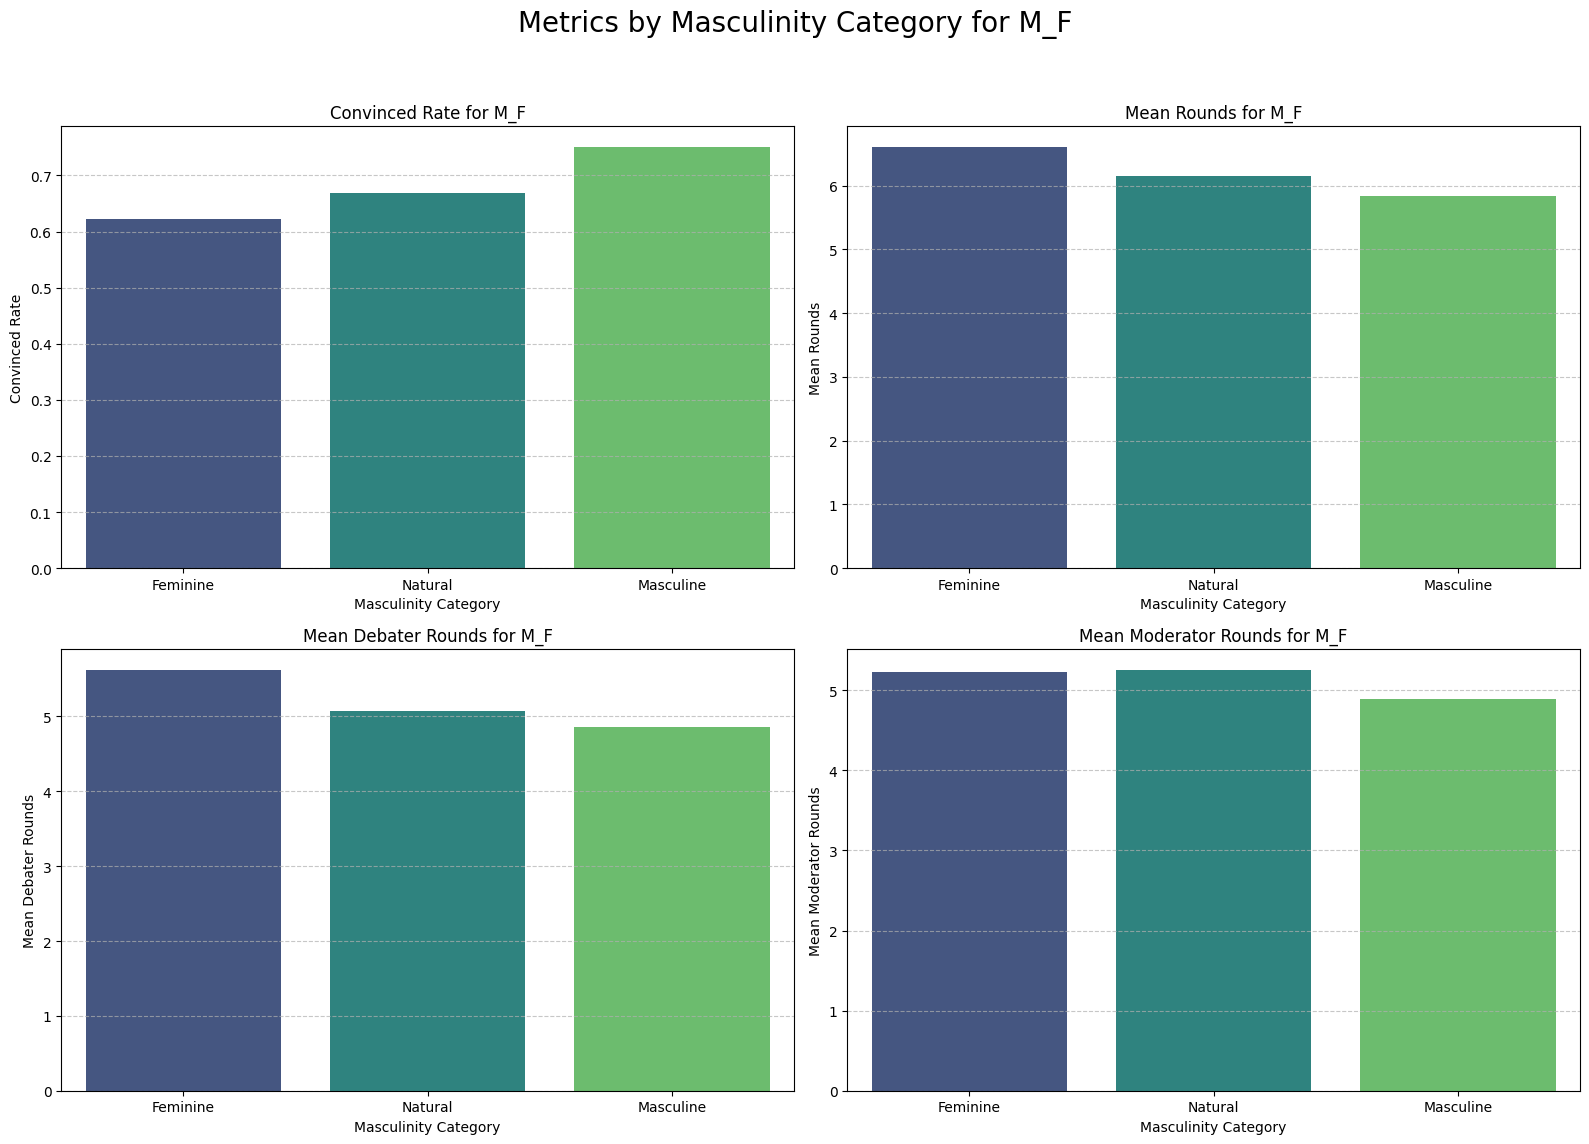

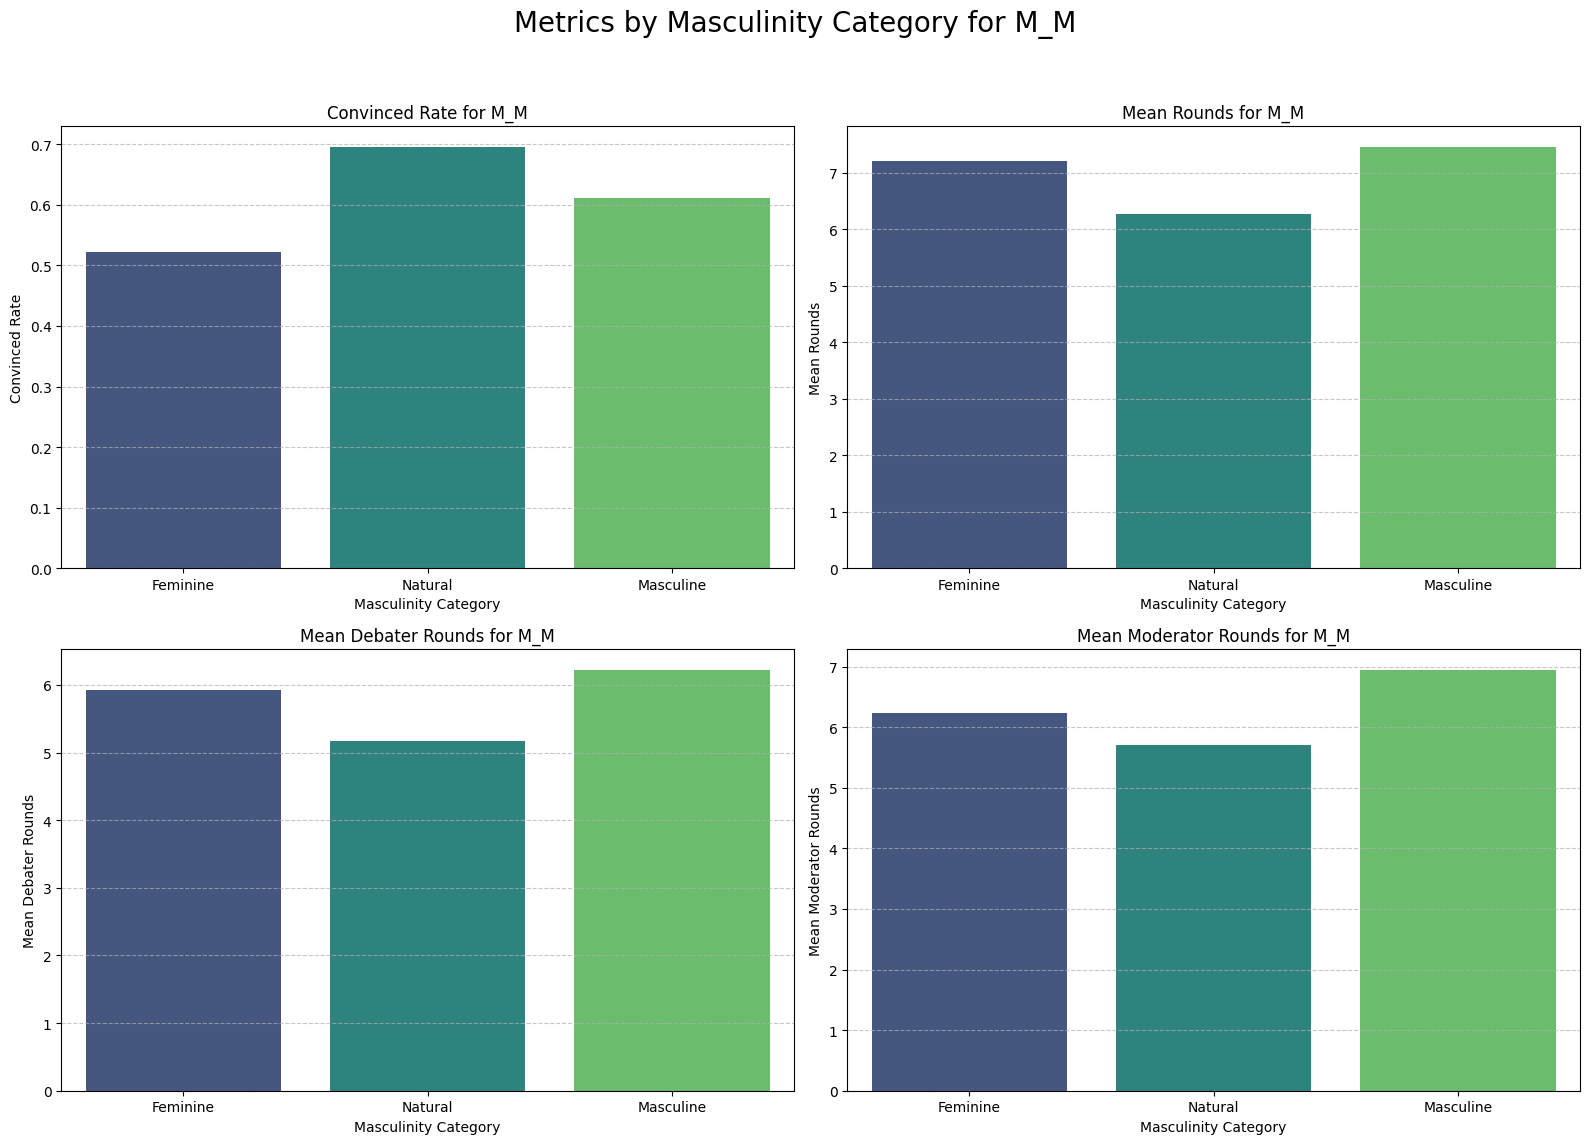

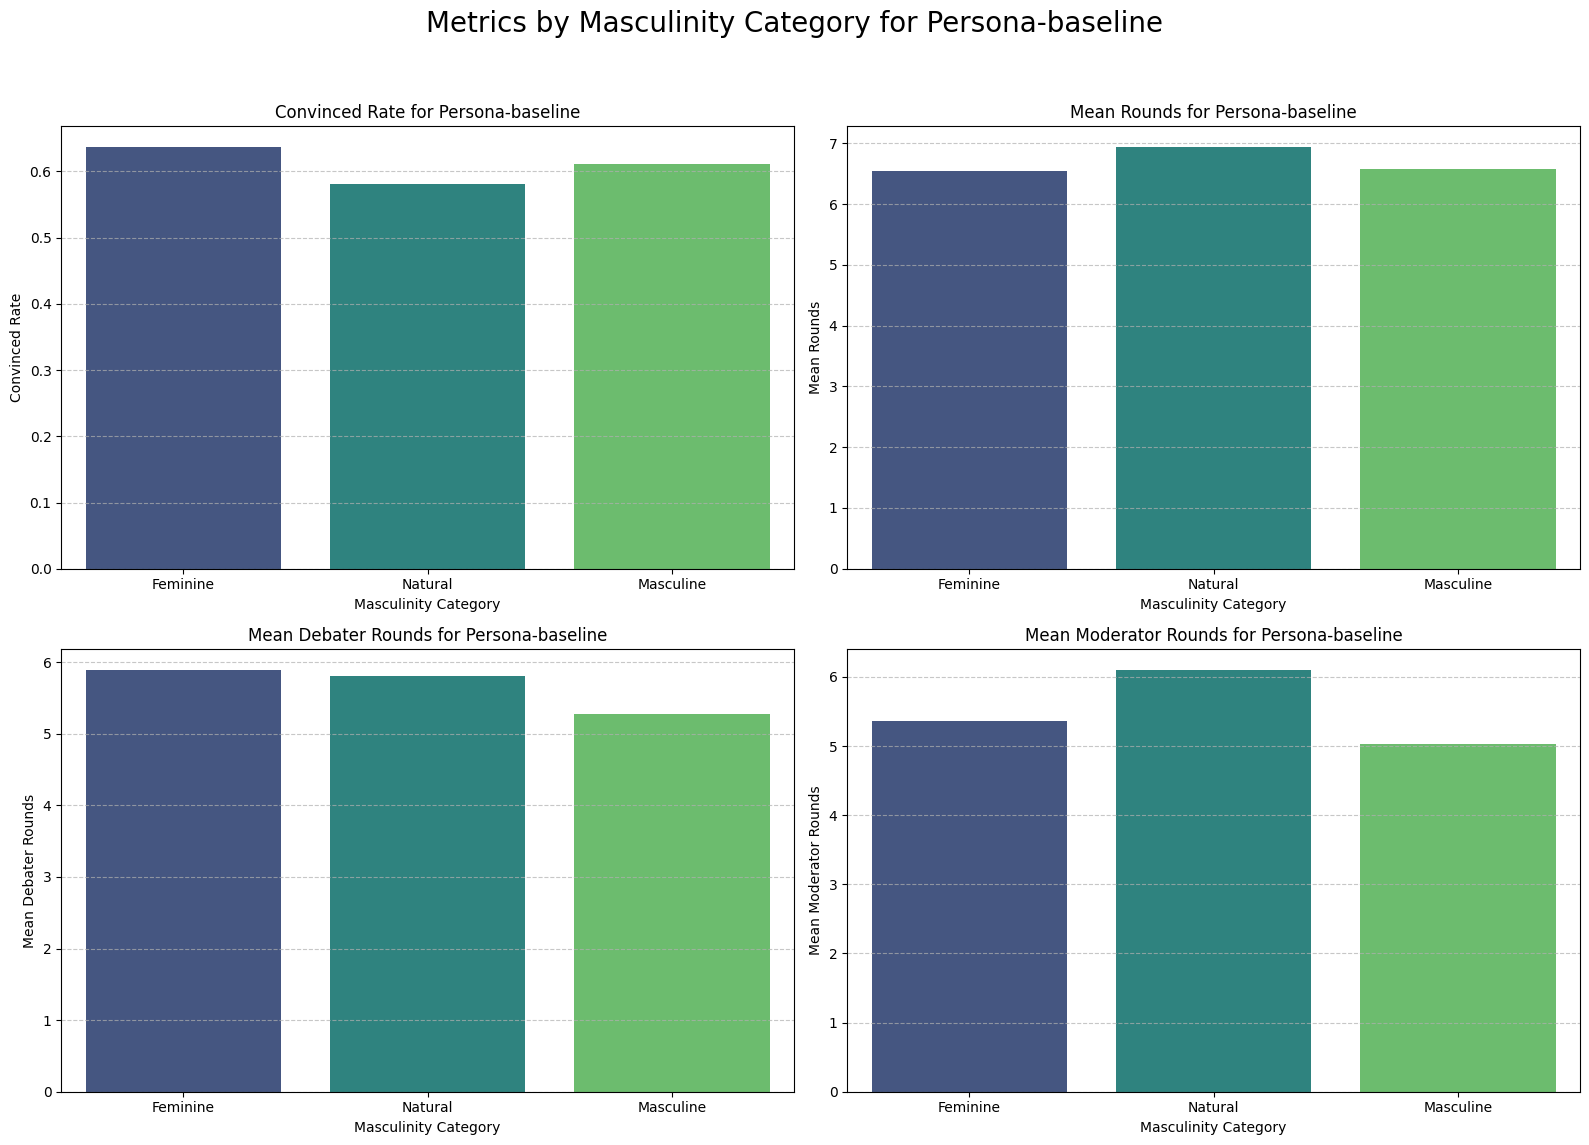

In [ ]:
unique_gender_cases = category_analysis_df['gender_case'].unique()
metrics_to_plot = ['convinced_rate', 'mean_rounds', 'mean_debater_rounds', 'mean_moderator_rounds']

for case in unique_gender_cases:
    gender_case_df = category_analysis_df[category_analysis_df['gender_case'] == case]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Metrics by Masculinity Category for {case}', fontsize=20)

    for i, metric in enumerate(metrics_to_plot):
        row = i // 2
        col = i % 2
        ax = axes[row, col]

        sns.barplot(x='masculinity_category', y=metric, data=gender_case_df, ax=ax, palette='viridis', hue='masculinity_category', legend=False, errorbar="se")
        ax.set_title(f'{metric.replace("_", " ").title()} for {case}')
        ax.set_xlabel('Masculinity Category')
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

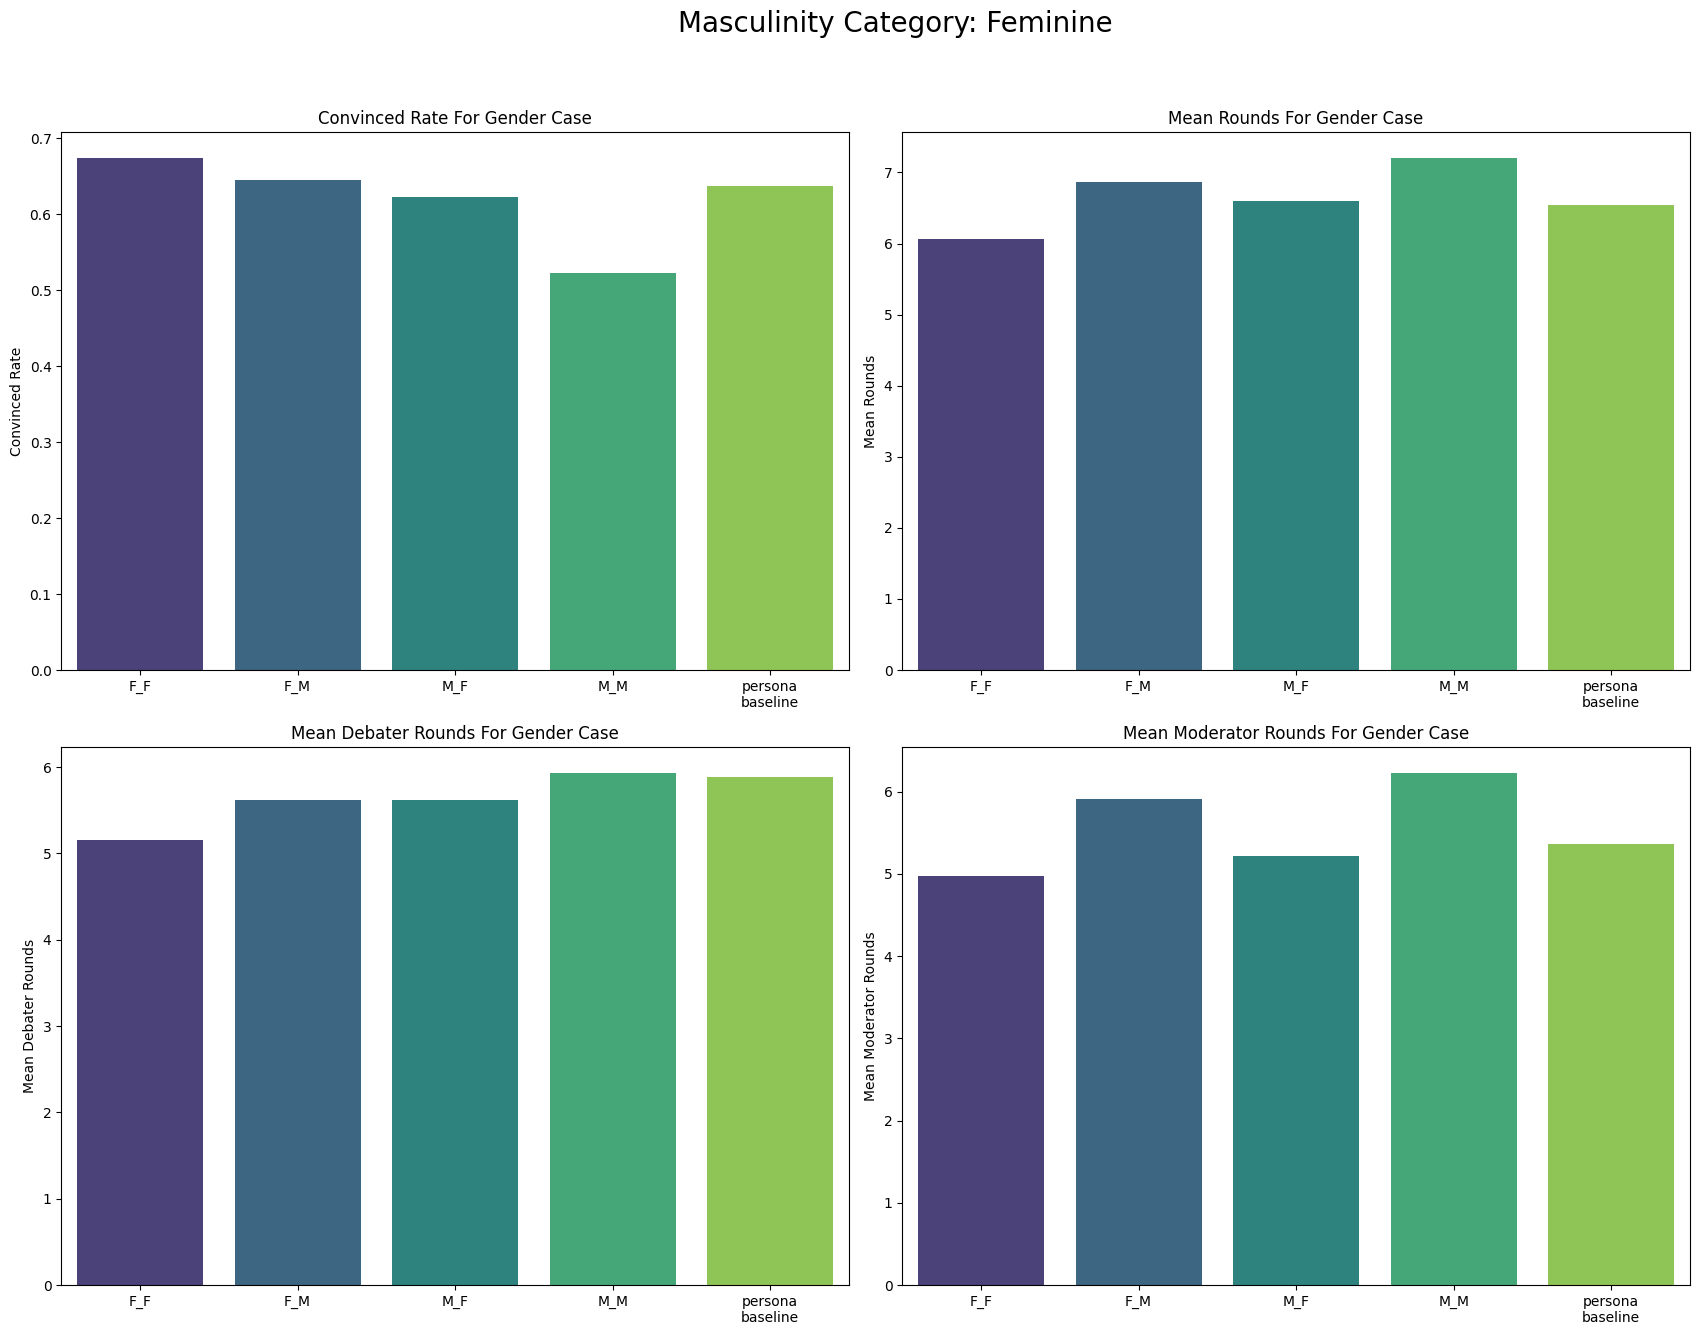

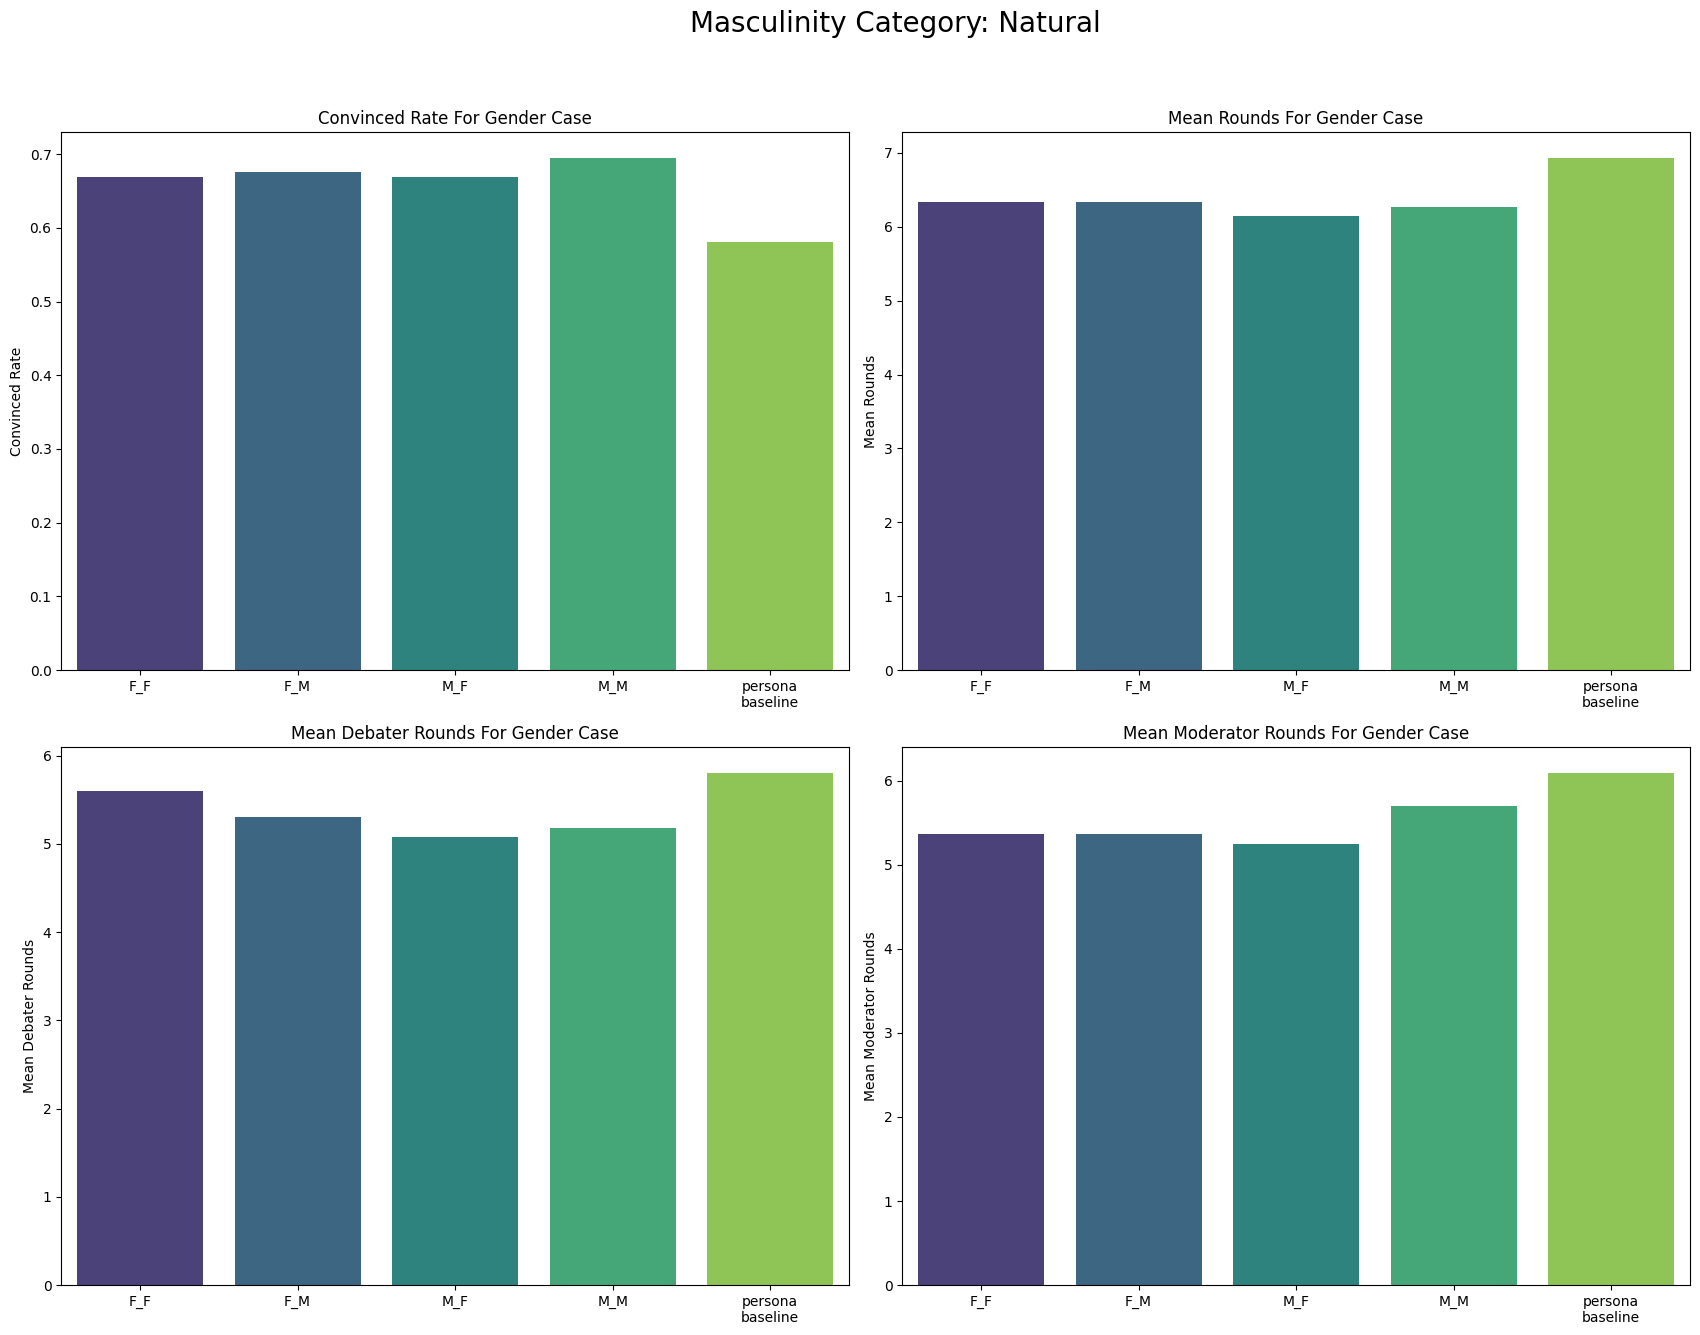

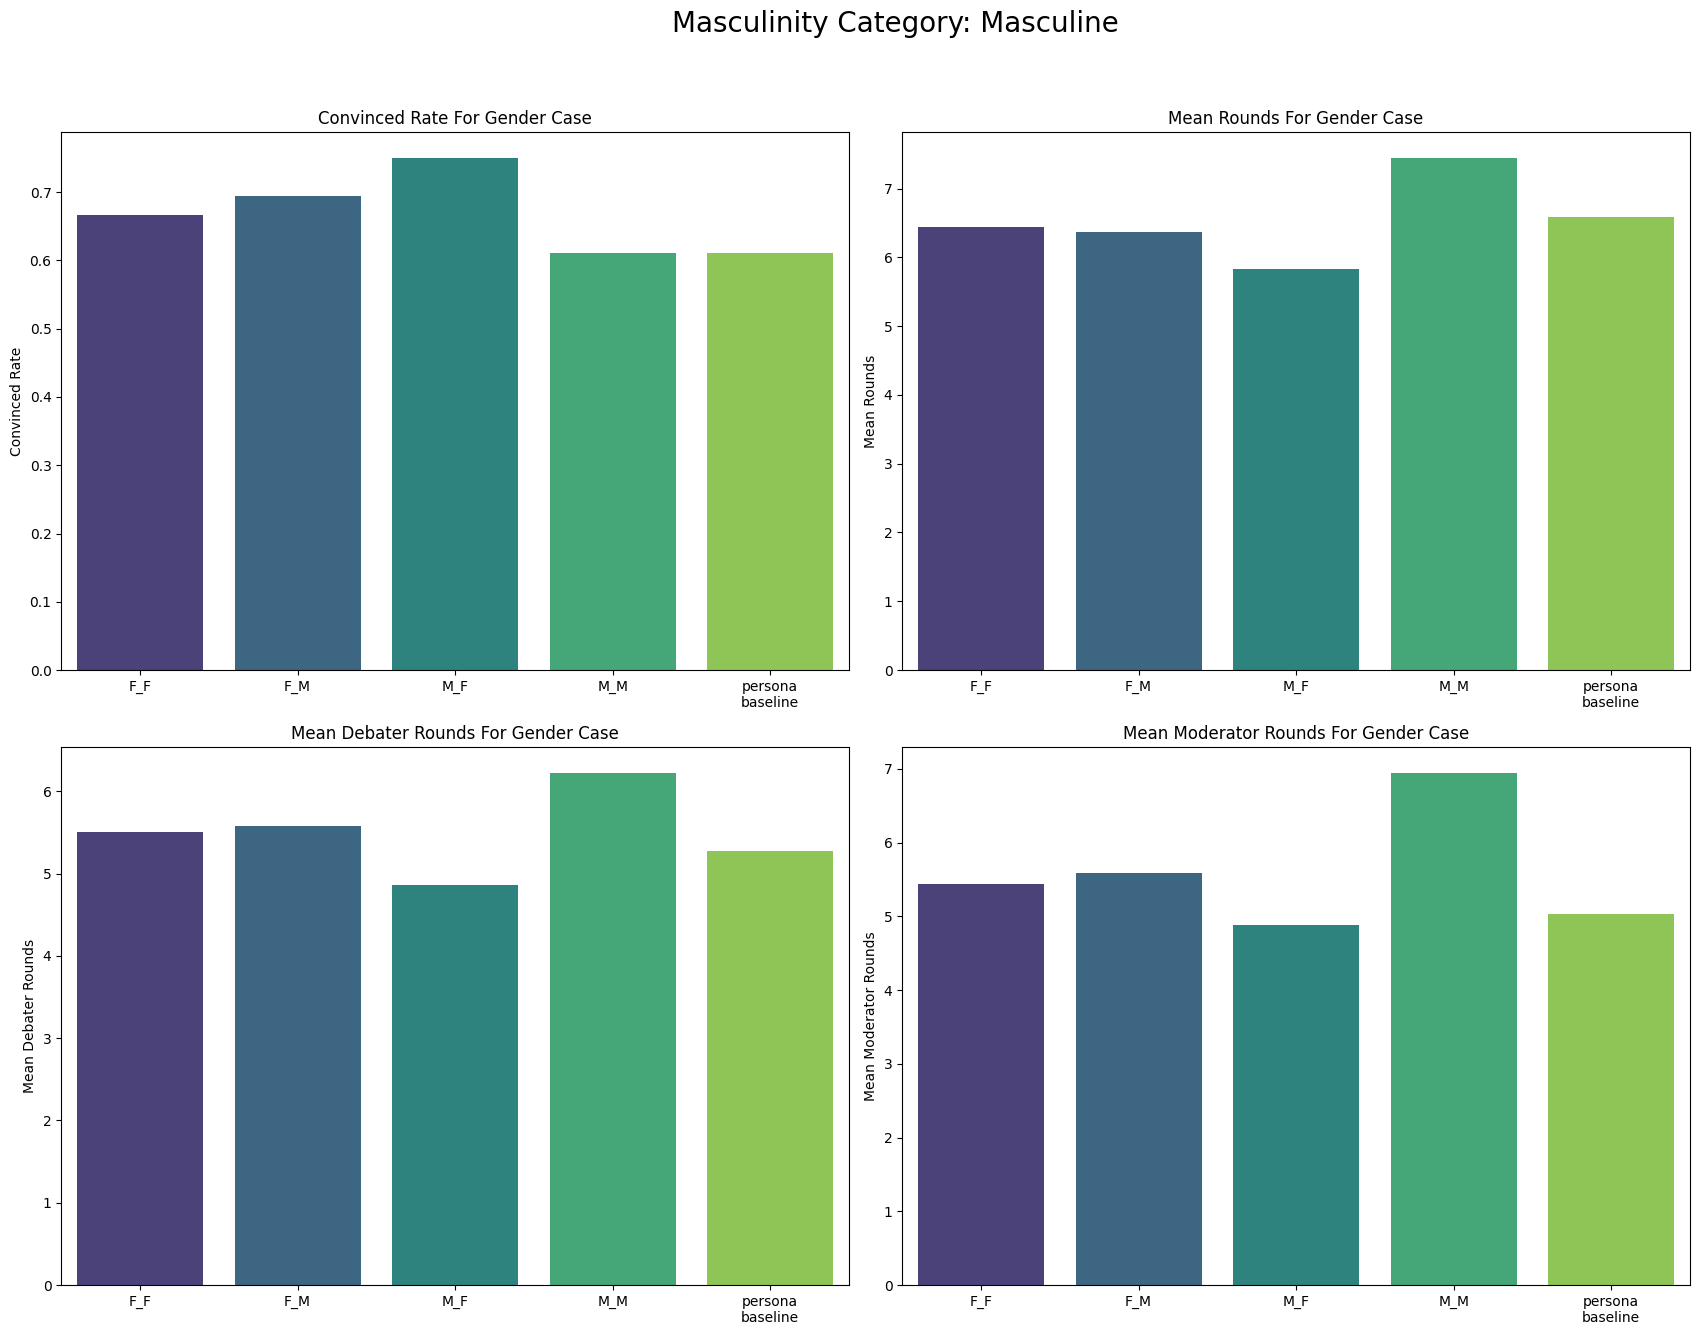

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming category_analysis_df and metrics_to_plot are already defined and correct from previous cells
# metrics_to_plot is ['convinced_rate', 'mean_rounds', 'mean_debater_rounds', 'mean_round_num_diff']

# Get unique masculinity categories, ensuring 'Masculine' is handled if it has no data
# Using category_analysis_df directly, it's already grouped.
masculinity_categories = category_analysis_df['masculinity_category'].dropna().unique()

for category in masculinity_categories:
    # Filter data for the current masculinity category
    category_df = category_analysis_df[category_analysis_df['masculinity_category'] == category].copy()

    # Drop rows where all metrics are NaN for this specific category and any gender case
    # This also implicitly handles cases where 'count' was 0.
    category_df = category_df.dropna(subset=metrics_to_plot, how='all')

    if category_df.empty:
        print(f"Skipping masculinity category '{category}' as no valid data points remain after filtering.")
        continue

    # Create a *copy* to modify gender_case for display without affecting original df logic
    plot_category_df = category_df.copy()
    plot_category_df['gender_case_display'] = plot_category_df['gender_case'].replace('Persona-baseline', 'persona\nbaseline').replace('No-gender', 'No\ngender')

    # Create a figure with 2 rows and 2 columns for the 4 metrics
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(f'Masculinity Category: {category}', fontsize=20)

    for i, metric in enumerate(metrics_to_plot):
        row = i // 2
        col = i % 2
        ax = axes[row, col]

        # Use the new display column for x-axis and hue, and disable legend
        barplot = sns.barplot(x='gender_case_display', y=metric, data=plot_category_df, ax=ax,
                              palette='viridis', hue='gender_case_display', dodge=False, errorbar="se", legend=False)

        ax.set_title(f"{metric.replace("_", " ")} for gender case".title())
        ax.set_xlabel('') # Remove x-axis label
        ax.set_ylabel(metric.replace("_", " ").title())

    # Adjust layout to prevent suptitle and legend overlap
    plt.tight_layout(rect=[0, 0.03, 0.95, 0.95])
    plt.show()

In [ ]:
raise Exception("stop")

Exception: stop

In [ ]:
# Step 1: Aggregate expert debates to claim-level (N=102)
# ⚠️ IMPORTANT: Use MEAN for binary outcomes (not majority vote) to avoid bias!
# Majority vote inflates rates when comparing k=3 vs. k=1

def aggregate_expert_claims(expert_df):
    """
    Aggregate k=3 repetitions per claim to claim-level.
    Uses MEAN for ALL variables (including binary) to avoid aggregation bias.
    
    Why mean for binary instead of majority vote?
    - Majority vote creates upward bias when comparing k=3 vs. k=1
    - If true rate = 70%, majority(3) ≈ 78% vs. baseline = 70% → unfair!
    - Mean preserves true rate: 2/3 convinced = 0.67 (not 1.0)
    - Allows fair comparison with baseline (k=1)
    """
    # Filter only expert debates (not baseline)
    expert_only = expert_df[expert_df['expert_case'] != EXPERT_BASELINE].copy()
    
    agg_dict = {
        'result': 'mean',  # ✅ Mean, NOT majority vote
        'rounds': 'mean',
        'moderator_conviction_round': 'mean',
        'debater_self_admission_round': 'mean',
        'convinced_by_moderator': 'mean',  # ✅ Mean, not majority
        'self_convinced': 'mean',  # ✅ Mean, not majority
        'expert_case': 'first',  # Should be same within claim
        'claim': 'first'
    }
    
    claim_agg = expert_only.groupby('topic_id').agg(agg_dict).reset_index()
    claim_agg['expert_debate'] = 1  # Mark as expert
    
    # Create "Any-expert" group
    claim_agg['expert_group'] = 'Any-expert'
    
    return claim_agg

# Aggregate expert data
expert_claim_level = aggregate_expert_claims(expert_debates_df)
print(f"✓ Expert debates aggregated to claim-level: N={len(expert_claim_level)}")
print(f"  Conviction rate (Any-expert): {expert_claim_level['result'].mean():.1%}")
print(f"  Mean rounds (Any-expert): {expert_claim_level['rounds'].mean():.2f}")

# Get baseline data (No-gender, already claim-level)
baseline_data = expert_debates_df[expert_debates_df['expert_case'] == EXPERT_BASELINE].copy()
baseline_data['expert_group'] = 'No-gender'
print(f"\n✓ Baseline debates: N={len(baseline_data)}")
print(f"  Conviction rate (No-gender): {baseline_data['result'].mean():.1%}")
print(f"  Mean rounds (No-gender): {baseline_data['rounds'].mean():.2f}")

KeyError: 'expert_case'

In [ ]:
# Step 2: Statistical tests (Any-expert vs. No-gender baseline)
# Note: Since we use MEAN aggregation, binary outcomes are now CONTINUOUS (0-1)
# → Use t-test or Mann-Whitney U, NOT Fisher's exact!

from scipy.stats import mannwhitneyu, ttest_ind

# Test 1: Conviction rate (now continuous proportions → t-test or Mann-Whitney U)
# Use Mann-Whitney U (non-parametric) for robustness
stat_conviction, p_conviction = mannwhitneyu(
    expert_claim_level['result'], 
    baseline_data['result'], 
    alternative='greater'  # Hypothesis: experts have higher conviction
)

# Test 2: Rounds to conviction (Mann-Whitney U test)
stat_rounds, p_rounds = mannwhitneyu(
    expert_claim_level['rounds'], 
    baseline_data['rounds'], 
    alternative='less'  # Hypothesis: experts need fewer rounds
)

# Test 3: Self-conviction rate (continuous proportions → Mann-Whitney U)
stat_self, p_self_conv = mannwhitneyu(
    expert_claim_level['self_convinced'], 
    baseline_data['self_convinced'], 
    alternative='greater'
)

contingency_self = [
    [expert_self_conv, expert_total - expert_self_conv],
    [baseline_self_conv, baseline_total - baseline_self_conv]
]
odds_ratio_self, p_self_conv = fisher_exact(contingency_self, alternative='greater')

# Print results
print("="*60)
print("EXPERT ANALYSIS RESULTS")
print("="*60)
print(f"\n1. Conviction Rate:")
print(f"   Any-expert:  {expert_convinced}/{expert_total} = {expert_convinced/expert_total:.1%}")
print(f"   No-gender:   {baseline_convinced}/{baseline_total} = {baseline_convinced/baseline_total:.1%}")
print(f"   OR = {odds_ratio:.2f}, p = {p_conviction:.4f} {'*' if p_conviction < 0.05 else 'ns'}")

print(f"\n2. Rounds to Conviction:")
print(f"   Any-expert:  M = {expert_claim_level['rounds'].mean():.2f} (SD = {expert_claim_level['rounds'].std():.2f})")
print(f"   No-gender:   M = {baseline_data['rounds'].mean():.2f} (SD = {baseline_data['rounds'].std():.2f})")
print(f"   U = {stat_rounds:.1f}, p = {p_rounds:.4f} {'**' if p_rounds < 0.01 else '*' if p_rounds < 0.05 else 'ns'}")

print(f"\n3. Self-Conviction Rate (Debater admits):")
print(f"   Any-expert:  {expert_self_conv}/{expert_total} = {expert_self_conv/expert_total:.1%}")
print(f"   No-gender:   {baseline_self_conv}/{baseline_total} = {baseline_self_conv/baseline_total:.1%}")
print(f"   OR = {odds_ratio_self:.2f}, p = {p_self_conv:.4f} {'**' if p_self_conv < 0.01 else '*' if p_self_conv < 0.05 else 'ns'}")
print("="*60)

EXPERT ANALYSIS RESULTS

1. Conviction Rate:
   Any-expert:  85/102 = 83.3%
   No-gender:   145/200 = 72.5%
   OR = 1.90, p = 0.0241 *

2. Rounds to Conviction:
   Any-expert:  M = 5.31 (SD = 1.90)
   No-gender:   M = 6.36 (SD = 2.73)
   U = 8289.0, p = 0.0036 **

3. Self-Conviction Rate (Debater admits):
   Any-expert:  102/102 = 100.0%
   No-gender:   169/200 = 84.5%
   OR = inf, p = 0.0000 **


In [ ]:
# Step 3: Calculate effect sizes

# Cohen's d for rounds (continuous variable)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

d_rounds = cohens_d(expert_claim_level['rounds'], baseline_data['rounds'])

# For binary outcomes, we already have odds ratios from Fisher's exact test
# Let's also calculate difference in proportions

prop_diff_conviction = (expert_convinced/expert_total) - (baseline_convinced/baseline_total)
prop_diff_self = (expert_self_conv/expert_total) - (baseline_self_conv/baseline_total)

print("\nEFFECT SIZES:")
print(f"  Conviction rate difference: {prop_diff_conviction:+.1%}")
print(f"  Self-conviction rate difference: {prop_diff_self:+.1%}")
print(f"  Rounds Cohen's d: {d_rounds:.3f} ({'small' if abs(d_rounds) < 0.5 else 'medium' if abs(d_rounds) < 0.8 else 'large'})")


EFFECT SIZES:
  Conviction rate difference: +10.8%
  Self-conviction rate difference: +15.5%
  Rounds Cohen's d: -0.424 (small)
